[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T04_C_contabilidad_ciclo_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Módulo 4 — Contabilidad del ciclo económico: las cuñas, una a la vez

**Curso complementario · puremacro**

El mazo A4 deriva la economía prototipo, nombra sus **cuatro** cuñas —eficiencia, trabajo, inversión y gasto— y describe un experimento: alimentar el prototipo con **una cuña a la vez**, dejando las otras tres en su valor de senda balanceada, y medir cuánto de la recesión reproduce cada una. Ese experimento ya está corrido en el curso, y conviene decir dónde: la lección **04b** (`04b_contabilidad_ciclo_es`, semanas 7–8) mide las cuatro cuñas en seis países, **log-lineariza** el prototipo, cierra las expectativas con un VAR(1) de las cuñas estimado por mínimos cuadrados y lo resuelve con `puremacro.dsge.klein_solve`. Este cuaderno corre el mismo experimento por el otro camino y sobre el panel entero: el prototipo **no lineal con previsión perfecta**, resuelto por Newton sobre las secuencias, en las 33 economías del archivo de investigación.

Las dos rutas son defendibles y no compran lo mismo. Cerrar las expectativas con un VAR(1) es lo que hacen Chari, Kehoe y McGrattan, así que en ese punto **04b está más cerca del artículo que este cuaderno**; el precio es la aproximación lineal, cuyo error no desaparece: con las cuatro cuñas juntas la réplica del dato es buena y no exacta. La previsión perfecta de aquí es una teoría más pobre de las expectativas —§4 dice por qué en este panel es defendible, cuánto cambiaría la cuña de inversión sin ella y qué se pierde— y a cambio devuelve el dato **al bit**, que es lo que convierte la corrida con las cuatro cuñas juntas en una prueba de unidad del solucionador. Encima de eso, este cuaderno añade cuatro cosas que 04b no trae: la cuña de trabajo medida por **activos** en vez de por ocupados, el filtro de Kehoe y Prescott sobre la década de 2010, el coste de productividad de un *default* soberano, y México.

Conviene decir pronto y sin adornos para qué sirve todo esto, porque es fácil leerlo al revés. **Una cuña no es una fricción.** El mapa fricción→cuña es de muchos a uno: un impuesto sobre el trabajo, un sindicato, un coste de emparejamiento, una reforma de la protección del empleo y un error de clasificación de las horas aparecen todos dentro de la misma cuña de trabajo, y ninguna de esas teorías se distingue de las otras mirándola. Una cuña que se mueve **nombra una familia** de modelos; no elige dentro de ella. Lo que la contabilidad del ciclo compra —lo único que compra— es el poder de **descartar** familias enteras: si la cuña que representa a las fricciones financieras no mueve el producto ni en Estados Unidos, ni en España, ni en Alemania, entonces esa familia no puede ser la historia principal de 2008–09 *en el sentido que el prototipo sabe leer*.

Y una advertencia que es la línea del mazo y también la de este cuaderno: por construcción las cuatro cuñas juntas reproducen los datos **exactamente**. Que el prototipo «ajuste» no es evidencia a favor de nada. Aquí lo comprobamos al bit —el solucionador arranca de la senda *sin* cuñas y vuelve al dato con un error máximo de $1\cdot10^{-13}$ sobre las seis corridas, $4\cdot10^{-15}$ en la mejor— precisamente para poder decir que el contenido está en el **reparto** y nunca en el ajuste. Esa exactitud es del solucionador **no lineal**: una versión log-linealizada del mismo experimento reproduce bien el dato y no puede reproducirlo al bit, porque el error de aproximación sigue ahí. Conviene citar a 04b en sus propios términos, que son más exigentes consigo misma que este párrafo: nombra **tres** culpables de su brecha —suaviza las cuñas cuatro trimestres, lineariza el modelo, y su $\tau_x$ no es la cuña filtrada de CKM—, y sólo el segundo es estructural.

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. **Medir las cuatro cuñas** del panel de 33 economías de la OCDE y verificar al bit qué es cada una: la de trabajo es $\log(C/Y)+3\log(H/E)$ y **no contiene el empleo**; la de eficiencia es un residuo de Solow crudo; la de inversión es crecimiento del consumo multiplicado por una ganancia de entre 9 y 56; la de gasto es un **nivel**, no una cuota, y en este panel es el saldo externo.
2. **Desarmar una recesión en cuñas** país por país, y saber cuál de las tres ordena el corte transversal y cuál no ordena nada — distinguiendo la parte de ese resultado que es un hallazgo de la parte que es una identidad contable.
3. **Derivar la identidad de la cuña de trabajo** y usarla para leer un corte transversal que engaña: por qué la cuña correlaciona con el empleo sin contenerlo, qué le pasa a España al cambiar el denominador de ocupados a activos, y cuánto de las horas perdidas «debe» la cuña en 2008–13 frente a 2020.
4. **Resolver el prototipo no lineal** con previsión perfecta por Newton —sin Dynare y sin linealizar, que es la otra ruta, la de 04b— y correr el experimento «una cuña a la vez» en tres países, con la prueba de unidad y las cinco robusteces que deciden si el reparto es del dato o del solucionador.
5. **Aplicar el filtro de Kehoe y Prescott** a la década de 2010 y separar lo que en él es dato de lo que es convención (la pendiente, el ancla y el denominador), y poner el coste de productividad de un *default* soberano al lado de la distribución de pérdidas de PTF sin *default*.
6. **Decir con precisión por qué México no está en el panel**, cuántas de las cuatro cuñas admite y con qué barra de error cada una, y qué tres cosas concretas costaría meterlo.

Todo corre en Python puro sobre `data_curso/`, sin red. Se apoya en T01_A §5 (los tres márgenes de la misma recesión), en T01_B (las cuentas y el ajuste de Gollin) y en T01_C (qué esconde la frecuencia trimestral); ninguna de las tres se repite aquí.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from puremacro.regress import ols, add_constant

_cwd = __import__("pathlib").Path.cwd()


def _here(p):
    # Un sistema de archivos en sandbox (iOS) lanza PermissionError desde
    # .exists() en vez de devolver False; tratamos ilegible como ausente.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

# El panel de cuñas y los cuatro bloques de cuentas nacionales que congela T01_B §6.
# Nada de aquí toca la red.
from _datos import DATOS, gasto, mercado_laboral, renta, volumen

cols = _nbstyle.palette(5)                  # del más destacado al más tenue
# Un aspecto por cuña en todas las figuras, nunca un tono.  Como línea: eficiencia S1
# (tinta continua), trabajo S2 (guiones), inversión S3 (raya-punto), gasto S4 (puntos).
# Como barra o área: _nbstyle.BARRA_COLORES[0], [1], [2] y [3], en el mismo orden.
HASTA = "2019-12-31"    # 2020 no es un ciclo económico; ver T01_A §1.1

# La calibración con la que se midió el panel; §1 la verifica columna a columna.
DELTA, NU, SIGMA = 0.015, 2.0, 1.0     # depreciación trimestral, 1/Frisch, aversión al riesgo
AGREGADOS_UE = ("EA20", "EU27", "EU27_2020")
BASE = slice("2006-01-01", "2006-12-31")   # la base de comparación de todas las figuras

# UN SOLO FECHADO EN TODO EL CUADERNO, el de T01_A §5 sobre el producto del panel:
# pico = máximo de log Y hasta 2008T4, valle = mínimo posterior, dentro de la ventana.
# La ventana llega a 2013T4 porque en la periferia el valle de verdad es el de 2012-13;
# acortarla a 2011T4 mueve seis fechas y §2 imprime cuáles.
VENTANA = ("2007-01-01", "2013-12-31", "2008-12-31")

## 1. Las cuatro cuñas medidas, y lo que cada una es en realidad

El prototipo de Chari, Kehoe y McGrattan tiene **cuatro** cuñas, y la de gasto —la que cierra la restricción de recursos— resulta ser la más callada de las cuatro: entre 2019 y el segundo trimestre de 2020 el país mediano la movió **2.3 puntos del producto** mientras el producto caía 9.7, y España la movió 2.7 mientras su cuña de trabajo se desplomaba 29 puntos y la de inversión saltaba 65 — las dos últimas con media móvil centrada de cuatro trimestres, la convención de la figura; sin suavizar, la de trabajo cae 79. Esa desproporción es el resultado de esta sección, y es la razón de que el experimento de §4 —alimentar al prototipo con una cuña a la vez— tenga algo que repartir.

La definición, porque el resto del cuaderno la usa tal cual: $g_t \equiv Y_t - C_t - I_t$, un **nivel** en las mismas unidades que $Y_t$, no una participación del PIB. La distinción de la lámina no es pedante: en 2020T2 Luxemburgo movió el *nivel* de su cuña de gasto 0.18 puntos y su *cuota* 2.41, y la diferencia entera es que el denominador cayó 6.6%. Entre países, la correlación de esa brecha con el tamaño de $g/Y$ en la base es $+0.82$. La cuota se mueve sola.

### Una nota sobre los datos, porque aquí deciden las cuatro respuestas

Las cuñas del panel no son las de la pizarra: son residuos de unas condiciones de equilibrio concretas, medidos con unos datos concretos, y cuatro decisiones fijan de antemano lo que cada una puede decir. Ninguna se afirma aquí; las tres celdas siguientes las **verifican al bit**.

1. La cuña de trabajo es *exactamente* $\log(C/Y) + 3\log(H/E) + \text{cte}$. **El empleo no entra.**
2. Siete países no tienen horas: el panel les impone $H = 480\cdot E$, así que su cuña de trabajo es literalmente $\log(C/Y)$ — y *sube* en las recesiones. Dos de los siete traen, en el mismo archivo, las horas que harían falta para repararla. La reparación estadounidense le cambia el signo con **cualquier** fechado; la británica, sólo con el suyo, y la celda lo corre también sobre la ventana fija de la lección 04b para que se vea.
3. La cuña de inversión es el crecimiento realizado del consumo multiplicado por $\kappa = 1/(1-\beta(1-\delta))$, entre 8.8 y 55.8 según el país; y no existe cuando el consumo cae lo suficiente: falta en 25 de 33 países en 2020T2.
4. $A$ es el residuo de Solow crudo —sin utilización ni calidad del trabajo— y la normalización de $\tau_{\text{stat}}$ y $\tau_{\text{dyn}}$ es una constante por país: sólo las **diferencias** están identificadas, nunca los niveles entre países.

Orientación, la de `figuras_curso.py`: $\text{cuña}A=\log A$, $\text{cuña}L=-\log S$, $\text{cuña}X=+\log D$, y las tres caen cuando frenan. La de gasto entra sumando en $y=c+x+g$, así que comparte la orientación por aritmética.

Y una convención de dibujo, declarada aquí porque de ella salen los números del primer párrafo: las tres cuñas de la figura van con **media móvil centrada de cuatro trimestres** (ma4), porque la Euler es ruido casi puro. La versión cruda está en §2.1 y es mucho mayor: la cuña de trabajo española de 2019T4 a 2020T2 cae 29 puntos con ma4 y **79 sin suavizar**. Con esa misma convención, la cuña de inversión española se hunde 22 puntos en 2008-09 y salta 65 en 2020: los dos extremos de la figura. La celda de la figura imprime las dos, y a partir de §2 se declara el suavizado en cada tabla.

In [3]:
CUNAS = pd.read_csv(DATOS / "wedges_panel_BGP_clean_nu2.csv")
CUNAS = CUNAS[~CUNAS["code"].isin(AGREGADOS_UE)].copy()
CUNAS["date"] = pd.to_datetime(CUNAS["qdate"], format="%d-%b-%Y")
CUNAS = CUNAS.sort_values(["code", "date"]).reset_index(drop=True)
CUNAS["cunaA"] = 100.0 * CUNAS["logA"]                # eficiencia,  log A
CUNAS["cunaL"] = -100.0 * CUNAS["logS"]               # trabajo,     log(1 − tau_l)
CUNAS["cunaX"] = 100.0 * CUNAS["logD"]                # inversión,  −log(1 + tau_x)
CUNAS["g"] = CUNAS["Y"] - CUNAS["C"] - CUNAS["I"]     # gasto: un NIVEL, no una cuota
CUNAS["nx"] = CUNAS["RX"] - CUNAS["RM"]
CODIGOS = sorted(CUNAS["code"].unique())
SIN_HORAS = sorted(CUNAS.loc[CUNAS["use_hours"] == 0, "code"].unique())


def _marco(g):
    """Un país: niveles, logaritmos y las tres cuñas, indexado por trimestre."""
    g = g.set_index("date")
    f = pd.DataFrame({"y": 100 * np.log(g["Y"]),        # Y = RGDP en el panel, al bit
                      "A": g["cunaA"], "L": g["cunaL"], "X": g["cunaX"],
                      "k": 100 * np.log(g["K"]), "h": 100 * np.log(g["H"]),
                      "e": 100 * np.log(g["EMP"]), "hpe": 100 * np.log(g["H"] / g["EMP"]),
                      "cy": 100 * np.log(g["C"] / g["Y"]),
                      "alpha": g["alpha_c"], "uh": g["use_hours"].astype(int),
                      "logS": g["logS"], "C": g["C"], "K": g["K"], "H": g["H"],
                      "E": g["EMP"], "Yn": g["Y"], "gn": g["g"], "HOUR": g["HOUR"]},
                     index=g.index)
    f["ky"] = f["k"] - f["y"]
    f["A13"] = f["y"] - f["k"] / 3 - 2 * f["h"] / 3    # el mismo residuo con alpha = 1/3
    return f


PAIS = {c: _marco(g) for c, g in CUNAS.groupby("code")}


def pico_valle(ly, lo=VENTANA[0], hi=VENTANA[1], pico_hasta=VENTANA[2]):
    """Fechado propio, el de T01_A §5: pico = máximo de log Y hasta `pico_hasta`,
    valle = mínimo posterior, todo dentro de la ventana [lo, hi]."""
    s = ly.loc[lo:hi].dropna()
    pk = s.loc[:pico_hasta].idxmax()
    return pk, s.loc[pk:].idxmin()


def dif(code, col, a, b):
    """Diferencia de una columna entre dos trimestres, en puntos logarítmicos."""
    return float(PAIS[code][col].loc[b] - PAIS[code][col].loc[a])


REC = {c: pico_valle(PAIS[c]["y"]) for c in CODIGOS}
DY = pd.Series({c: dif(c, "y", *REC[c]) for c in CODIGOS})

_q = CUNAS["date"].dt.to_period("Q")
print(f"Panel: {len(CODIGOS)} economías, {CUNAS['date'].nunique()} trimestres, "
      f"{_q.min()}–{_q.max()}.\n"
      f"Y = C + I + g cierra por construcción (residuo máximo "
      f"{np.abs(CUNAS.Y - CUNAS.C - CUNAS.I - CUNAS.g).max():.0e}) y g no depende de cómo se\n"
      f"repartan los duraderos, porque C + I = RCON + RGCF "
      f"(máximo {np.abs(CUNAS.C + CUNAS.I - CUNAS.RCON - CUNAS.RGCF).max():.0e}).")

# ¿Qué hay dentro de g? Dos identidades candidatas de la restricción de recursos.
r_sin = 100 * (CUNAS.Y - CUNAS.RCON - CUNAS.RGCF - CUNAS.nx) / CUNAS.Y
r_con = 100 * (CUNAS.Y - CUNAS.RCON - CUNAS.RGOV - CUNAS.RGCF - CUNAS.nx) / CUNAS.Y
gy, resto = 100 * CUNAS.g / CUNAS.Y, 100 * (CUNAS.g - CUNAS.nx) / CUNAS.Y
print(f"\nY − RCON − RGCF − XN        -> mediana {r_sin.median():+.3f}% del PIB"
      f"\nY − RCON − RGOV − RGCF − XN -> mediana {r_con.median():+.2f}% del PIB\n"
      "RCON es el consumo final TOTAL, hogares MÁS gobierno: el consumo público está\n"
      "dentro de C y no dentro de g. La cuña de gasto de este panel es exportaciones\n"
      "netas más el residuo del encadenamiento, y nada más. Mediana de g/Y entre\n"
      f"países {gy.groupby(CUNAS.code).mean().median():+.1f}% "
      f"(GRC {gy[CUNAS.code == 'GRC'].mean():+.1f}, LUX {gy[CUNAS.code == 'LUX'].mean():+.1f}); "
      f"mediana de |resto/Y| {resto.groupby(CUNAS.code).mean().abs().median():.2f}%.")


def episodio_g(base, t0, t1):
    """Δ del NIVEL de g (puntos del producto de la base) frente a Δ de su cuota."""
    f = []
    for c in CODIGOS:
        x = PAIS[c]
        yb, gb = x.Yn.loc[base].mean(), x.gn.loc[base].mean()
        yt, gt = x.Yn.loc[t0:t1].mean(), x.gn.loc[t0:t1].mean()
        f.append({"code": c, "nivel": 100 * (gt - gb) / yb, "gY": 100 * gb / yb,
                  "cuota": 100 * (gt / yt - gb / yb), "d_y": 100 * np.log(yt / yb)})
    return pd.DataFrame(f).set_index("code")


gr_g = episodio_g("2006", "2008-10-01", "2009-06-30")
cv_g = episodio_g("2019", "2020-04-01", "2020-06-30")
print(f"\nTamaño de la cuña de gasto, en puntos del producto de la base:"
      f"\n  2008T4–2009T2 vs 2006: mediana |Δg| {gr_g.nivel.abs().median():.2f}, "
      f"EUA {gr_g.loc['USA', 'nivel']:+.1f}, ESP {gr_g.loc['ESP', 'nivel']:+.1f}, "
      f"mayor LVA {gr_g.loc['LVA', 'nivel']:+.1f}"
      f"\n  2020T2 vs 2019:        mediana |Δg| {cv_g.nivel.abs().median():.2f}, "
      f"EUA {cv_g.loc['USA', 'nivel']:+.1f}, ESP {cv_g.loc['ESP', 'nivel']:+.1f}, "
      f"mayor IRL {cv_g.loc['IRL', 'nivel']:+.1f}; Δlog Y mediano {cv_g.d_y.median():.1f}"
      f"\n  Nivel contra cuota en 2020T2: LUX {cv_g.loc['LUX', 'nivel']:+.2f} y "
      f"{cv_g.loc['LUX', 'cuota']:+.2f} con Δlog Y {cv_g.loc['LUX', 'd_y']:.1f}; GRC "
      f"{cv_g.loc['GRC', 'nivel']:+.1f} y {cv_g.loc['GRC', 'cuota']:+.1f}; "
      f"corr(g/Y en la base, cuota − nivel) = "
      f"{np.corrcoef(cv_g.gY, cv_g.cuota - cv_g.nivel)[0, 1]:+.2f}")

assert len(CODIGOS) == 33 and CUNAS["date"].nunique() == 102
assert np.abs(CUNAS.Y - CUNAS.C - CUNAS.I - CUNAS.g).max() < 1e-6
assert abs(r_sin.median()) < 0.05 and r_con.median() < -15.0   # el gobierno está en C
assert abs(cv_g.nivel.abs().median() - 2.26) < 0.05
assert abs(cv_g.loc["LUX", "nivel"] - 0.18) < 0.05 and cv_g.loc["LUX", "cuota"] > 2.0
assert abs(np.corrcoef(cv_g.gY, cv_g.cuota - cv_g.nivel)[0, 1] - 0.82) < 0.02

Panel: 33 economías, 102 trimestres, 2000Q1–2025Q2.
Y = C + I + g cierra por construcción (residuo máximo 0e+00) y g no depende de cómo se
repartan los duraderos, porque C + I = RCON + RGCF (máximo 1e-08).

Y − RCON − RGCF − XN        -> mediana +0.014% del PIB
Y − RCON − RGOV − RGCF − XN -> mediana -19.96% del PIB
RCON es el consumo final TOTAL, hogares MÁS gobierno: el consumo público está
dentro de C y no dentro de g. La cuña de gasto de este panel es exportaciones
netas más el residuo del encadenamiento, y nada más. Mediana de g/Y entre
países +2.0% (GRC -6.4, LUX +33.4); mediana de |resto/Y| 0.21%.

Tamaño de la cuña de gasto, en puntos del producto de la base:
  2008T4–2009T2 vs 2006: mediana |Δg| 1.20, EUA +2.0, ESP +2.8, mayor LVA +9.8
  2020T2 vs 2019:        mediana |Δg| 2.26, EUA +0.3, ESP -2.7, mayor IRL +38.4; Δlog Y mediano -9.7
  Nivel contra cuota en 2020T2: LUX +0.18 y +2.41 con Δlog Y -6.6; GRC -6.2 y -7.5; corr(g/Y en la base, cuota − nivel) = +0.82


In [4]:
ident = CUNAS.cunaL - 100.0 * (np.log(CUNAS.C / CUNAS.Y) + 3.0 * np.log(CUNAS.H / CUNAS.EMP))
rango = ident.groupby(CUNAS.code).agg(lambda s: s.max() - s.min())
sh = CUNAS.use_hours == 0
hpe = CUNAS.loc[sh, "H"] / CUNAS.loc[sh, "EMP"]
priv = CUNAS.use_privH == 1
e_priv = np.nanmax(np.abs(CUNAS.loc[priv, "H"] - (CUNAS.loc[priv, "HOUR"]
                                                  - CUNAS.loc[priv, "HOURG"]))
                   / CUNAS.loc[priv, "H"])
print(f"Nota 1.  log(1−tau_l) = log(C/Y) + 3 log(H/E) + cte, país por país: rango del\n"
      f"  residuo dentro de cada país, máximo sobre los 33: {rango.max():.0e}. El empleo se\n"
      f"  cancela entre el consumo por ocupado y el producto por ocupado; la derivada de\n"
      f"  la cuña de trabajo respecto de log E es exactamente cero."
      f"\n\nNota 2.  Los {int(sh.groupby(CUNAS.code).max().sum())} países sin horas "
      f"({', '.join(SIN_HORAS)}) llevan impuesto\n"
      f"  H = 480 x EMP: H/EMP entre {hpe.min():.9f} y {hpe.max():.9f}, así que su cuña de\n"
      f"  trabajo es log(C/Y). Los otros 26 usan horas PRIVADAS, H = HOUR − HOURG "
      f"(error {e_priv:.0e}).")

rep = []
for c in CODIGOS:
    pk, tr = REC[c]
    a, b = CUNAS[CUNAS.code == c].set_index("date").loc[pk], \
        CUNAS[CUNAS.code == c].set_index("date").loc[tr]
    d = {"code": c, "sin_horas": int(a.use_hours == 0), "pico": str(pk.to_period("Q")),
         "valle": str(tr.to_period("Q")), "d_y": dif(c, "y", pk, tr),
         "d_A": dif(c, "A", pk, tr), "d_L": dif(c, "L", pk, tr),
         "d_E": dif(c, "e", pk, tr), "d_hpe": dif(c, "hpe", pk, tr)}
    for etq, r in (("tot", b.HOUR / a.HOUR),
                   ("priv", (b.HOUR - b.HOURG) / (a.HOUR - a.HOURG))):
        dh = 100 * np.log(r * a.EMP / b.EMP) - d["d_hpe"]   # las horas por ocupado que faltan
        d[f"d_A_{etq}"] = d["d_A"] - (1 - a.alpha_c) * dh
        d[f"d_L_{etq}"] = d["d_L"] + 3 * dh
    rep.append(d)
rep = pd.DataFrame(rep).set_index("code")
nh, ch = rep[rep.sin_horas == 1], rep[rep.sin_horas == 0]
print(f"\n  De pico a valle propios, sin suavizar: la cuña de trabajo SUBIÓ en "
      f"{(nh.d_L > 0).sum()} de {len(nh)} países sin\n  horas (mediana {nh.d_L.median():+.1f}) "
      f"y CAYÓ en {(ch.d_L < 0).sum()} de {len(ch)} con horas (mediana {ch.d_L.median():+.1f}). "
      f"EUA {rep.loc['USA', 'pico']}→{rep.loc['USA', 'valle']}:\n"
      f"  el empleo cayó {rep.loc['USA', 'd_E']:.1f} y la cuña de trabajo SUBIÓ "
      f"{rep.loc['USA', 'd_L']:+.1f}. Eso es la nota 1 en un país.\n"
      f"\n  La reparación, con la columna HOUR que trae el mismo archivo (EUA "
      f"{PAIS['USA']['HOUR'].notna().mean():.0%}, GBR {PAIS['GBR']['HOUR'].notna().mean():.0%}):"
      f"\n    país     logA -> horas totales / privadas     cuña L -> totales / privadas")
for c in ("USA", "GBR"):
    r = rep.loc[c]
    print(f"    {c}    {r.d_A:6.2f} -> {r.d_A_tot:6.2f} / {r.d_A_priv:6.2f}"
          f"                {r.d_L:+6.2f} -> {r.d_L_tot:+6.2f} / {r.d_L_priv:+6.2f}")
_sinh = [c for c in SIN_HORAS if c not in ("USA", "GBR")]
_nada = [c for c in _sinh if PAIS[c]["HOUR"].notna().sum() == 0]
_tarde = [(c, str(PAIS[c]["HOUR"].dropna().index.min().to_period("Q"))) for c in _sinh
          if c not in _nada]
print(f"  Las dos versiones cambian el SIGNO de la cuña de trabajo. Los otros "
      f"{len(_sinh)} no se pueden\n  reparar con este archivo: "
      f"{', '.join(_nada)} no traen HOUR en ningún trimestre, y el de "
      + ", ".join(f"{c} empieza en {t}" for c, t in _tarde) + ".")

# El mismo arreglo sobre una ventana FIJA y común —2007T4→2009T2, que es el fechado de
# la lección 04b— en vez del pico y el valle propios de cada país. La pregunta no es
# retórica: el «3» de la identidad multiplica la jornada, y la jornada cae distinto en
# cada ventana, así que el vuelco de signo puede ser del arreglo o del fechado.
FIJO = (pd.Timestamp("2007-10-01"), pd.Timestamp("2009-04-01"))
fij = []
for c in ("USA", "GBR"):
    g = CUNAS[CUNAS.code == c].set_index("date")
    a, b = g.loc[FIJO[0]], g.loc[FIJO[1]]
    d = {"code": c, "d_L": float(b.cunaL - a.cunaL),
         "d_hpe": 100 * np.log((b.H / b.EMP) / (a.H / a.EMP))}
    for etq, r in (("tot", b.HOUR / a.HOUR),
                   ("priv", (b.HOUR - b.HOURG) / (a.HOUR - a.HOURG))):
        dh = 100 * np.log(r * a.EMP / b.EMP) - d["d_hpe"]
        d[f"d_L_{etq}"] = d["d_L"] + 3 * dh
        d[f"dj_{etq}"] = dh
    fij.append(d)
fij = pd.DataFrame(fij).set_index("code")
print(f"\n  Con la ventana FIJA de 04b ({FIJO[0].to_period('Q')}→{FIJO[1].to_period('Q')}) "
      f"en vez del pico y valle propios:\n"
      f"    país     cuña L -> totales / privadas     jornada que falta (tot / priv)")
for c in ("USA", "GBR"):
    r = fij.loc[c]
    print(f"    {c}    {r.d_L:+6.2f} -> {r.d_L_tot:+6.2f} / {r.d_L_priv:+6.2f}"
          f"            {r.dj_tot:+5.2f} / {r.dj_priv:+5.2f}")
_vuelca = {c: [t for t in ("tot", "priv") if fij.loc[c, f"d_L_{t}"] < 0] for c in ("USA", "GBR")}
print(f"  EUA vuelca el signo con las dos ventanas y las dos variantes. El Reino Unido "
      f"vuelca con\n  la suya y, con la de 04b, sólo con las horas "
      f"{'privadas' if _vuelca['GBR'] == ['priv'] else '/'.join(_vuelca['GBR']) or 'ninguna'}: "
      f"la jornada que le falta pasa de\n  {rep.loc['GBR', 'd_L_tot'] - rep.loc['GBR', 'd_L']:+.2f} "
      f"puntos con su propio fechado a {3 * fij.loc['GBR', 'dj_tot']:+.2f} con el de 04b, y eso ya no "
      f"cancela los\n  {fij.loc['GBR', 'd_L']:+.2f} de partida. El vuelco británico es una conclusión "
      f"sobre el fechado tanto como\n  sobre la columna; el estadounidense no.")

assert rango.max() < 1e-10
assert abs(hpe.min() - 480) < 1e-9 and abs(hpe.max() - 480) < 1e-9
assert int((nh.d_L > 0).sum()) == 7
assert abs(rep.loc["USA", "d_A"] + 2.40) < 0.02 and abs(rep.loc["USA", "d_A_tot"] + 0.97) < 0.02
assert rep.loc["USA", "d_L"] > 0 > rep.loc["USA", "d_L_tot"] and rep.loc["USA", "d_L_priv"] < 0
assert fij.loc["USA", "d_L"] > 0 > fij.loc["USA", "d_L_tot"] and fij.loc["USA", "d_L_priv"] < 0
assert fij.loc["GBR", "d_L_tot"] > 0 > fij.loc["GBR", "d_L_priv"], "el vuelco británico depende de la ventana"
assert abs(fij.loc["GBR", "d_L_tot"] - 0.79) < 0.05 and abs(fij.loc["USA", "d_L_tot"] + 4.48) < 0.05

Nota 1.  log(1−tau_l) = log(C/Y) + 3 log(H/E) + cte, país por país: rango del
  residuo dentro de cada país, máximo sobre los 33: 3e-12. El empleo se
  cancela entre el consumo por ocupado y el producto por ocupado; la derivada de
  la cuña de trabajo respecto de log E es exactamente cero.

Nota 2.  Los 7 países sin horas (AUS, CHE, GBR, JPN, KOR, NZL, USA) llevan impuesto
  H = 480 x EMP: H/EMP entre 480.000000000 y 480.000000000, así que su cuña de
  trabajo es log(C/Y). Los otros 26 usan horas PRIVADAS, H = HOUR − HOURG (error 3e-16).

  De pico a valle propios, sin suavizar: la cuña de trabajo SUBIÓ en 7 de 7 países sin
  horas (mediana +2.9) y CAYÓ en 17 de 26 con horas (mediana -2.6). EUA 2008Q2→2009Q2:
  el empleo cayó -4.1 y la cuña de trabajo SUBIÓ +3.0. Eso es la nota 1 en un país.

  La reparación, con la columna HOUR que trae el mismo archivo (EUA 97%, GBR 99%):
    país     logA -> horas totales / privadas     cuña L -> totales / privadas
    USA     -2.40 ->  -0.97 /  -0.

In [5]:
Ahat = CUNAS.Y / (CUNAS.K ** CUNAS.alpha_c * CUNAS.H ** (1 - CUNAS.alpha_c))
num = (1.0 / CUNAS.beta_c) * (CUNAS.C / CUNAS.groupby("code").C.shift(1)) - (1.0 - DELTA)
crudo = 100.0 * (np.log(num.where(num > 0)) - np.log(CUNAS.alpha_c * CUNAS.Y / CUNAS.K))
rg_D = (CUNAS.cunaX - crudo).groupby(CUNAS.code).agg(lambda s: s.max() - s.min())
dif_D = (CUNAS.set_index(["code", "date"]).cunaX.unstack(0).diff()
         - CUNAS.assign(z=crudo).set_index(["code", "date"]).z.unstack(0).diff())
print(f"Nota 4.  A = Y / (K^alpha_c · H^(1−alpha_c)) reproduce logA con error máximo "
      f"{np.abs(CUNAS.logA - np.log(Ahat)).max():.0e}:\n"
      f"  un residuo de Solow crudo, sin utilización del capital y sin calidad del trabajo,\n"
      f"  así que «cuña de eficiencia» incluye las dos cosas y el atesoramiento de trabajo.\n"
      f"\n  Y la normalización a media 1 en 2000–2006 es una CONSTANTE por país: el rango\n"
      f"  dentro de cada país de cuñaX menos la Euler cruda es {rg_D.max():.0e}, y el de cuñaL\n"
      f"  menos log(C/Y)+3log(H/E) es {rango.max():.0e}. Luego toda diferencia temporal es\n"
      f"  idéntica con y sin normalizar: máximo {np.nanmax(np.abs(dif_D)):.0e}. Corolario\n"
      f"  operativo: los NIVELES no son comparables entre países, sólo las diferencias.")

beta = CUNAS.groupby("code").beta_c.first()
kappa = 1.0 / (1 - beta * (1 - DELTA))
umbral = 100.0 * np.log((1 / beta) / (1 - DELTA))
n_nan = int(CUNAS.loc[CUNAS.date == pd.Timestamp("2020-04-01"), "logD"].isna().sum())
print(f"\nNota 3.  La cuña de inversión es crecimiento del consumo por kappa = "
      f"1/(1−beta(1−delta)):\n  kappa de {kappa.min():.1f} ({kappa.idxmin()}) a "
      f"{kappa.max():.1f} ({kappa.idxmax()}), mediana {kappa.median():.1f} — un punto de\n"
      f"  crecimiento trimestral del consumo la mueve entre 9 y 56 puntos logarítmicos. Y si\n"
      f"  el consumo cae más de {umbral.min():.1f}% ({umbral.idxmin()}) a "
      f"{umbral.max():.1f}% ({umbral.idxmax()}) en un trimestre, el numerador es\n"
      f"  negativo y la cuña no existe: falta en {n_nan} de {len(CODIGOS)} países en 2020T2.")

assert np.abs(CUNAS.logA - np.log(Ahat)).max() < 1e-12
assert rg_D.max() < 1e-10 and np.nanmax(np.abs(dif_D)) < 1e-9
assert n_nan == 25 and abs(kappa.min() - 8.8) < 0.1 and abs(kappa.max() - 55.8) < 0.1

Nota 4.  A = Y / (K^alpha_c · H^(1−alpha_c)) reproduce logA con error máximo 9e-15:
  un residuo de Solow crudo, sin utilización del capital y sin calidad del trabajo,
  así que «cuña de eficiencia» incluye las dos cosas y el atesoramiento de trabajo.

  Y la normalización a media 1 en 2000–2006 es una CONSTANTE por país: el rango
  dentro de cada país de cuñaX menos la Euler cruda es 2e-11, y el de cuñaL
  menos log(C/Y)+3log(H/E) es 3e-12. Luego toda diferencia temporal es
  idéntica con y sin normalizar: máximo 2e-11. Corolario
  operativo: los NIVELES no son comparables entre países, sólo las diferencias.

Nota 3.  La cuña de inversión es crecimiento del consumo por kappa = 1/(1−beta(1−delta)):
  kappa de 8.8 (LTU) a 55.8 (PRT), mediana 20.7 — un punto de
  crecimiento trimestral del consumo la mueve entre 9 y 56 puntos logarítmicos. Y si
  el consumo cae más de 1.8% (PRT) a 12.0% (LTU) en un trimestre, el numerador es
  negativo y la cuña no existe: falta en 25 de 33 países en 202

  [info] USA Gran Recesión: A [-1.7, +2.8], L [-0.1, +3.1], X [-14.1, +2.4], G [-0.1, +2.4]
  [info] USA COVID-19: A [-1.0, +3.8], L [-0.0, +1.5], X [-10.5, +42.8], G [-1.9, +0.3]


  [info] ESP Gran Recesión: A [-4.0, +0.0], L [-8.5, +0.7], X [-22.0, +1.1], G [-0.8, +6.1]


  [info] ESP COVID-19: A [-5.6, +0.3], L [-28.6, +2.3], X [-25.4, +65.1], G [-2.5, +0.4]
  [info] ESP COVID-19 SIN suavizar, 2019T4→2020T2: A -7.9, L -79.0  — la figura va con media móvil de cuatro trimestres; §2.1 da la tabla cruda


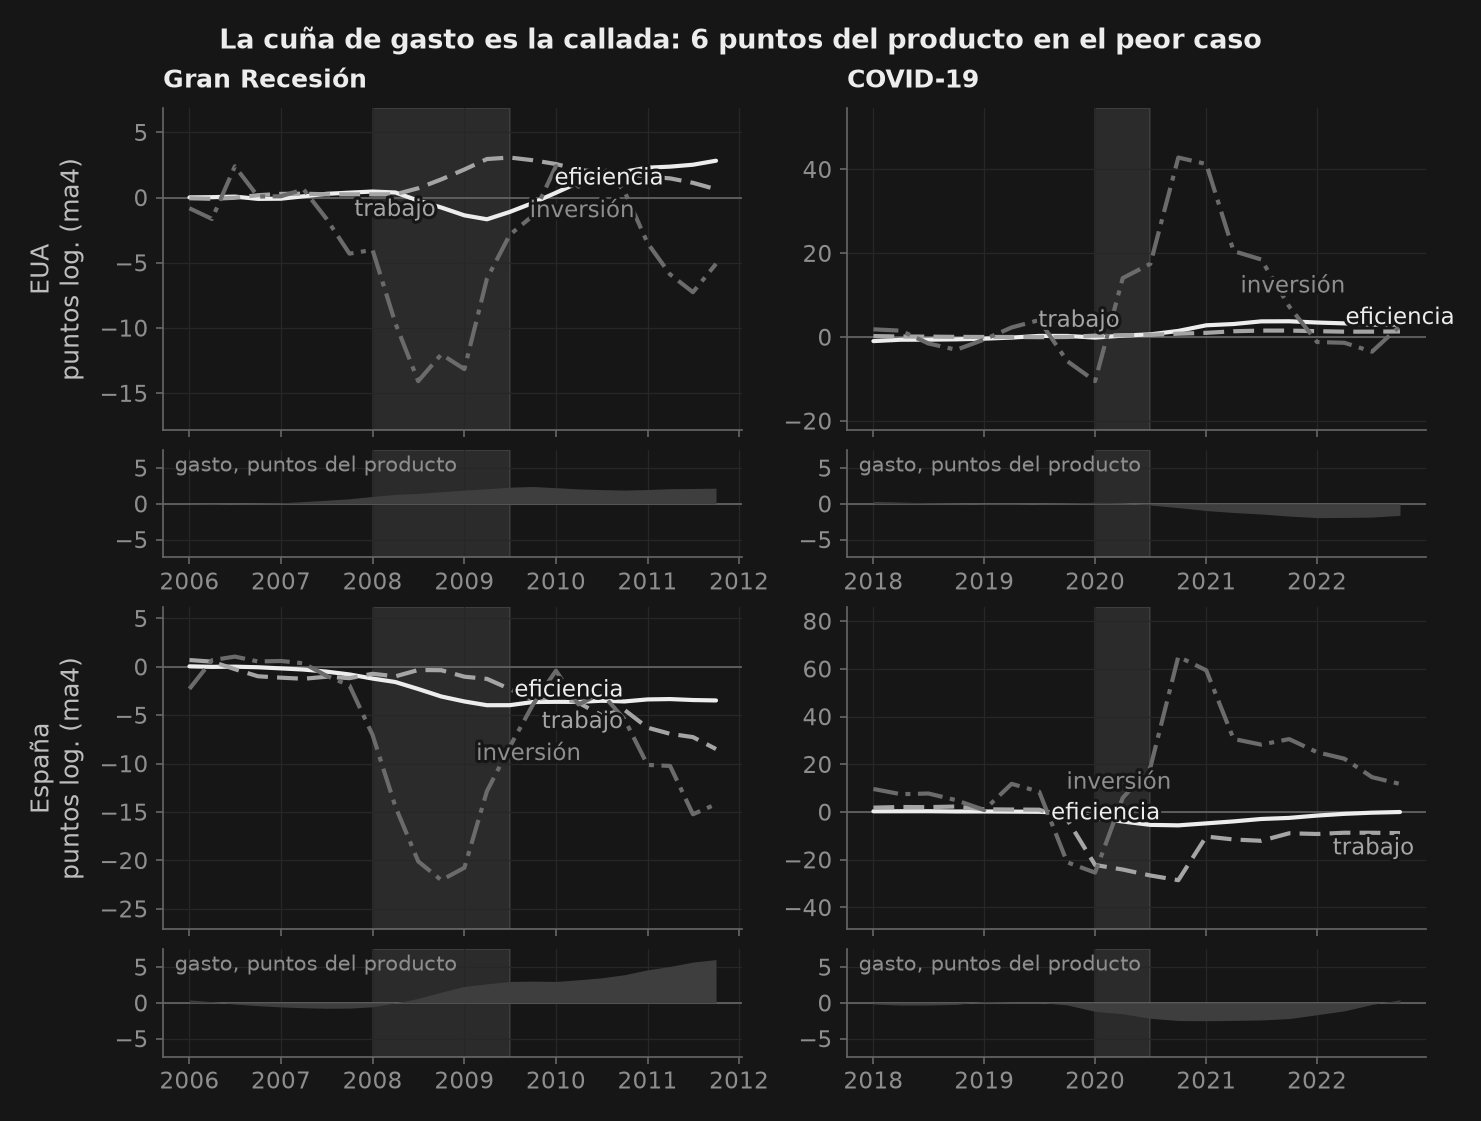

In [6]:
PAISES_FIG = (("USA", "EUA"), ("ESP", "España"))
EPISODIOS = (("Gran Recesión", "2006", "2011", "2006", "2008-01-01", "2009-06-30"),
             ("COVID-19", "2018", "2022", "2019", "2020-01-01", "2020-06-30"))
SERIES = (("A", "eficiencia", _nbstyle.S1),
          ("L", "trabajo", _nbstyle.S2),
          ("X", "inversión", _nbstyle.S3))

# Cuatro bloques (país x episodio) y debajo de cada uno la tira del gasto: cuatro filas
# a la altura de una figura 2x2, con la tira a un tercio del panel que lee.  El episodio
# titula la columna y el país rotula la fila, sin repetir ninguno de los dos en los cuatro
# títulos.  En la lámina la ranura mide la mitad de alto que el cuaderno, así que la figura
# se dibuja ya a ese tamaño —nunca se encoge después, que es lo que descoloca las
# etiquetas— y ahí el rótulo del eje, los años y las marcas de la tira van en versión corta.
LAM = _nbstyle.PERFIL == "lamina"
fig, AX = _nbstyle.figura(4, 2, figsize=plt.rcParams["figure.figsize"] if LAM else "2x2",
                          height_ratios=[3.0, 1.35, 3.0, 1.35] if LAM else [3.0, 1.0, 3.0, 1.0],
                          sharex="col")
for i, (code, nombre) in enumerate(PAISES_FIG):
    x = PAIS[code]
    for j, (titulo, ini, fin, base, s0, s1) in enumerate(EPISODIOS):
        ax, axg = AX[2 * i, j], AX[2 * i + 1, j]
        w = x[["A", "L", "X"]].copy()
        w["G"] = 100.0 * (x.gn - x.gn.loc[base].mean()) / x.Yn.loc[base].mean()
        s = w.rolling(4, center=True, min_periods=2).mean()   # la Euler es ruido casi puro
        s = s.loc[ini:fin] - s.loc[base].mean()
        for a in (ax, axg):
            a.axvspan(pd.Timestamp(s0), pd.Timestamp(s1), color=_nbstyle.RECESION, zorder=0)
            a.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, zorder=2)
        for col, etq, sty in SERIES:
            ax.plot(s.index, s[col], **sty, zorder=3, label=etq)
        axg.fill_between(s.index, 0.0, s.G, color=_nbstyle.BARRA_COLORES[3], lw=0, zorder=3)
        axg.set_ylim(-7.5, 7.5); axg.set_yticks([-5, 5] if LAM else [-5, 0, 5])
        axg.xaxis.set_major_locator(mdates.YearLocator(2 if LAM else 1))
        if i == 0:
            ax.set_title(titulo)
        axg.tick_params(axis="x", labelbottom=True)
        axg.annotate("gasto, puntos del producto", (0.02, 0.95), xycoords="axes fraction",
                     va="top", fontsize="small", color=_nbstyle.NOTA)
        if j == 0:
            ax.set_ylabel(f"{nombre}\npuntos log." + ("" if LAM else " (ma4)"))
        ax.margins(y=0.22)                    # aire arriba y abajo para las etiquetas
        _nbstyle.etiquetar(ax, sep=1.4)
        print(f"  [info] {code} {titulo}: " + ", ".join(
            f"{c} [{s[c].min():+.1f}, {s[c].max():+.1f}]" for c in ("A", "L", "X", "G")))
_cr = PAIS["ESP"]
print("  [info] ESP COVID-19 SIN suavizar, 2019T4→2020T2: " + ", ".join(
    f"{c} {_cr[c].loc['2020-04-01'] - _cr[c].loc['2019-10-01']:+.1f}" for c in ("A", "L"))
      + "  — la figura va con media móvil de cuatro trimestres; §2.1 da la tabla cruda")
fig.suptitle("La cuña de gasto es la callada: 6 puntos del producto en el peor caso")
plt.show()


## 2. La anatomía de una recesión en cuñas

Entre 32 economías de la OCDE, la Gran Recesión se ordena con **una** cuña. La correlación entre países de la caída pico→valle del producto con la caída de la cuña de eficiencia es $+0.89$, y es la misma con o sin suavizar; con la de trabajo, $+0.50$ (y $+0.42$ en crudo); con la de inversión, $-0.04$. La de eficiencia cayó en 31 de 32 países, la de trabajo en 19 y la de inversión en 24 — pero cayó *desordenadamente*, sin relación con el tamaño de la recesión, y su mediana, $-7.1$, es más grande en valor absoluto que la de la eficiencia, $-5.7$: no es que no se mueva, es que no se ordena. Ese es el reparto que Chari, Kehoe y McGrattan (2007) obtienen para 1929–33 y para 1982 en un solo país, reproducido aquí en un corte transversal que ellos no tenían.

Cinco países ponen cara al reparto. Las cifras de eficiencia y de trabajo van con media móvil de tres trimestres, y el código imprime al lado las crudas. **Alemania** perdió 7.3 puntos con las tres cuñas a partes iguales ($-3.8$, $-4.2$, $-4.4$). **España** perdió 9.3 y su cuña de trabajo cayó 16.5 con la de eficiencia casi quieta ($-1.8$). **Letonia** perdió 26.6 con las dos cuñas hundidas a la vez ($-26.5$ y $-27.6$). **Estados Unidos** perdió 4.1 y su cuña de trabajo **subió** 3.0. Y **Grecia** perdió 33.1 —la mayor caída del panel— con $\Delta\log A = -33.9$ y una cuña de trabajo que *sube* ($+1.1$ con media móvil, $+5.2$ sin ella). Cinco países, cinco diagnósticos distintos: eso es lo que la contabilidad compra.

**Una nota sobre los datos, porque es la razón de que esto sea una sección y no una nota al pie.** El $+0.89$ es casi una tautología, y conviene decirlo antes de celebrarlo. La cuña de eficiencia del panel es un residuo de Solow crudo, $A = Y/(K^{\alpha}H^{1-\alpha})$, sin corrección por utilización ni por calidad del trabajo. Eso convierte la descomposición

$$ \Delta\log Y \;=\; \Delta\log A \;+\; \alpha\,\Delta\log K \;+\; (1-\alpha)\,\Delta\log H $$

en una **identidad**, cierta hasta el último bit. El capital es un acervo y siguió creciendo durante la recesión en 30 de los 32 países; las horas cayeron menos que el producto; y lo que queda lo absorbe $A$ por construcción. El país mediano perdió el 101 % de su recesión «por PTF». Utilización del capital, atesoramiento de trabajo, error de medición y reasignación entre empresas: todo eso vive dentro de esa $A$, y ninguno de los cuatro es tecnología. Es *casi* una tautología — y el ejercicio 3 te pide la parte que no lo es.

El reparto entre los tres términos, además, se apoya en $\alpha$, que aquí es uno menos la remuneración de asalariados **sin ajustar por trabajo por cuenta propia**: va de 0.44 a 0.67 (Grecia). Un país con mucho autoempleo recibe un $\alpha$ inflado, y con él un término de capital inflado y una PTF hipersensible. §5 convierte esa sensibilidad en un número.

**El puente con T01_A §5.** Allí la productividad del trabajo *subió* durante la recesión en varios países —España la primera— y lo llamamos un efecto de composición. Desde la función de producción es otra identidad: $\Delta\log(Y/H) = \Delta\log A + \alpha\,\Delta\log(K/H)$. Con el valle real de la periferia, $Y/H$ subió en 9 de 32 recesiones y $\log A$ subió en **una**: Portugal, $+4.7$. La diferencia es la profundización de capital, mediana $+4.6$ puntos, y en España $+15.3 = -1.6 + 16.9$. El auge de productividad español es un acervo de capital que no despide a nadie cuando las empresas sí lo hacen. La cuña de eficiencia española nunca subió.

Tres convenciones más, declaradas de una vez porque cada una mueve números. **Fechado:** el único del cuaderno, pico propio hasta 2008T4 y valle posterior dentro de 2007T1–2013T4; acortar el valle a 2011T4 mueve exactamente seis fechas —ESP, GRC, HRV, ITA, PRT y SVN—, que son justamente los países cuya recesión no terminó en 2011, y el ejercicio 2 mide qué le hace eso a las tres correlaciones. **Suavizado:** el corte transversal de la cuña de trabajo vale 0.42 en crudo y 0.50 con media móvil de tres trimestres; se reportan los dos, siempre, y el de la eficiencia no se mueve. **La cuña de inversión no se mide en dos fechas:** es el crecimiento realizado del consumo multiplicado por una ganancia grande, así que en el valle ya rebotó; el estadístico defendible es su media durante la recesión menos su media en los cuatro trimestres previos. Por lo mismo no dibujamos aquí ningún simplex de las tres cuñas: en sus propias unidades la de inversión se llevaría la mitad del triángulo, y lo que compararíamos serían unidades, no mecanismos.

In [7]:
def cambio(code, pk, tr, ma=1):
    """Δ pico→valle del producto y de las cuñas, en puntos logarítmicos.
    ma=k suaviza A, L y X con una media centrada de 2k+1 trimestres (ma=0: crudo).
    X_rec: media de la cuña de inversión durante la recesión menos su media en los
    cuatro trimestres hasta el pico — un flujo no se mide en dos fechas."""
    d = PAIS[code]
    out = {"code": code, "pico": str(pk.to_period("Q")), "valle": str(tr.to_period("Q")),
           "trim": int(round((tr - pk).days / 91.31))}
    for v in ("y", "A", "L", "X", "k", "h", "hpe", "e", "cy"):
        s = d[v]
        if ma and v in ("A", "L", "X"):
            s = s.rolling(2 * ma + 1, center=True, min_periods=1).mean()
        out["d_" + v] = s.loc[tr] - s.loc[pk]
    i_pk, i_tr = d.index.get_loc(pk), d.index.get_loc(tr)
    pre, rec_ = d.iloc[max(i_pk - 3, 0):i_pk + 1], d.iloc[i_pk + 1:i_tr + 1]
    out["X_rec"] = rec_["X"].mean() - pre["X"].mean()
    out["X_nan"] = int(rec_["X"].isna().sum())
    out["alpha"] = d["alpha"].iloc[0]
    out["uh"] = int(d["uh"].iloc[0])
    return out


def episodio(lo, hi, pico_hasta, caida_min=0.0, ma=1):
    """Todos los países cuya caída pico→valle en la ventana llega a `caida_min`."""
    filas = []
    for c in CODIGOS:
        s = PAIS[c]["y"].loc[lo:hi].dropna()
        pk, tr = pico_valle(PAIS[c]["y"], lo, hi, pico_hasta)
        if len(s) < 6 or tr == pk or (s[pk] - s[tr]) < caida_min:
            continue
        filas.append(cambio(c, pk, tr, ma=ma))
    return pd.DataFrame(filas).set_index("code")


GR = episodio(*VENTANA, ma=1).sort_values("d_y")
GRc = episodio(*VENTANA, ma=0).loc[GR.index]                       # sin suavizar
GR11 = episodio(VENTANA[0], "2011-12-31", VENTANA[2], ma=0)        # ventana corta

print(f"Panel de cuñas: {len(CODIGOS)} economías, {_q.min()}–{_q.max()}, "
      f"{len(CUNAS) // len(CODIGOS)} trimestres cada una.")
print(f"Sin horas propias ({len(SIN_HORAS)}, ahí H = 480·EMP por construcción): "
      f"{', '.join(SIN_HORAS)}\n")
print("La Gran Recesión pico a valle, ventana 2007T1–2013T4, en puntos logarítmicos:\n")
# .round() sobre columnas de periodo avisa en pandas 3; formateamos sólo los flotantes.
print(GR[["pico", "valle", "trim", "d_y", "d_A", "d_L", "X_rec"]]
      .to_string(float_format=lambda v: f"{v:.1f}"))

movidos = [c for c in GR.index
           if c in GR11.index and GR11.loc[c, "valle"] != GR.loc[c, "valle"]]
print(f"\nn = {len(GR)} de {len(CODIGOS)}: a Polonia no le cae el producto en la ventana.")
print(f"Acortar el valle a 2011T4 mueve exactamente {len(movidos)} fechas: "
      + ", ".join(f"{c} {GR.loc[c, 'valle']}→{GR11.loc[c, 'valle']}" for c in movidos))

for v, lbl in (("d_A", "eficiencia  Δlog A  (ma3)"),
               ("d_L", "trabajo     Δlog(1−τ_ℓ)  (ma3)"),
               ("X_rec", "inversión   −log(1+τ_x), recesión − pre-pico")):
    print(f"  {lbl:44s} cayó en {(GR[v] < 0).sum():2d} de {len(GR)}; "
          f"mediana {GR[v].median():+5.1f}; corr(Δy, ·) = {GR['d_y'].corr(GR[v]):+.2f}")
print(f"  {'trabajo     Δlog(1−τ_ℓ)  SIN suavizar':44s} cayó en {(GRc.d_L < 0).sum():2d} de "
      f"{len(GRc)}; mediana {GRc.d_L.median():+5.1f}; corr(Δy, ·) = {GRc.d_y.corr(GRc.d_L):+.2f}")
print(f"  {'eficiencia  Δlog A  SIN suavizar':44s}{'':21s}"
      f"corr(Δy, ·) = {GRc.d_y.corr(GRc.d_A):+.2f}   ← el orden no depende del suavizado")

print("\nCinco países, cinco diagnósticos (ΔA y ΔL con ma3; entre paréntesis, sin suavizar):")
for c in ("DEU", "ESP", "LVA", "USA", "GRC"):
    r, rc = GR.loc[c], GRc.loc[c]
    print(f"  {c} {r.pico}→{r.valle}: Δy {r.d_y:+5.1f} | ΔA {r.d_A:+5.1f} ({rc.d_A:+5.1f}) "
          f"ΔL {r.d_L:+5.1f} ({rc.d_L:+5.1f}) | X_rec {r.X_rec:+6.1f}")

assert len(GR) == 32 and (GR.d_A < 0).sum() == 31 and (GR.d_L < 0).sum() == 19
assert (GR.X_rec < 0).sum() == 24
assert abs(GR.d_y.corr(GR.d_A) - 0.89) < 0.01 and abs(GRc.d_y.corr(GRc.d_A) - 0.89) < 0.02
assert abs(GR.d_y.corr(GR.d_L) - 0.50) < 0.01 and abs(GRc.d_y.corr(GRc.d_L) - 0.42) < 0.01
assert abs(GR.d_y.corr(GR.X_rec) + 0.04) < 0.01
assert sorted(movidos) == ["ESP", "GRC", "HRV", "ITA", "PRT", "SVN"]
assert GR.loc["GRC", "pico"] == "2007Q2" and GR.loc["GRC", "valle"] == "2013Q1"

Panel de cuñas: 33 economías, 2000Q1–2025Q2, 102 trimestres cada una.
Sin horas propias (7, ahí H = 480·EMP por construcción): AUS, CHE, GBR, JPN, KOR, NZL, USA

La Gran Recesión pico a valle, ventana 2007T1–2013T4, en puntos logarítmicos:

        pico   valle  trim   d_y   d_A   d_L  X_rec
code                                               
GRC   2007Q2  2013Q1    23 -33.1 -33.9   1.1   -9.3
LVA   2007Q3  2010Q3    12 -26.6 -26.5 -27.6    2.5
EST   2007Q3  2009Q3     8 -22.4 -20.0 -28.3  -13.2
LTU   2008Q2  2009Q4     6 -18.2 -16.6 -20.0  -21.1
HRV   2008Q2  2012Q4    18 -12.6 -15.6   5.8    3.6
IRL   2007Q4  2009Q4     8 -12.3  -5.7 -19.1   -8.1
SVN   2008Q2  2012Q4    18 -12.0 -10.8   0.4  -14.4
ITA   2008Q1  2013Q2    21 -10.4  -7.7 -15.9    0.5
SVK   2008Q4  2009Q1     1 -10.2  -2.9  -0.5  -37.9
PRT   2007Q4  2012Q4    20 -10.2   5.8 -23.1  -69.8
FIN   2007Q4  2009Q2     6  -9.9 -10.0   0.1   -7.1
ESP   2008Q2  2013Q3    21  -9.3  -1.8 -16.5   -6.1
JPN   2008Q1  2009Q1     4  -9.

In [8]:
# La descomposición que SÍ suma (y por eso no descubre nada): la identidad de producción.
GR["id_A"] = GRc["d_A"]                       # sin suavizar: la identidad es exacta o no es
GR["id_k"] = GR.alpha * GR.d_k
GR["id_h"] = (1 - GR.alpha) * GR.d_h
resid = (GR.id_A + GR.id_k + GR.id_h - GR.d_y).abs().max()
cuota = GR[["id_A", "id_k", "id_h"]].div(GR.d_y, axis=0).median()
print(f"Identidad Δlog Y = Δlog A + α Δlog K + (1−α) Δlog H: "
      f"residuo máximo {resid:.1e} puntos logarítmicos.")
print("  País mediano: PTF {:.0%} de la recesión, horas {:.0%}, capital {:.0%}."
      .format(cuota.id_A, cuota.id_h, cuota.id_k))
print(f"  El capital SUBIÓ durante la recesión en {(GR.d_k > 0).sum()} de {len(GR)} países: "
      f"es un acervo y la recesión mediana dura {int(GR.trim.median())} trimestres.")
print(f"  α va de {GR.alpha.min():.2f} a {GR.alpha.max():.2f} "
      f"(el máximo es {GR.alpha.idxmax()}): el reparto hereda esa medición.")
assert resid < 1e-9

# El puente con T01_A §5: allí la productividad del trabajo SUBIÓ en varias recesiones.
P = GRc.copy()
P["d_yh"] = P.d_y - P.d_h                     # Δlog(Y/H): el margen de productividad de T01_A
P["d_kh"] = P.alpha * (P.d_k - P.d_h)         # α Δlog(K/H): la profundización de capital
print(f"\nPuente con T01_A §5 (n = {len(P)}): Δlog(Y/H) = Δlog A + α Δlog(K/H).")
print(f"  La productividad del trabajo SUBIÓ en {(P.d_yh > 0).sum()} de {len(P)} recesiones; "
      f"la PTF medida, en {(P.d_A > 0).sum()} "
      f"({', '.join(f'{c} {P.d_A[c]:+.1f}' for c in P.index[P.d_A > 0])}).")
print(f"  La diferencia es α Δlog(K/H), mediana {P.d_kh.median():+.1f} puntos.")
for c in ("ESP", "IRL", "LVA", "DEU"):
    print(f"    {c}: Δlog(Y/H) {P.d_yh[c]:+5.1f} = ΔlogA {P.d_A[c]:+5.1f} "
          f"+ αΔlog(K/H) {P.d_kh[c]:+5.1f}")
print(f"  Con la ventana corta (valle ≤ 2011T4) sube en {(GR11.d_y - GR11.d_h > 0).sum()} de "
      f"{len(GR11)}: la fecha del valle mueve el recuento, no el signo.")
assert (P.d_yh > 0).sum() == 9 and (P.d_A > 0).sum() == 1
assert abs(P.d_A["PRT"] - 4.7) < 0.1 and abs(P.d_kh.median() - 4.6) < 0.1
assert abs(P.d_yh["ESP"] - 15.3) < 0.1 and abs(P.d_A["ESP"] + 1.6) < 0.1

Identidad Δlog Y = Δlog A + α Δlog K + (1−α) Δlog H: residuo máximo 8.6e-13 puntos logarítmicos.
  País mediano: PTF 101% de la recesión, horas 30%, capital -30%.
  El capital SUBIÓ durante la recesión en 30 de 32 países: es un acervo y la recesión mediana dura 5 trimestres.
  α va de 0.44 a 0.67 (el máximo es GRC): el reparto hereda esa medición.

Puente con T01_A §5 (n = 32): Δlog(Y/H) = Δlog A + α Δlog(K/H).
  La productividad del trabajo SUBIÓ en 9 de 32 recesiones; la PTF medida, en 1 (PRT +4.7).
  La diferencia es α Δlog(K/H), mediana +4.6 puntos.
    ESP: Δlog(Y/H) +15.3 = ΔlogA  -1.6 + αΔlog(K/H) +16.9
    IRL: Δlog(Y/H) +13.4 = ΔlogA  -7.4 + αΔlog(K/H) +20.8
    LVA: Δlog(Y/H)  +5.4 = ΔlogA -28.2 + αΔlog(K/H) +33.6
    DEU: Δlog(Y/H)  -4.5 = ΔlogA  -5.8 + αΔlog(K/H)  +1.3
  Con la ventana corta (valle ≤ 2011T4) sube en 7 de 32: la fecha del valle mueve el recuento, no el signo.


### 2.1 Tres episodios, tres firmas — y una de ellas no es economía

El mismo fechado sobre tres ventanas distintas da tres repartos distintos, y ahí está el valor del ejercicio: si las cuñas dijeran siempre lo mismo, no estarían midiendo nada. **2008–09** (n = 31) es un episodio de eficiencia: mediana $-5.7$ contra $-2.1$ de la cuña de trabajo. **La crisis soberana** (pico entre 2010T4 y 2011T4, caída de al menos un punto y dos trimestres; salen 11 países, con los cinco GIIPS dentro) invierte el orden: mediana de trabajo $-4.5$ contra eficiencia $-2.9$, y la cuña de trabajo cae en 10 de los 11. España $-12.0$, Portugal $-12.7$, Italia $-10.2$. Grecia es la excepción y es la interesante: allí la cuña de trabajo *sube* 6.4 y la de eficiencia cae 13.5. La hipótesis natural —«la crisis soberana es un episodio de cuña de inversión, porque el crédito se cortó»— **no sobrevive**: la cuña de inversión cae sólo en 8 de 11 y lo que en realidad cae dentro de ella es el consumo. Y hay que declarar una fragilidad: sin suavizar, el orden de las **medianas** se invierte ($A$ $-3.3$ frente a $L$ $-2.5$) y la cuña de trabajo cae en 8 de 11 en vez de en 10; lo que sí aguanta cualquier suavizado es que España, Portugal e Italia son recesiones de cuña de trabajo.

**El COVID** (2019T4→2020T2; es el único bloque post-2019 de esta sección, y está aquí porque el episodio *es* el objeto) parece el caso de libro: mediana de la cuña de trabajo $-24.3$ contra $-5.0$ de eficiencia. No lo es. Partiendo la muestra por si el país tiene horas propias, la mediana es $-30.0$ en los 26 que las tienen y $+0.3$ en los siete que no. La cuña de trabajo con $\nu = 2$ es $\log(C/Y) + 3\log(H/E)$, así que en los siete países donde el panel impone $H = 480\cdot E$ **no puede** moverse por el mercado de trabajo, y en los otros 26 se mueve casi entera por la jornada multiplicada por tres. España al bit: $-79.0 = +5.2$ de $\log(C/Y)$ más $-84.2$ de jornada por tres, con residuo $2\cdot10^{-13}$. Es el ERTE contado tres veces. Estados Unidos ajustó por empleo ($-13.8$) y su cuña de trabajo subió 1.3. El Reino Unido perdió 25.0 puntos de producto y 24.7 de $\log A$, porque sus horas no existen y toda la caída se fue al residuo. Un modelo que lea «cuña de trabajo» en el COVID español está leyendo horas; en el estadounidense no está leyendo nada. Y la cuña de inversión ni siquiera existe en 2020T2 en 25 de los 33 países: con esa caída del consumo su numerador es negativo.

In [9]:
EPIS = {
    "2008–09": episodio("2007-01-01", "2011-12-31", "2008-12-31", caida_min=1.0, ma=1),
    "2011–13": episodio("2010-10-01", "2014-12-31", "2011-12-31", caida_min=1.0, ma=1),
    "COVID": episodio("2019-07-01", "2020-12-31", "2019-12-31", caida_min=1.0, ma=0),
}
EPIS["2011–13"] = EPIS["2011–13"][EPIS["2011–13"].trim >= 2]   # no continuaciones de 2009
SOB, COV = EPIS["2011–13"], EPIS["COVID"]
print("Tres episodios, tres firmas (medianas, puntos logarítmicos):\n")
for k, e in EPIS.items():
    print(f"  {k:8s} n = {len(e):2d} | Δy {e.d_y.median():+6.1f} | A {e.d_A.median():+6.1f} "
          f"L {e.d_L.median():+6.1f} X_rec {e.X_rec.median():+7.1f} | cayó A en {(e.d_A < 0).sum()}, "
          f"L en {(e.d_L < 0).sum()}, X en {(e.X_rec < 0).sum()}; "
          f"X sin definir en {(e.X_nan > 0).sum()}")
print(f"\n  2011–13, los {len(SOB)} países: " + ", ".join(SOB.index))
print("  " + ", ".join(f"{c} L {SOB.d_L[c]:+.1f} / A {SOB.d_A[c]:+.1f}"
                       for c in ("ESP", "PRT", "ITA", "IRL", "GRC")))
SOBc = episodio("2010-10-01", "2014-12-31", "2011-12-31", caida_min=1.0, ma=0).loc[SOB.index]
print(f"  Sin suavizar el orden de las medianas se invierte: A {SOBc.d_A.median():+.1f} frente a "
      f"L {SOBc.d_L.median():+.1f}, y L cae en {(SOBc.d_L < 0).sum()} de {len(SOBc)}.")
print("  Pero los tres grandes aguantan sin suavizar: " + ", ".join(
    f"{c} L {SOBc.d_L[c]:+.1f} / A {SOBc.d_A[c]:+.1f}" for c in ("ESP", "PRT", "ITA"))
      + "; los que se dan la vuelta son " + ", ".join(
    f"{c} L {SOBc.d_L[c]:+.1f} / A {SOBc.d_A[c]:+.1f}" for c in ("IRL", "GRC")) + ".")
assert all(SOBc.d_L[c] < SOBc.d_A[c] for c in ("ESP", "PRT", "ITA"))

ch2, sh2 = COV[COV.uh == 1], COV[COV.uh == 0]
print(f"\n  COVID 2019T4→2020T2, n = {len(COV)}: mediana ΔL {COV.d_L.median():+.1f}, pero "
      f"{ch2.d_L.median():+.1f} en los {len(ch2)} países con horas y {sh2.d_L.median():+.1f} "
      f"en los {len(sh2)} sin ellas.")
for c in ("ESP", "USA", "GBR"):
    r = COV.loc[c]
    print(f"    {c}: Δy {r.d_y:+6.1f} | ΔA {r.d_A:+6.1f} ΔL {r.d_L:+6.1f} | "
          f"Δlog(H/E) {r.d_hpe:+6.1f} Δlog E {r.d_e:+6.1f}  horas propias: "
          f"{'sí' if r.uh else 'no'}")
print(f"    España al bit: ΔL {COV.d_L['ESP']:+.1f} = Δlog(C/Y) {COV.d_cy['ESP']:+.1f} "
      f"+ 3·Δlog(H/E) {3 * COV.d_hpe['ESP']:+.1f} (residuo "
      f"{COV.d_L['ESP'] - COV.d_cy['ESP'] - 3 * COV.d_hpe['ESP']:.1e}).")
print(f"    La cuña de inversión ni siquiera existe en 2020T2 en {n_nan} de {len(CODIGOS)} "
      f"países: con esa caída del consumo su numerador es negativo.")
assert len(SOB) == 11 and (SOB.d_L < 0).sum() == 10
assert abs(SOB.d_L.median() + 4.5) < 0.1 and abs(SOB.d_A.median() + 2.9) < 0.1
assert SOBc.d_A.median() < SOBc.d_L.median()          # el orden se invierte sin suavizar
assert len(COV) == 33 and abs(ch2.d_L.median() + 30.0) < 0.2 and abs(sh2.d_L.median() - 0.3) < 0.2
assert abs(COV.d_L["ESP"] - COV.d_cy["ESP"] - 3 * COV.d_hpe["ESP"]) < 1e-9
assert (COV.X_nan > 0).sum() >= 25

Tres episodios, tres firmas (medianas, puntos logarítmicos):

  2008–09  n = 31 | Δy   -6.9 | A   -5.7 L   -2.1 X_rec    -7.1 | cayó A en 30, L en 19, X en 25; X sin definir en 1
  2011–13  n = 11 | Δy   -4.1 | A   -2.9 L   -4.5 X_rec   -12.3 | cayó A en 10, L en 10, X en 8; X sin definir en 0
  COVID    n = 33 | Δy  -10.3 | A   -5.0 L  -24.3 X_rec   -48.4 | cayó A en 30, L en 28, X en 29; X sin definir en 26

  2011–13, los 11 países: CZE, ESP, FIN, GRC, HRV, HUN, IRL, ITA, NLD, PRT, SVN
  ESP L -12.0 / A -0.2, PRT L -12.7 / A +0.9, ITA L -10.2 / A -3.6, IRL L -4.4 / A -1.1, GRC L +6.4 / A -13.5
  Sin suavizar el orden de las medianas se invierte: A -3.3 frente a L -2.5, y L cae en 8 de 11.
  Pero los tres grandes aguantan sin suavizar: ESP L -10.9 / A -0.4, PRT L -9.4 / A -0.2, ITA L -10.9 / A -3.8; los que se dan la vuelta son IRL L +0.7 / A -3.3, GRC L +8.1 / A -15.0.

  COVID 2019T4→2020T2, n = 33: mediana ΔL -24.3, pero -30.0 en los 26 países con horas y +0.3 en los 7 sin ellas.


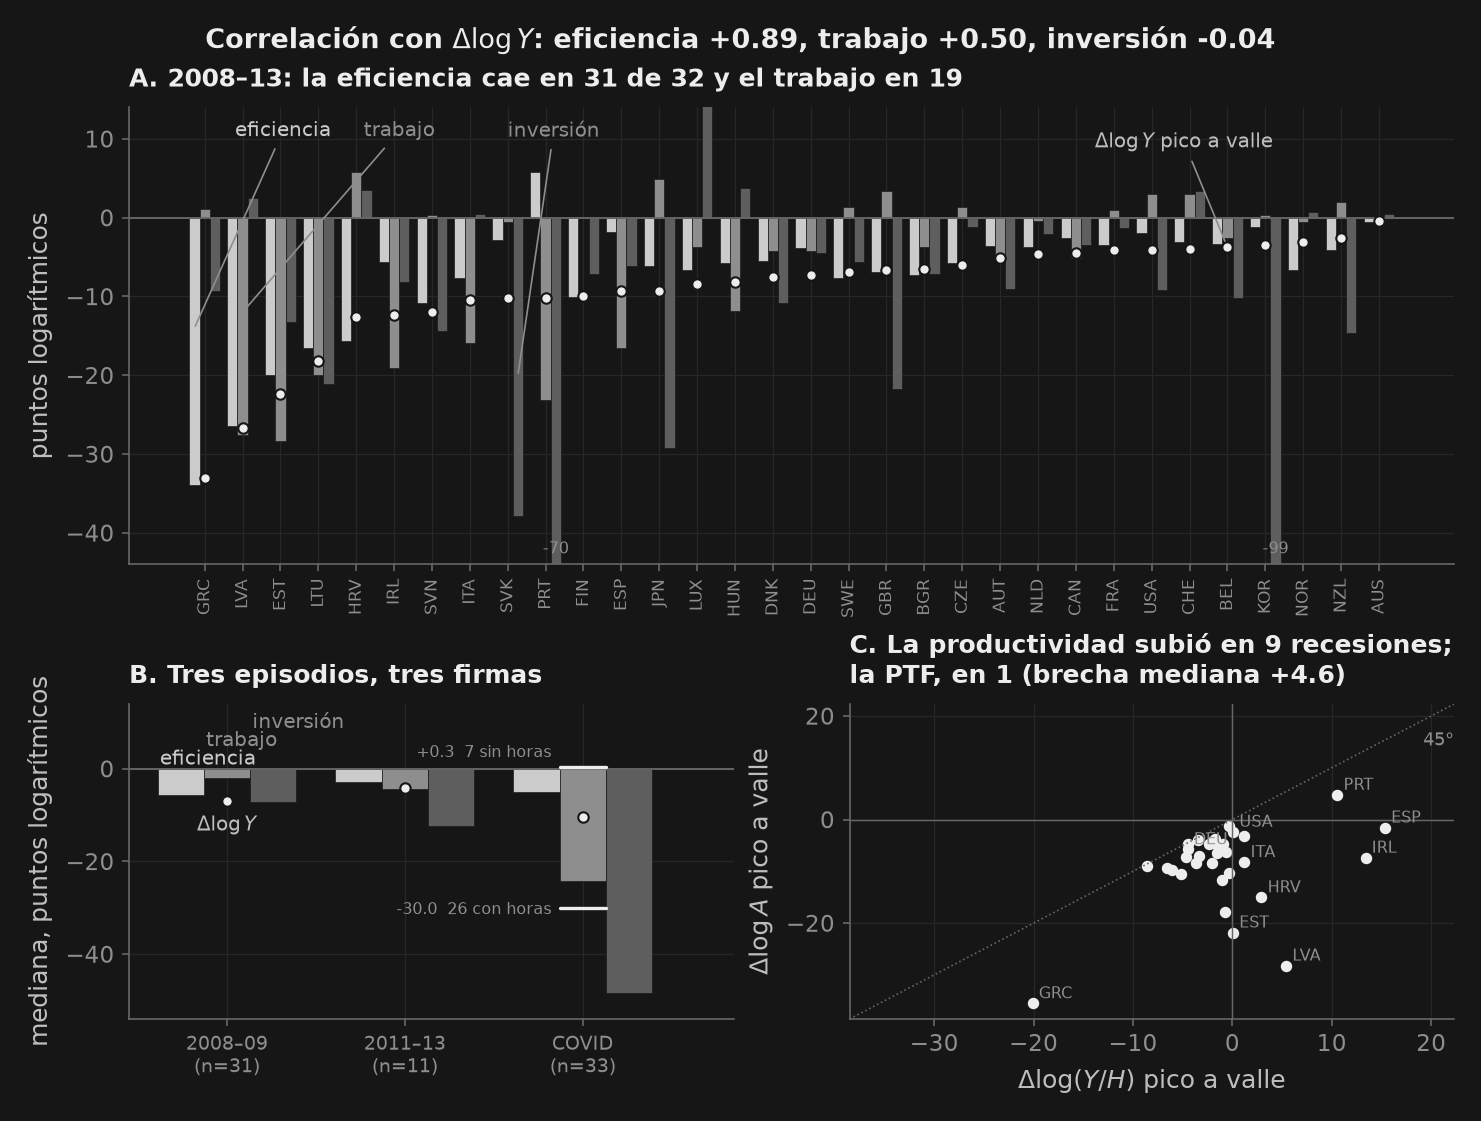

In [10]:
# Tres paneles con el de arriba a todo el ancho: la rejilla no sale de figura(), pero el
# tamaño y el reparto constrained sí son los del curso.
fig = plt.figure(figsize=_nbstyle.TAMANO["2x2"], layout="constrained")
gs = fig.add_gridspec(2, 2, height_ratios=[1.45, 1.0])

axA = fig.add_subplot(gs[0, :])
x = np.arange(len(GR)); w = 0.27
# el tercer tono de barra no llega al contraste del texto: su nombre va en NOTA
CUNAS_FIG = (("d_A", "eficiencia", _nbstyle.BARRA_COLORES[0], _nbstyle.BARRA_COLORES[0]),
             ("d_L", "trabajo", _nbstyle.BARRA_COLORES[1], _nbstyle.BARRA_COLORES[1]),
             ("X_rec", "inversión", _nbstyle.BARRA_COLORES[2], _nbstyle.NOTA))
for j, (v, lbl, col, ctxt) in enumerate(CUNAS_FIG):
    axA.bar(x + (j - 1) * w, GR[v], w, color=col, edgecolor=_nbstyle.FONDO, lw=0.3)
axA.plot(x, GR.d_y, "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=5, zorder=5)
axA.axhline(0, color=_nbstyle.SPINE, lw=0.9)
axA.set_xticks(x); axA.set_xticklabels(GR.index, rotation=90, fontsize=8.4)
axA.set_ylim(-44, 14)
axA.set_ylabel("puntos logarítmicos")
axA.set_title("A. 2008–13: la eficiencia cae en {} de {} y el trabajo en {}".format(
    (GR.d_A < 0).sum(), len(GR), (GR.d_L < 0).sum()))
for c in GR.index[GR.X_rec < -44]:
    i_c = int(np.where(GR.index == c)[0][0])
    axA.annotate(f"{GR.X_rec[c]:+.0f}", (i_c + w, -42.6), fontsize=7.6, ha="center",
                 color=_nbstyle.NOTA)
# El nombre de cada cuña junto a una barra suya, con guía: en una rejilla de 32 países
# no cabe repetirlo grupo a grupo.
for (v, lbl, col, ctxt), xt, (i_c, dj, y_c) in zip(CUNAS_FIG, (0.8, 4.2, 8.0),
                                                   ((0, -1, -14.0), (1, 0, -12.0), (8, 1, -20.0))):
    axA.annotate(lbl, xy=(i_c + dj * w, y_c), xytext=(xt, 11.0), ha="left", va="center",
                 fontsize=9.5, color=ctxt,
                 arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8,
                                 shrinkA=2, shrinkB=1))
axA.annotate("$\\Delta\\log Y$ pico a valle", xy=(27, GR.d_y.iloc[27]), xytext=(23.5, 9.5),
             ha="left", va="center", fontsize=9.5, color=_nbstyle.TEXTO,
             arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8, shrinkA=2, shrinkB=3))

axB = fig.add_subplot(gs[1, 0])
etq = [f"2008–09\n(n={len(EPIS['2008–09'])})", f"2011–13\n(n={len(SOB)})", f"COVID\n(n={len(COV)})"]
xb = np.arange(3); wb = 0.26
for j, (v, lbl, col, ctxt) in enumerate(CUNAS_FIG):
    axB.bar(xb + (j - 1) * wb, [e[v].median() for e in EPIS.values()], wb,
            color=col, edgecolor=_nbstyle.FONDO, lw=0.3)
axB.plot(xb, [e.d_y.median() for e in EPIS.values()], "o", color=_nbstyle.TINTA,
         mec=_nbstyle.FONDO, ms=5, zorder=5)
axB.axhline(0, color=_nbstyle.SPINE, lw=0.9)
for yv, txt, dy in ((ch2.d_L.median(), f"{len(ch2)} con horas", -3),
                    (sh2.d_L.median(), f"{len(sh2)} sin horas", 5)):
    axB.plot([2 - wb / 2, 2 + wb / 2], [yv, yv], color=_nbstyle.TINTA, ls="-", lw=1.6, zorder=6)
    axB.annotate(f"{yv:+.1f}  {txt}", (2 - wb / 2, yv), xytext=(-4, dy),
                 textcoords="offset points", fontsize=7.6, color=_nbstyle.NOTA, ha="right")
axB.set_xticks(xb); axB.set_xticklabels(etq, fontsize=9)
axB.set_ylim(-54, 14); axB.set_xlim(-0.55, 2.85)
axB.set_ylabel("mediana, puntos logarítmicos")
axB.set_title("B. Tres episodios, tres firmas")
# Cada cuña, encima de su propia barra del primer episodio, escalonadas para que no choquen.
for (v, lbl, col, ctxt), j, yl in zip(CUNAS_FIG, (-1, 0, 1), (2.0, 6.0, 10.0)):
    axB.annotate(lbl, ((j - 0.45) * wb, yl), ha="left", va="center", fontsize=9.5, color=ctxt)
axB.annotate("$\\Delta\\log Y$", (0.0, EPIS["2008–09"].d_y.median()), xytext=(0, -7),
             textcoords="offset points", ha="center", va="top", fontsize=9.5,
             color=_nbstyle.TEXTO)

axC = fig.add_subplot(gs[1, 1])
axC.scatter(P.d_yh, P.d_A, s=20, color=_nbstyle.TINTA)
for c in ("ESP", "IRL", "PRT", "LVA", "EST", "GRC", "HRV", "ITA", "DEU", "USA"):
    axC.annotate(c, (P.d_yh[c], P.d_A[c]), fontsize=7.5, xytext=(3, 2.5),
                 textcoords="offset points", color=_nbstyle.NOTA)
lim = [min(P.d_yh.min(), P.d_A.min()) - 3, max(P.d_yh.max(), P.d_A.max()) + 7]
axC.plot(lim, lim, color=_nbstyle.SPINE, lw=0.8, ls=":")
axC.set_xlim(lim); axC.set_ylim(lim)
axC.axhline(0, color=_nbstyle.SPINE, lw=0.7); axC.axvline(0, color=_nbstyle.SPINE, lw=0.7)
axC.annotate("45°", (lim[1] - 4, lim[1] - 4), xytext=(4, -10), textcoords="offset points",
             fontsize=8.5, color=_nbstyle.NOTA)
axC.set_xlabel("$\\Delta\\log(Y/H)$ pico a valle")
axC.set_ylabel("$\\Delta\\log A$ pico a valle")
axC.set_title("C. La productividad subió en {} recesiones;\nla PTF, en {} (brecha mediana "
              "{:+.1f})".format(
                  (P.d_yh > 0).sum(), (P.d_A > 0).sum(), P.d_kh.median()))

fig.suptitle("Correlación con $\\Delta\\log Y$: eficiencia {:+.2f}, trabajo {:+.2f}, "
             "inversión {:+.2f}".format(
                 GR.d_y.corr(GR.d_A), GR.d_y.corr(GR.d_L), GR.d_y.corr(GR.X_rec)))
plt.show()


## 3. La cuña de trabajo no ve el empleo

Alemania perdió 7.3 puntos logarítmicos de producto entre 2008T1 y 2009T1 con el empleo **al alza** en 0.6, y su cuña de trabajo se movió $-2.6$. España perdió 18.2 puntos de empleo y su cuña, $-18.9$, no contiene ni uno: es jornada. Grecia perdió 33.1 puntos de producto —la mayor caída del panel— y su cuña **subió** 5.2. La de Estados Unidos también sube, $+3.0$, con el empleo cayendo 4.1.

Ninguno de esos cuatro números es un hallazgo empírico. Los cuatro salen de una identidad que se deriva en tres líneas. La cuña estática es el cociente entre el producto marginal del trabajo y la relación marginal de sustitución ocio–consumo, con las preferencias del panel ($\sigma=1$, $\nu=2$, $h$ = horas por ocupado sobre 1152, $c=C/E$):

$$\tau_{\text{stat}}=\frac{1}{1-\tau_\ell}=\frac{(1-\alpha)\,Y/H}{\psi\,h^{\nu}c^{\sigma}}.$$

Sustituye $Y=AK^{\alpha}H^{1-\alpha}$ y agrupa: $\log\tau_{\text{stat}}=\log A+\alpha\log K-(\alpha+\nu)\log H+(\nu+\sigma)\log E-\sigma\log C+\text{cte}$. El empleo aparece dos veces —sube el producto, y baja las horas y el consumo *por persona*— y con $\sigma=1$ las dos se cancelan exactamente. Deshaciendo la función de producción queda

$$\log(1-\tau_\ell)=\log\frac{C}{Y}+(1+\nu)\log\frac{H}{E}+\text{cte},\qquad \nu=2\ \Rightarrow\ \text{el }3.$$

Alemania es la identidad en dos números: la jornada aportó $3\times(-3.4)=-10.2$ y el consumo suavizado aportó $+7.6$; el *Kurzarbeit* que T01_A §5 leyó como horas, la cuña casi lo cancela. España es la identidad con el otro reparto: $-19.4$ de jornada y $+0.5$ de $C/Y$, y sus 18.2 puntos de empleo destruido no están en ninguna parte de la fórmula.

**Una nota sobre los datos, porque aquí los datos deciden la respuesta.** El panel mide $h=H/E$, horas por *ocupado*, mientras que Chari, Kehoe y McGrattan miden horas por persona en edad de trabajar. Es la diferencia entre «España no tuvo cuña de trabajo» y «España es la mayor cuña de trabajo de la OCDE», y §3.1 la cuantifica. A eso se suma lo que §1 ya verificó: en los siete países sin horas la cuña de trabajo es **literalmente** $\log(C/Y)$, y con la columna `HOUR` del propio archivo la estadounidense pasa de $+3.0$ a $-4.7$. Que el país sobre el que CKM escribieron el resultado canónico sea uno de los siete no es una casualidad afortunada.

Todo lo de esta sección son diferencias entre dos fechas de un episodio —pico y valle propios, o 2019T4→2020T2—, no segundos momentos: por eso no se aplica el corte en 2019T4 de T01_A §1.1, y por eso 2020 puede entrar.

In [11]:
def _err_cte(x, y):
    """Máximo |x − y| dentro de cada país, quitando su constante propia."""
    r = pd.DataFrame({"code": CUNAS["code"], "r": x - y})
    return float(r.groupby("code")["r"].apply(lambda s: (s - s.mean()).abs().max()).max())


lY, lH, lE, lC, lK = (np.log(CUNAS[k]) for k in ("Y", "H", "EMP", "C", "K"))
e_def = (lY - lH) - NU * (lH - lE) - SIGMA * (lC - lE)                 # log MPL − log MRS
e_prd = (CUNAS["logA"] + CUNAS["alpha_c"] * lK - (CUNAS["alpha_c"] + NU) * lH
         + (NU + SIGMA) * lE - SIGMA * lC)
err_def, err_prd = _err_cte(e_def, CUNAS["logS"]), _err_cte(e_prd, CUNAS["logS"])
err = _err_cte(CUNAS["cunaL"] / 100.0,
               (1 + NU) * np.log(CUNAS["H"] / CUNAS["EMP"]) + np.log(CUNAS["C"] / CUNAS["Y"]))
print(f"log τ_stat = log(MPL) − log(MRS): residuo dentro de país {err_def:.1e}")
print(f"…con Y = A·K^α·H^(1−α): log A + α log K − (α+ν) log H + (ν+σ) log E − σ log C, "
      f"residuo {err_prd:.1e}")
print("…y como log A + α log K = log Y − (1−α) log H, las dos se juntan en")
print(f"  log(1−τ_ℓ) = log(C/Y) + (1+ν)·log(H/E) + cte,  ν = {NU:.0f}: residuo máximo "
      f"{err:.1e} en {len(CUNAS):,} observaciones. El empleo no aparece.")
assert max(err_def, err_prd) < 1e-11 and err < 1e-11

filas = []
for c in CODIGOS:
    pk, tr = REC[c]
    r = {"code": c, "pico": str(pk.to_period("Q")), "valle": str(tr.to_period("Q"))}
    for col in ("y", "e", "hpe", "cy", "L"):
        r["d_" + col] = dif(c, col, pk, tr)
    filas.append(r)
rec = pd.DataFrame(filas).set_index("code")
assert (rec["d_L"] - ((1 + NU) * rec["d_hpe"] + rec["d_cy"])).abs().max() < 1e-9
CAYERON = list(rec.index[rec["d_y"] < -0.5])
print(f"\nGran Recesión, pico y valle propios: {len(CAYERON)} de {len(rec)} cayeron más de "
      f"medio punto logarítmico (fuera: {', '.join(sorted(set(rec.index) - set(CAYERON)))}).\n")
print(rec.loc[CAYERON, ["pico", "valle", "d_y", "d_e", "d_hpe", "d_cy", "d_L"]]
      .rename(columns={"d_y": "ΔlogY", "d_e": "ΔlogE", "d_hpe": "Δlog(H/E)",
                       "d_cy": "Δlog(C/Y)", "d_L": "Δlog(1−τ_l)"})
      .sort_values("Δlog(1−τ_l)").to_string(float_format=lambda v: f"{v:.1f}"))

print("\nCuatro casos, término a término (puntos logarítmicos, pico→valle):")
for c in ("DEU", "ESP", "GRC", "USA"):
    r = rec.loc[c]
    print(f"  {c} {r['pico']}→{r['valle']}: ΔlogY {r['d_y']:+6.1f} | empleo {r['d_e']:+6.1f} | "
          f"3·Δlog(H/E) {3 * r['d_hpe']:+6.1f} + Δlog(C/Y) {r['d_cy']:+5.1f} = "
          f"cuña {r['d_L']:+6.1f}")
corr_E = float(np.corrcoef(rec.loc[CAYERON, "d_e"], rec.loc[CAYERON, "d_L"])[0, 1])
con_h = [c for c in CAYERON if c not in SIN_HORAS]
corr_he = float(np.corrcoef(rec.loc[con_h, "d_hpe"], rec.loc[con_h, "d_L"])[0, 1])
print(f"\nEn el corte transversal corr(cuña, ΔlogE) = {corr_E:+.2f} (n = {len(CAYERON)}); "
      f"corr(cuña, Δlog(H/E)) = {corr_he:+.2f} (n = {len(con_h)}).")
print("La identidad dice cuál de las dos es mecánica: la segunda. La primera la fabrican los\n"
      "bálticos e Irlanda, que recortaron los dos márgenes a la vez.")
print(f"Los {len(SIN_HORAS)} países sin horas: la cuña es Δlog(C/Y) y subió en "
      f"{sum(rec.loc[c, 'd_L'] > 0 for c in SIN_HORAS)} de {len(SIN_HORAS)} — "
      + ", ".join(f"{c} {rec.loc[c, 'd_L']:+.1f}" for c in SIN_HORAS) + ".")
assert abs(rec.loc["DEU", "d_L"] + 2.6) < 0.3 and abs(rec.loc["ESP", "d_L"] + 18.9) < 0.3
assert rec.loc["GRC", "d_L"] > 0 and rec.loc["USA", "d_L"] > 0
assert sum(rec.loc[c, "d_L"] > 0 for c in SIN_HORAS) == 7

log τ_stat = log(MPL) − log(MRS): residuo dentro de país 1.8e-14
…con Y = A·K^α·H^(1−α): log A + α log K − (α+ν) log H + (ν+σ) log E − σ log C, residuo 1.8e-14
…y como log A + α log K = log Y − (1−α) log H, las dos se juntan en
  log(1−τ_ℓ) = log(C/Y) + (1+ν)·log(H/E) + cte,  ν = 2: residuo máximo 1.8e-14 en 3,366 observaciones. El empleo no aparece.

Gran Recesión, pico y valle propios: 31 de 33 cayeron más de medio punto logarítmico (fuera: AUS, POL).

        pico   valle  ΔlogY  ΔlogE  Δlog(H/E)  Δlog(C/Y)  Δlog(1−τ_l)
code                                                                 
IRL   2007Q4  2009Q4  -12.3  -12.4      -13.3        8.9        -31.0
LVA   2007Q3  2010Q3  -26.6  -22.6       -9.5        3.9        -24.6
EST   2007Q3  2009Q3  -22.4  -12.1      -10.4        7.9        -23.2
PRT   2007Q4  2012Q4  -10.2  -12.6       -8.2        2.5        -22.0
LTU   2008Q2  2009Q4  -18.2  -12.0       -5.5       -2.7        -19.3
ESP   2008Q2  2013Q3   -9.3  -18.2       -6.5      

### 3.1 La misma recesión, medida por activo: España pasa de $-19$ a $-77$

La cuña de CKM se construye por persona en edad de trabajar, no por ocupado. El panel no trae población, pero sí hay tasa de paro armonizada: `oecd_urate_q.csv` da $u$ trimestral y $LF=E/(1-u)$ es una aproximación a la población de referencia —la **fuerza laboral**, no los adultos, y esa es la advertencia que hay que decir en voz alta—. Cambiar el denominador añade un solo término, porque $\log(H/LF)=\log(H/E)+\log(1-u)$:

$$\Delta\log(1-\tau_\ell)^{LF}=\Delta\log(1-\tau_\ell)+(1+\nu)\,\Delta\log(1-u).$$

El 3 que multiplica al paro es el mismo $(1+\nu)$ de antes: es una elección de calibración, no un dato. Con $\nu=1$ en lugar de 2, España queda en $-57.5$ (o en $-51.0$ si además se recalcula la parte de jornada), no en $-76.8$. Lo que no depende de $\nu$ es el **orden** —España y Grecia arriba, Alemania abajo— ni el vuelco de signo griego.

In [12]:
u = pd.read_csv(DATOS / "oecd_urate_q.csv", parse_dates=["date"])
PARO = {c: g.set_index("date")["urate"].sort_index()
        for c, g in u.groupby("code") if c in CODIGOS}
rec["d_1u"] = np.nan
for c in PARO:
    pk, tr = REC[c]
    if pk in PARO[c].index and tr in PARO[c].index:
        rec.loc[c, "d_1u"] = 100 * float(np.log(1 - PARO[c].loc[tr] / 100)
                                         - np.log(1 - PARO[c].loc[pk] / 100))
rec["d_L_LF"] = rec["d_L"] + (1 + NU) * rec["d_1u"]                # ν = 2, la del panel
rec["d_L_nu1"] = rec["d_L"] + 2.0 * rec["d_1u"]                    # sólo la corrección, ν = 1
rec["d_L_nu1c"] = rec["d_cy"] + 2.0 * (rec["d_hpe"] + rec["d_1u"])  # toda la cuña, con ν = 1
lf = rec.loc[[c for c in CAYERON if np.isfinite(rec.loc[c, "d_L_LF"])]]
print(f"Cuña por activo, LF = E/(1−u): n = {len(lf)}; oecd_urate_q.csv no trae "
      f"{', '.join(sorted(set(CODIGOS) - set(PARO)))}.\n")
print(lf[["d_e", "d_L", "d_1u", "d_L_LF"]]
      .rename(columns={"d_e": "ΔlogE", "d_L": "por ocupado", "d_1u": "Δlog(1−u)",
                       "d_L_LF": "por activo"})
      .sort_values("por activo").to_string(float_format=lambda v: f"{v:.1f}"))
corr_LF = float(np.corrcoef(lf["d_e"], lf["d_L_LF"])[0, 1])
print(f"\nMediana |cuña|: por ocupado {rec['d_L'].abs().median():.1f} p.l., por activo "
      f"{lf['d_L_LF'].abs().median():.1f} p.l. corr con ΔlogE: "
      f"{float(np.corrcoef(lf['d_e'], lf['d_L'])[0, 1]):+.2f} por ocupado, "
      f"{corr_LF:+.2f} por activo.")
for c in ("ESP", "GRC", "USA", "DEU"):
    print(f"  {c}: {rec.loc[c, 'd_L']:+6.1f} → {rec.loc[c, 'd_L_LF']:+6.1f} "
          f"(u {PARO[c].loc[REC[c][0]]:.1f}% → {PARO[c].loc[REC[c][1]]:.1f}%, corrección "
          f"{(1 + NU) * rec.loc[c, 'd_1u']:+.1f}; con ν = 1: {rec.loc[c, 'd_L_nu1']:+.1f}, "
          f"o {rec.loc[c, 'd_L_nu1c']:+.1f} recalculando también la jornada)")
assert abs(rec.loc["ESP", "d_L_LF"] + 76.8) < 0.5 and abs(rec.loc["GRC", "d_L_LF"] + 64.2) < 0.5
assert abs(corr_LF - 0.95) < 0.02

Cuña por activo, LF = E/(1−u): n = 26; oecd_urate_q.csv no trae BGR, HRV, LTU, LVA.

      ΔlogE  por ocupado  Δlog(1−u)  por activo
code                                           
ESP   -18.2        -18.9      -19.3       -76.8
GRC   -11.7          5.2      -23.1       -64.2
IRL   -12.4        -31.0       -9.6       -59.7
EST   -12.1        -23.2      -11.1       -56.6
PRT   -12.6        -22.0       -9.9       -51.7
ITA    -4.4        -16.9       -6.4       -36.1
HUN    -2.6        -10.7       -3.0       -19.6
SVN    -7.3          1.4       -5.6       -15.3
DNK    -1.8         -5.3       -3.1       -14.7
CAN    -1.9         -6.3       -2.6       -14.0
USA    -4.1          3.0       -4.3        -9.8
BEL     0.2         -3.3       -1.3        -7.3
FIN    -1.4         -0.3       -2.2        -6.9
AUT    -0.5         -2.5       -1.3        -6.3
SVK    -1.1         -1.1       -1.6        -5.9
GBR    -2.0          2.9       -2.8        -5.4
SWE    -1.2          0.5       -1.5        -3.9
LUX

### 3.2 Un contrafactual que no exige resolver el modelo

La condición intratemporal es **estática**: dados $A$, $K$, $C$ y $E$, la cuña es proporcional a $H^{-(\alpha+\nu)}$ —ese es el coeficiente que apareció al sustituir la función de producción—. Así que las horas que se habrían trabajado con $\tau_\ell$ en su media de 2000–06 se despejan sin conocer $\psi$ y sin resolver nada:

$$\log\frac{H^{*}}{H}=\frac{\log S-\overline{\log S}_{2000\text{–}06}}{\alpha+\nu}.$$

El resultado es un contraste, no un promedio: en 2008–13 la cuña de trabajo debe la mediana del **28%** de las horas perdidas; en 2020T2, el **86%** (91% entre los 26 países que sí miden horas). 2020 fue una recesión de jornada —ERTE, *Kurzarbeit*, *chômage partiel*—, y el prototipo la lee entera; 2008–13 fue una recesión de empleos, y el prototipo no la ve.

Es *casi* álgebra: el contrafactual vale $[3\Delta\log(H/E)+\Delta\log(C/Y)]/(\alpha+2)$, así que devolver horas es devolver jornada por definición. La parte que **no** es tautología es $\Delta\log(C/Y)$, y es la que hace de Alemania un caso pequeño y le cambia el signo a Grecia. Y es equilibrio parcial: mantiene $C$ y $K$ en sus valores observados, cuando en equilibrio $C$ subiría y con ella la relación marginal de sustitución. §4 hace la versión de equilibrio general, alimentando el prototipo con una cuña a la vez.

In [13]:
COVID = (pd.Timestamp("2019-10-01"), pd.Timestamp("2020-04-01"))
CF = {}
for c in CODIGOS:                      # log(H*/H), país por país
    g = PAIS[c]
    CF[c] = 100 * (g["logS"] - g.loc["2000-01-01":"2006-12-31", "logS"].mean()) / (g["alpha"] + NU)
filas = []
for c in CODIGOS:
    pk, tr = REC[c]
    filas.append({"code": c, "dlH_GR": dif(c, "h", pk, tr),
                  "debe_GR": -float(CF[c].loc[tr] - CF[c].loc[pk]),
                  "dlH_CV": dif(c, "h", *COVID),
                  "debe_CV": -float(CF[c].loc[COVID[1]] - CF[c].loc[COVID[0]]),
                  "alpha": float(PAIS[c]["alpha"].iloc[0])})
cf = pd.DataFrame(filas).set_index("code")
cf["sh_GR"], cf["sh_CV"] = cf["debe_GR"] / cf["dlH_GR"], cf["debe_CV"] / cf["dlH_CV"]
assert (cf["debe_GR"] - rec["d_L"] / (cf["alpha"] + NU)).abs().max() < 1e-9   # es ΔL/(α+ν)

cfc, cfh = cf.loc[CAYERON], cf.drop(index=SIN_HORAS)
m_gr, m_cv = float(cfc["sh_GR"].median()), float(cf["sh_CV"].median())
print(f"2008–13 (n = {len(cfc)}): la cuña debe la mediana del {m_gr:.0%} de las horas perdidas "
      f"(agregado {-cfc['debe_GR'].sum() / -cfc['dlH_GR'].sum():.0%}; "
      f"{cfc.drop(index=[c for c in SIN_HORAS if c in cfc.index])['sh_GR'].median():.0%} "
      f"entre los que miden horas)")
print(f"2019T4→2020T2 (n = {len(cf)}): el {m_cv:.0%} "
      f"(agregado {-cf['debe_CV'].sum() / -cf['dlH_CV'].sum():.0%}; "
      f"{cfh['sh_CV'].median():.0%} entre los {len(cfh)} con horas)\n")
for c in ("DEU", "ESP", "GRC", "USA"):
    print(f"  {c}: 2008–13 horas {cf.loc[c, 'dlH_GR']:+6.1f}, la cuña debe "
          f"{cf.loc[c, 'debe_GR']:+6.1f} ({cf.loc[c, 'sh_GR']:5.0%}) | 2020T2 horas "
          f"{cf.loc[c, 'dlH_CV']:+6.1f}, debe {cf.loc[c, 'debe_CV']:+6.1f} "
          f"({cf.loc[c, 'sh_CV']:5.0%})")
a_med = float(cf["alpha"].median())
print(f"\nCasi álgebra: debe = [3Δlog(H/E) + Δlog(C/Y)]/(α+2) ≈ {3 / (a_med + 2):.1f}·Δlog(H/E) + "
      f"{1 / (a_med + 2):.1f}·Δlog(C/Y) con la α mediana {a_med:.2f}; lo que no es tautología "
      f"es Δlog(C/Y):\n  su mediana entre los {len(cfc)} aporta "
      f"{rec.loc[CAYERON, 'd_cy'].median():+.1f} p.l. frente a "
      f"{3 * rec.loc[CAYERON, 'd_hpe'].median():+.1f} de jornada, y en Grecia "
      f"{rec.loc['GRC', 'd_cy']:+.1f} frente a {3 * rec.loc['GRC', 'd_hpe']:+.1f} — "
      f"es el consumo, no la jornada, lo que le da signo positivo.")
assert abs(m_gr - 0.28) < 0.03 and abs(m_cv - 0.86) < 0.03

2008–13 (n = 31): la cuña debe la mediana del 28% de las horas perdidas (agregado 23%; 29% entre los que miden horas)
2019T4→2020T2 (n = 33): el 86% (agregado 83%; 91% entre los 26 con horas)

  DEU: 2008–13 horas   -2.8, la cuña debe   -1.1 (  38%) | 2020T2 horas   -9.7, debe   -9.8 ( 101%)
  ESP: 2008–13 horas  -24.7, la cuña debe   -7.5 (  30%) | 2020T2 horas  -36.6, debe  -31.3 (  85%)
  GRC: 2008–13 horas  -13.0, la cuña debe   +2.0 ( -15%) | 2020T2 horas  -34.4, debe  -32.0 (  93%)
  USA: 2008–13 horas   -4.1, la cuña debe   +1.2 ( -30%) | 2020T2 horas  -13.8, debe   +0.5 (  -4%)

Casi álgebra: debe = [3Δlog(H/E) + Δlog(C/Y)]/(α+2) ≈ 1.2·Δlog(H/E) + 0.4·Δlog(C/Y) con la α mediana 0.52; lo que no es tautología es Δlog(C/Y):
  su mediana entre los 31 aporta +5.1 p.l. frente a -9.0 de jornada, y en Grecia +9.0 frente a -3.8 — es el consumo, no la jornada, lo que le da signo positivo.


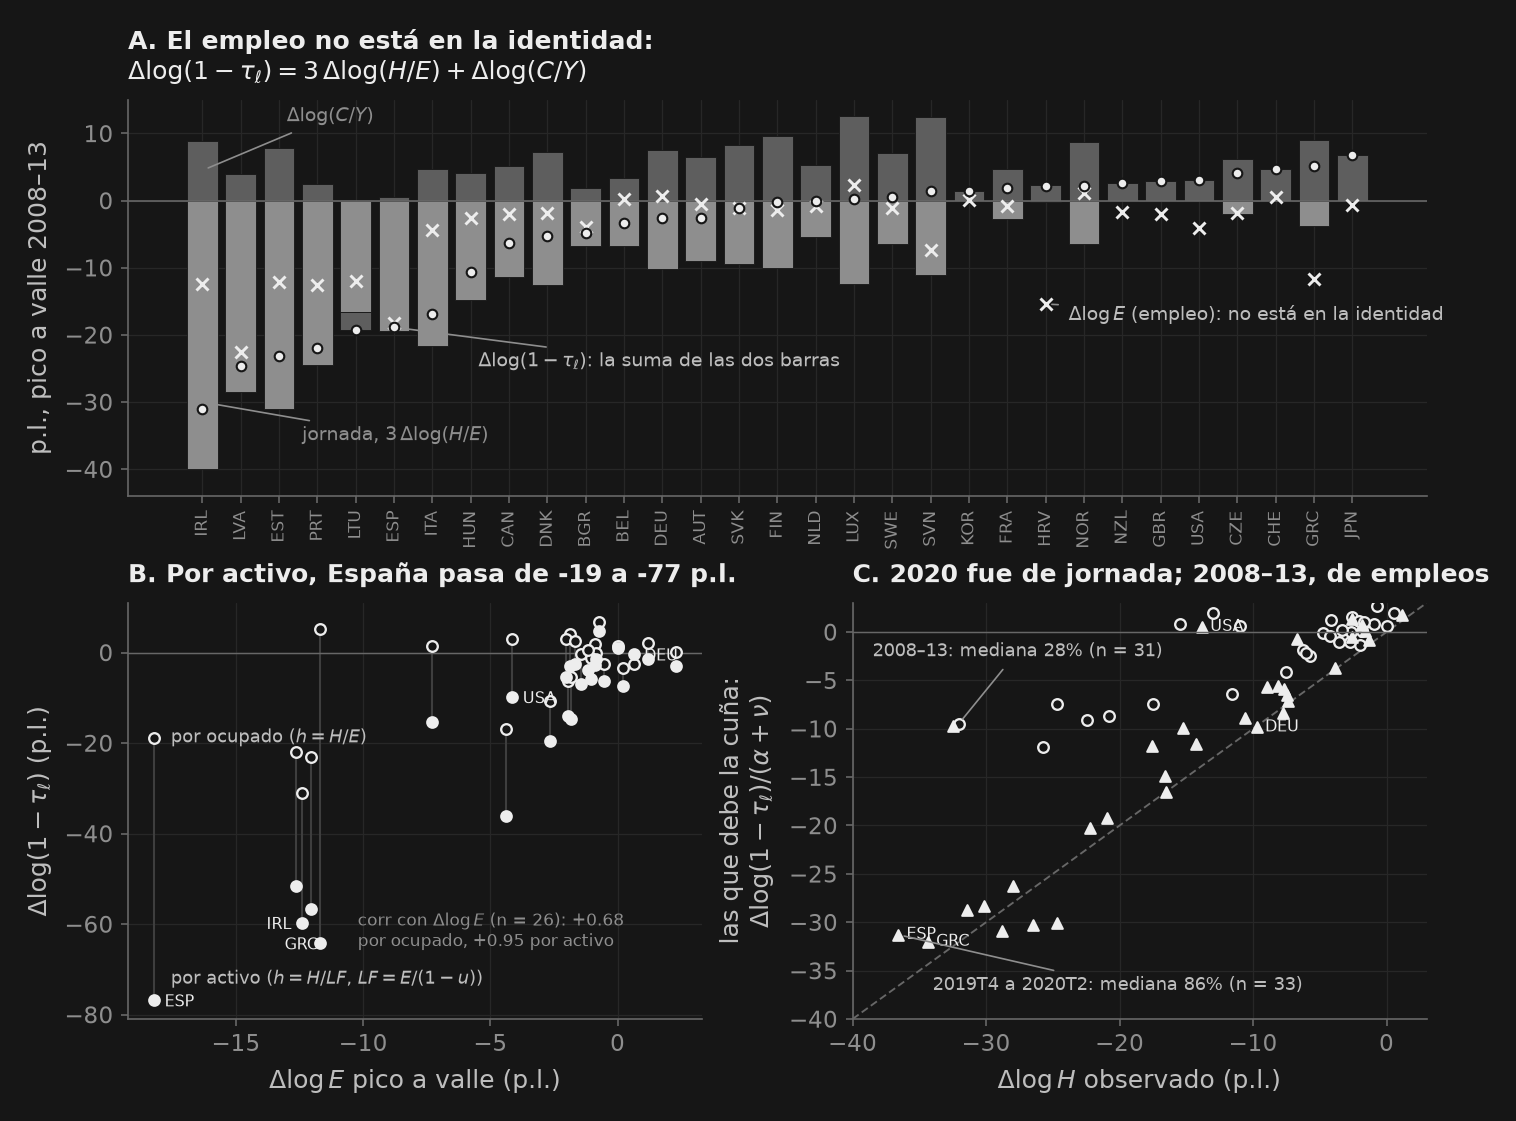

In [14]:
# Un panel ancho arriba y dos abajo: la rejilla no sale de figura(), el tamaño sí.
fig = plt.figure(figsize=_nbstyle.TAMANO["2x2"], layout="constrained")
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05])

ax = fig.add_subplot(gs[0, :])
r = rec.loc[CAYERON].sort_values("d_L")
x = np.arange(len(r))
bp = np.zeros(len(r)); bn = np.zeros(len(r))
for k, mult, col in (("d_hpe", 3.0, _nbstyle.BARRA_COLORES[1]),
                     ("d_cy", 1.0, _nbstyle.BARRA_COLORES[2])):
    v = mult * r[k].to_numpy()
    base = np.where(v >= 0, bp, bn)
    ax.bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    bp = bp + np.where(v >= 0, v, 0.0); bn = bn + np.where(v < 0, v, 0.0)
ax.plot(x, r["d_L"], "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=4.6, zorder=5)
ax.plot(x, r["d_e"], "x", color=_nbstyle.TINTA, ms=6, mew=1.4, zorder=4)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(r.index, rotation=90, fontsize=8)
ax.set_ylim(-44, 15); ax.set_ylabel("p.l., pico a valle 2008–13")
ax.set_title("A. El empleo no está en la identidad:\n"
             "$\\Delta\\log(1-\\tau_\\ell)=3\\,\\Delta\\log(H/E)+\\Delta\\log(C/Y)$")
# Cada pieza junto a una barra o un marcador suyos, con guía.
_i_esp = int(np.where(r.index == "ESP")[0][0]); _i_hrv = int(np.where(r.index == "HRV")[0][0])
GUIAS = (("jornada, $3\\,\\Delta\\log(H/E)$", _nbstyle.BARRA_COLORES[1], (2.6, -35.0),
          (0.0, -30.0)),
         ("$\\Delta\\log(C/Y)$", _nbstyle.NOTA, (2.2, 12.5), (0.0, 4.5)),
         ("$\\Delta\\log(1-\\tau_\\ell)$: la suma de las dos barras", _nbstyle.TEXTO,
          (float(_i_esp) + 2.2, -24.0), (float(_i_esp), float(r["d_L"].iloc[_i_esp]))),
         ("$\\Delta\\log E$ (empleo): no está en la identidad", _nbstyle.TEXTO,
          (float(_i_hrv) + 0.6, -17.0), (float(_i_hrv), float(r["d_e"].iloc[_i_hrv]))))
for txt, col, xy_txt, xy_pt in GUIAS:
    ax.annotate(txt, xy=xy_pt, xytext=xy_txt, ha="left", va="center", fontsize=9,
                color=col, arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8,
                                           shrinkA=3, shrinkB=3))

ax = fig.add_subplot(gs[1, 0])
for c in lf.index:
    ax.plot([lf.loc[c, "d_e"]] * 2, [lf.loc[c, "d_L"], lf.loc[c, "d_L_LF"]],
            color=_nbstyle.gris("0.72"), ls="-", lw=1.0, zorder=1)
ax.scatter(lf["d_e"], lf["d_L"], s=26, facecolors=_nbstyle.FONDO,
           edgecolors=_nbstyle.TINTA, lw=1.1, zorder=3)
ax.scatter(lf["d_e"], lf["d_L_LF"], s=26, color=_nbstyle.TINTA, zorder=3)
for c in ("ESP", "GRC", "USA", "DEU", "IRL"):
    ax.annotate(c, (lf.loc[c, "d_e"], lf.loc[c, "d_L_LF"]), fontsize=7.6,
                textcoords="offset points",
                xytext=(5, -3) if c in ("ESP", "USA", "DEU") else (-17, -3))
ax.annotate("por ocupado ($h=H/E$)", (lf.loc["ESP", "d_e"], lf.loc["ESP", "d_L"]),
            xytext=(8, 0), textcoords="offset points", fontsize=8.6, va="center",
            color=_nbstyle.TEXTO)
ax.annotate("por activo ($h=H/LF$, $LF=E/(1-u)$)",
            (lf.loc["ESP", "d_e"], lf.loc["ESP", "d_L_LF"]), xytext=(8, 10),
            textcoords="offset points", fontsize=8.6, va="center", color=_nbstyle.TEXTO)
ax.annotate(f"corr con $\\Delta\\log E$ (n = {len(lf)}): "
            f"{float(np.corrcoef(lf['d_e'], lf['d_L'])[0, 1]):+.2f}\npor ocupado, "
            f"{corr_LF:+.2f} por activo", (0.40, 0.26), xycoords="axes fraction",
            fontsize=8.2, color=_nbstyle.NOTA, va="top")
ax.axhline(0, color=_nbstyle.SPINE, lw=0.7)
ax.set_xlabel("$\\Delta\\log E$ pico a valle (p.l.)")
ax.set_ylabel("$\\Delta\\log(1-\\tau_\\ell)$ (p.l.)")
ax.set_title(f"B. Por activo, España pasa de {rec.loc['ESP', 'd_L']:+.0f} a "
             f"{rec.loc['ESP', 'd_L_LF']:+.0f} p.l.")

ax = fig.add_subplot(gs[1, 1])
lim = [-40, 3]
ax.plot(lim, lim, color=_nbstyle.SPINE, lw=0.9, ls=(0, (4, 2)), zorder=1)
ax.scatter(cfc["dlH_GR"], cfc["debe_GR"], s=26, facecolors=_nbstyle.FONDO,
           edgecolors=_nbstyle.TINTA, lw=1.1)
ax.scatter(cf["dlH_CV"], cf["debe_CV"], s=26, color=_nbstyle.TINTA, marker="^")
for c in ("ESP", "GRC", "USA", "DEU"):
    ax.annotate(c, (cf.loc[c, "dlH_CV"], cf.loc[c, "debe_CV"]), fontsize=7.6,
                xytext=(4, -2), textcoords="offset points")
_c0 = cfc["dlH_GR"].idxmin()
ax.annotate(f"2008–13: mediana {m_gr:.0%} (n = {len(cfc)})",
            (cfc.loc[_c0, "dlH_GR"], cfc.loc[_c0, "debe_GR"]),
            xytext=(-38.5, -2.0), ha="left", va="center", fontsize=8.6, color=_nbstyle.TEXTO,
            arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8, shrinkA=3, shrinkB=3))
ax.annotate(f"2019T4 a 2020T2: mediana {m_cv:.0%} (n = {len(cf)})",
            (cf.loc["ESP", "dlH_CV"], cf.loc["ESP", "debe_CV"]), xytext=(-34.0, -36.5),
            ha="left", va="center", fontsize=8.6, color=_nbstyle.TEXTO,
            arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8, shrinkA=3, shrinkB=3))
ax.axhline(0, color=_nbstyle.SPINE, lw=0.7); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("$\\Delta\\log H$ observado (p.l.)")
ax.set_ylabel("las que debe la cuña:\n$\\Delta\\log(1-\\tau_\\ell)/(\\alpha+\\nu)$")
ax.set_title("C. 2020 fue de jornada; 2008–13, de empleos")
plt.show()


## 4. Una cuña a la vez

**Alemania perdió su Gran Recesión por la cuña de eficiencia y España por la de trabajo, y en ninguno de los tres países la cuña de inversión movió el producto.** Resuelto el prototipo y alimentado con **una** cuña medida a la vez —las otras tres en su valor de senda balanceada—, la de eficiencia reproduce el 98 % del hueco alemán y el $-0.1$ % del español; la de trabajo, el 119 % del español y el 0 % del alemán. Estados Unidos es el único que reparte, y su reparto depende de una columna: 68 / 38 con las horas que el panel le imputa ($H=480\cdot E$), **44 / 61** con la serie `HOUR` que el panel lleva y no usa. La cuña de inversión se queda entre $-13.5$ % y $+1.1$ % en los tres países, y el caso alemán es el que conviene memorizar: esa cuña **cae 5.7 puntos logarítmicos** leída en dos fechas —**4.4** con el promedio de la recesión contra el de los cuatro trimestres previos, que es el estadístico que §2 declaró defendible para un flujo— y con eso sola produce el **1.1 %** de la recesión. Una cuña que se mueve no es una economía que se mueve.

El prototipo es el de la lámina, con las cuatro cuñas entrando una por ecuación: la eficiencia $A_t$ en la función de producción, la de trabajo $1-\tau_{\ell,t}$ en la intratemporal, la de inversión $1+\tau_{x,t}$ en la Euler, y la de gasto $g_t=y_t-c_t-x_t$ —un nivel, no una participación— en la restricción de recursos. Las incógnitas son las sendas de $k_{t+1}$ y $h_t$ sobre 2000T1–2019T4; $k_1$ y $k_{T+1}$ salen del acervo de capital del panel; el sistema de $2T$ ecuaciones se resuelve por Newton con un jacobiano de banda 6. No hay Dynare ni linealización: es el modelo no lineal con previsión perfecta.

**Y no es la única forma de correrlo.** La lección 04b resuelve este mismo experimento log-linealizado, con `puremacro.dsge.klein_solve` y sobre seis países, cerrando las expectativas con un VAR(1) de las cuñas. Vale la pena tener las dos rutas a la vista, porque cada una regala algo que la otra no puede dar. Allí la solución es lineal, así que la descomposición entre cuñas es aditiva por superposición **exactamente**, y las cuotas suman la simulación conjunta por construcción; aquí no, y §4.3 mide cuánto cuesta perder esa comodidad. Aquí la corrida con las cuatro cuñas juntas devuelve el dato al bit y por eso sirve de prueba de unidad; allí no puede servir, porque la aproximación lineal deja un residuo. Y en cómo se cierran las expectativas la ventaja es de 04b, no de este cuaderno: eso es lo siguiente.

### Una nota sobre los datos, porque decide el reparto entero

**Primera: la prueba de unidad es la lección.** Con las cuatro cuñas juntas, el prototipo devuelve el dato con un error de $4\cdot10^{-15}$ en el producto en EUA, y de $1\cdot10^{-13}$ en el peor de las seis corridas de esta celda. Eso *no* es evidencia a favor del modelo neoclásico: es la definición de las cuñas, y es exactamente la advertencia de la lámina. Lo único que prueba es que las ecuaciones programadas aquí son las mismas con las que el panel midió las cuñas — y esa prueba hace falta, porque el solucionador arranca de la senda **sin** cuñas y vuelve al dato en cuatro o cinco iteraciones de Newton.

**Segunda: el panel normaliza por ocupados, y esa decisión reparte la recesión.** El panel define $l_t=(H_t/E_t)/1152$, así que la ocupación es un **quinto** insumo exógeno del prototipo, y §3 ya dijo por qué: la cuña de trabajo no ve el empleo. Aquí se paga. Con la convención del panel la ocupación española reproduce ella sola el 102 % de su recesión y la cuña de trabajo el 17 %. Puesto el margen extensivo donde lo pone Chari–Kehoe–McGrattan —$l_t$ medido sobre una población de tendencia, de modo que el empleo entre *dentro* de la cuña de trabajo— la cuña española pasa al 119 % y la estadounidense del $-11$ % al 38 %. Se reportan las dos; las figuras usan la de CKM. Y hay que decir qué es esa «población de tendencia», porque fija el denominador de todas las cuotas: es la extrapolación log-lineal del empleo de 2000–06, y en España eso son **3.47 % al año** — el auge de la construcción, no una demografía. La robustez (e) de §4.2 la sustituye por un 1 % anual: el hueco español pasa de $-21.4$ a $-13.1$ puntos y la cuota de trabajo del 118.5 % al 130.3 %. **El reparto aguanta; el tamaño del hueco no.**

**Tercera: medición y simulación comparten un supuesto, y por eso el ajuste es exacto.** CKM tratan el vector de cuñas como un VAR(1) y toman $E_t$ bajo él, y **la lección 04b hace exactamente eso** —estima ese VAR(1) por mínimos cuadrados sobre las cuñas medidas y suavizadas, y resuelve el prototipo bajo él—; aquí hay previsión perfecta. Dicho sin rodeos: en este punto 04b está más cerca de CKM que este cuaderno, y el atajo hay que defenderlo, no esconderlo. Es defendible por una razón concreta y no por comodidad: el `tau_dyn` del panel se mide con el consumo **realizado** $C_{t+1}/C_t$ e imponiendo $\tau_{x,t+1}=\tau_{x,t}$, es decir, ya está medido bajo previsión perfecta. Sólo la cuña de inversión vive dentro de la esperanza, así que sólo ella cambiaría. Cuánto: la secuencia de $\tau_x$ internamente consistente —recursión hacia atrás sobre la Euler con sus dos fechas— tiene desviación típica de 2.3 puntos logarítmicos en EUA frente a 6.6 la del panel, y correlaciona $+0.21$ con ella. El atajo no es inocuo. Lo que salva al experimento es que la cuña de inversión no mueve el producto ni siquiera con la volatilidad inflada. Y el VAR tampoco sale gratis: la matriz $P$ es una elección de especificación más —qué entra, cuántos rezagos, sobre qué ventana y con qué suavizado— que se cuela en el reparto. Las dos rutas ponen un supuesto donde el dato no llega; lo que no se vale es no decir cuál.

**Cuarta: la cuña de gasto de este panel es el saldo externo**, como midió §1. El `C` del panel es consumo final **total** menos duraderos —el consumo público está dentro, y su tamaño es justamente la segunda mediana de §1, cerca del 20 % del PIB—, así que $g_t=y_t-c_t-x_t$ acaba siendo exportaciones netas más existencias: corr$(\Delta g,\Delta XN)\ge 0.99$ en los tres países. Las compras públicas no están en la cuña de gasto; están dentro del consumo con el que se miden las cuñas de trabajo y de inversión. Un experimento «sólo cuña de gasto» está alimentando al prototipo con el sector externo, no con política fiscal.

In [15]:
INI, FIN = "2000-01-01", "2019-10-01"        # ventana de simulación (2020 no es un ciclo)
EPI0, EPI1 = "2006-01-01", "2013-10-01"      # ventana del episodio, la de la figura
N0 = 28                                      # 2000T1–2006T4: la senda balanceada del panel
NOM = {"A": "eficiencia", "S": "trabajo", "Dt": "inversión", "G": "gasto", "N": "ocupación"}
TRES = ("USA", "ESP", "DEU")
NB = {"USA": "EUA", "ESP": "España", "DEU": "Alemania"}


def pais_bca(code):
    """Datos y calibración: alpha, beta y psi salen del panel, no se inventa nada."""
    u = CUNAS[CUNAS["code"] == code].sort_values("date").set_index("date")
    al, be, ps = (float(u[c].iloc[0]) for c in ("alpha_c", "beta_c", "psi_c"))
    w = u.loc[INI:FIN]
    d = dict(code=code, al=al, be=be, psi=ps, T=len(w), fechas=w.index,
             Y=w["Y"].to_numpy(), C=w["C"].to_numpy(), I=w["I"].to_numpy(),
             K=w["K"].to_numpy(), H=w["H"].to_numpy(), N=w["EMP"].to_numpy(),
             S=w["tau_stat"].to_numpy(), NX=w["nx"].to_numpy(),
             # K de 2020T1 = (1−delta)K_2019T4 + I_2019T4 en el panel (identidad exacta):
             # es la condición terminal y NO mete ningún dato de 2020 en la simulación.
             Kterm=float(u["K"].to_numpy()[u.index.get_loc(w.index[-1]) + 1]))
    d["G"] = d["Y"] - d["C"] - d["I"]                  # cuña de gasto: un nivel
    d["l"] = (d["H"] / d["N"]) / 1152.0
    d["A"] = d["Y"] / (d["K"] ** al * d["H"] ** (1 - al))
    Dt = np.full(d["T"], np.nan)                       # 1/(1+tau_x) sin normalizar
    Dt[1:] = ((1 / be) * (d["C"][1:] / d["C"][:-1]) - (1 - DELTA)) / (al * d["Y"][1:] / d["K"][1:])
    d["Dt"] = Dt
    return d


def _tend(y, n0, T):
    t = np.arange(T, dtype=float)
    return np.exp(np.polyval(np.polyfit(t[:n0], np.log(y[:n0]), 1), t))


def bgp(d, n0=N0):
    """Valor de senda balanceada de cada insumo exógeno, calibrado en 2000–2006."""
    T = d["T"]
    return {"A": _tend(d["A"], n0, T), "N": _tend(d["N"], n0, T),
            "G": np.mean(d["G"][:n0] / d["Y"][:n0]) * _tend(d["Y"], n0, T),
            "S": np.full(T, np.mean(d["S"][:n0])), "Dt": np.full(T, np.mean(d["Dt"][1:n0]))}


def residuos(x, ex):
    """Las tres condiciones del prototipo, apiladas. x = (log k_{t+1}, log l_t)."""
    T, al = ex["T"], ex["al"]
    logl = x[1::2]
    K = np.empty(T + 1); K[0] = ex["K0"]; K[1:] = np.exp(x[0::2])
    Hs = 1152.0 * ex["N"] * np.exp(logl)
    Y = ex["A"] * K[:T] ** al * Hs ** (1 - al)                      # producción
    C = Y - (K[1:] - (1 - DELTA) * K[:T]) - ex["G"]                 # recursos: c + x + g = y
    r = np.empty(2 * T)
    r[0::2] = (np.log(ex["psi"]) + (1 + NU) * logl + SIGMA * np.log(C)
               + np.log(ex["S"]) - np.log((1 - al) * Y))            # intratemporal
    r[1:2 * T - 1:2] = np.log(C[1:] / C[:-1]) - np.log(
        ex["be"] * (ex["Dt"][1:] * al * Y[1:] / K[1:T] + (1 - DELTA)))   # Euler
    r[2 * T - 1] = x[2 * (T - 1)] - np.log(ex["Kterm"])             # condición terminal
    return r


def resolver(ex, x0, tol=1e-11, itmax=60, h=1e-6, per=9):
    """Newton amortiguado. El jacobiano es de banda 6, así que 9 evaluaciones bastan."""
    x = x0.copy(); r = residuos(x, ex); n = x.size
    for it in range(itmax):
        nr = np.max(np.abs(r))
        if nr < tol:
            return x, nr, it
        J = np.zeros((n, n))
        for c in range(per):                                   # coloreo de columnas
            idx = np.arange(c, n, per)
            xp = x.copy(); xp[idx] += h
            dr = (residuos(xp, ex) - r) / h
            for j in idx:
                J[max(0, j - 3):j + 4, j] = dr[max(0, j - 3):j + 4]
        dx = np.linalg.solve(J, -r); s = 1.0
        for _ in range(40):
            with np.errstate(invalid="ignore", divide="ignore"):
                rt = residuos(x + s * dx, ex)
            if np.all(np.isfinite(rt)) and np.max(np.abs(rt)) < nr:
                break
            s *= 0.5
        else:
            raise RuntimeError(f"Newton sin descenso, |r| = {nr:.2e}")
        x, r = x + s * dx, rt
    return x, np.max(np.abs(r)), itmax


def convencion(d, b, ckm, n0=N0):
    """PANEL: l = horas por ocupado, y la ocupación es un quinto insumo exógeno.
    CKM:   l = horas sobre población de tendencia, y el margen extensivo entra
           dentro de la cuña de trabajo, que es donde CKM lo ponen."""
    dd, bb = dict(d), dict(b)
    if not ckm:
        return dd, bb, ["A", "S", "Dt", "G", "N"]
    l2 = d["H"] / (1152.0 * b["N"])
    Sr = (1 - d["al"]) * d["Y"] / (l2 ** (1 + NU) * d["C"] ** SIGMA)
    dd["l"], dd["psi"], dd["S"] = l2, float(np.mean(Sr[:n0])), Sr / np.mean(Sr[:n0])
    dd["N"] = bb["N"] = b["N"].copy()
    bb["S"] = np.full(d["T"], float(np.mean(dd["S"][:n0])))
    return dd, bb, ["A", "S", "Dt", "G"]


def corre(dd, bb, claves, activos, x0=None, Kmult=1.0):
    """Alimenta al prototipo las series MEDIDAS de `activos`; el resto, en su BGP."""
    ex = dict(T=dd["T"], al=dd["al"], be=dd["be"], psi=dd["psi"],
              K0=dd["K"][0], Kterm=dd["Kterm"] * Kmult)
    for k in ("A", "S", "Dt", "G", "N"):
        ex[k] = np.array((dd if (k not in claves or k in activos) else bb)[k], float)
    ex["Dt"][0] = 1.0                                    # no entra en ninguna ecuación
    if x0 is None:
        x0 = np.empty(2 * dd["T"])
        x0[0::2] = np.log(np.r_[dd["K"][1:], dd["Kterm"]]); x0[1::2] = np.log(dd["l"])
    x, nr, it = resolver(ex, x0)
    K = np.empty(ex["T"] + 1); K[0] = ex["K0"]; K[1:] = np.exp(x[0::2])
    Hs = 1152.0 * ex["N"] * np.exp(x[1::2])
    return dict(Y=ex["A"] * K[:ex["T"]] ** ex["al"] * Hs ** (1 - ex["al"]),
                H=Hs, res=nr, it=it, x=x)


for c in TRES:
    _d = pais_bca(c); _b = bgp(_d)
    print(f"{c}: alpha {_d['al']:.3f}, beta {_d['be']:.4f}, "
          f"K/Y {np.mean(_d['K'] / _d['Y']) / 4:.1f} años | senda 2000–06: "
          f"g_A {400 * np.log(_b['A'][1] / _b['A'][0]):+.2f} %/año, "
          f"g_EMP {400 * np.log(_b['N'][1] / _b['N'][0]):+.2f} %/año | cuña de gasto = "
          f"{100 * np.mean(_d['G'] / _d['Y']):+.1f} % del PIB frente a XN "
          f"{100 * np.mean(_d['NX'] / _d['Y']):+.1f} %, corr de sus variaciones "
          f"{np.corrcoef(np.diff(_d['G']), np.diff(_d['NX']))[0, 1]:.2f}")

USA: alpha 0.444, beta 0.9703, K/Y 2.5 años | senda 2000–06: g_A +1.15 %/año, g_EMP +0.80 %/año | cuña de gasto = -2.9 % del PIB frente a XN -3.0 %, corr de sus variaciones 0.99
ESP: alpha 0.524, beta 0.9670, K/Y 3.0 años | senda 2000–06: g_A -0.62 %/año, g_EMP +3.47 %/año | cuña de gasto = +0.0 % del PIB frente a XN -0.4 %, corr de sus variaciones 0.99
DEU: alpha 0.485, beta 0.9901, K/Y 4.4 años | senda 2000–06: g_A +1.63 %/año, g_EMP -0.22 %/año | cuña de gasto = +6.0 % del PIB frente a XN +5.9 %, corr de sus variaciones 1.00


In [16]:
# La prueba de unidad: las cuatro cuñas juntas TIENEN que devolver el dato.
PAQ, UNID = {}, {}
for c in TRES:
    d = pais_bca(c); b = bgp(d); f = d["fechas"]
    i0, i1 = (int(f.get_indexer([pd.Timestamp(x)])[0]) for x in (EPI0, EPI1))
    ip, it = (int(f.get_indexer([t])[0]) for t in REC[c])     # el fechado único del cuaderno
    PAQ[c] = (d, b, (i0, i1, ip, it))
    for ckm in (False, True):
        dd, bb, cl = convencion(d, b, ckm)
        sin = corre(dd, bb, cl, set())                     # ninguna cuña: la senda balanceada
        tod = corre(dd, bb, cl, set(cl), x0=sin["x"])      # todas, arrancando desde ahí
        e = np.max(np.abs(np.log(tod["Y"] / dd["Y"])))
        UNID[(c, ckm)] = (dd, bb, cl, sin, tod, e)
        print(f"{c} [{'CKM  ' if ckm else 'panel'}] las {len(cl)} cuñas juntas, Newton desde la "
              f"senda sin cuñas: {tod['it']} iteraciones, max|log(Y_sim/Y_dato)| = {e:.1e}, "
              f"horas {np.max(np.abs(np.log(tod['H'] / dd['H']))):.1e}")
        assert e < 1e-8, f"{c}: el prototipo no reproduce el dato ({e:.2e})"
_emax = max(v[5] for v in UNID.values())
print(f"Máximo sobre las seis corridas: {_emax:.0e}; la mejor es EUA con las cuatro cuñas, "
      f"{UNID[('USA', True)][5]:.0e}.")
assert _emax < 1e-11, _emax
print("\nLas cuñas medidas reproducen el dato al nivel del error de redondeo. No es evidencia")
print("a favor de nada: es su definición. El contenido está en el reparto, no en el ajuste.")

USA [panel] las 5 cuñas juntas, Newton desde la senda sin cuñas: 4 iteraciones, max|log(Y_sim/Y_dato)| = 3.1e-15, horas 3.2e-15
USA [CKM  ] las 4 cuñas juntas, Newton desde la senda sin cuñas: 4 iteraciones, max|log(Y_sim/Y_dato)| = 3.9e-15, horas 3.3e-15
ESP [panel] las 5 cuñas juntas, Newton desde la senda sin cuñas: 4 iteraciones, max|log(Y_sim/Y_dato)| = 2.0e-14, horas 1.3e-14
ESP [CKM  ] las 4 cuñas juntas, Newton desde la senda sin cuñas: 5 iteraciones, max|log(Y_sim/Y_dato)| = 5.3e-15, horas 4.1e-15
DEU [panel] las 5 cuñas juntas, Newton desde la senda sin cuñas: 4 iteraciones, max|log(Y_sim/Y_dato)| = 1.2e-13, horas 1.2e-13
DEU [CKM  ] las 4 cuñas juntas, Newton desde la senda sin cuñas: 4 iteraciones, max|log(Y_sim/Y_dato)| = 3.0e-14, horas 2.4e-14
Máximo sobre las seis corridas: 1e-13; la mejor es EUA con las cuatro cuñas, 4e-15.

Las cuñas medidas reproducen el dato al nivel del error de redondeo. No es evidencia
a favor de nada: es su definición. El contenido está en el rep

### 4.1 El reparto

El estadístico es la caída del producto de pico a valle **frente a la senda sin cuñas**, no frente al nivel del pico: el prototipo alimentado sólo con sus tendencias sigue creciendo, y la comparación honesta es contra esa senda. Las fechas son las del fechado único del cuaderno, y son las mismas para todas las corridas.

In [17]:
CUOTA, SEND, XREC = {}, {}, {}
for c in TRES:
    d, b, (i0, i1, ip, it) = PAQ[c]
    dY = 100 * np.log(d["Y"][it] / d["Y"][ip])
    print(f"\n{c}: pico {d['fechas'][ip].to_period('Q')}, "
          f"valle {d['fechas'][it].to_period('Q')}, "
          f"caída observada {dY:+.2f} puntos log")
    for ckm in (False, True):
        dd, bb, cl, sin, tod, _ = UNID[(c, ckm)]
        d0 = 100 * np.log(sin["Y"][it] / sin["Y"][ip])
        for k in cl:
            r = corre(dd, bb, cl, {k}, x0=sin["x"])
            CUOTA[(c, ckm, k)] = 100 * (100 * np.log(r["Y"][it] / r["Y"][ip]) - d0) / (dY - d0)
            SEND[(c, ckm, k)] = 100 * np.log(r["Y"] / sin["Y"])
        SEND[(c, ckm, "dato")] = 100 * np.log(d["Y"] / sin["Y"])
        sm = sum(CUOTA[(c, ckm, k)] for k in cl)
        print(f"   [{'CKM  ' if ckm else 'panel'}] hueco frente a la senda sin cuñas "
              f"{dY - d0:+6.2f} pts | " + "  ".join(
                  f"{NOM[k]} {CUOTA[(c, ckm, k)]:+6.1f}%" for k in cl)
              + f" | suma {sm:+.1f}%; error de aditividad {sm - 100:+.1f} puntos "
                f"porcentuales = {(sm - 100) / 100 * (dY - d0):+.2f} p.l. de los "
                f"{abs(dY - d0):.1f} del hueco")
    dd, bb, cl = UNID[(c, True)][:3]
    mov = {"A": 100 * np.log(dd["A"] / bb["A"]), "S": -100 * np.log(dd["S"] / bb["S"]),
           "Dt": 100 * np.log(dd["Dt"] / bb["Dt"]),
           "G": 100 * (dd["G"] - bb["G"]) / _tend(d["Y"], N0, d["T"])}
    XREC[c] = (np.nanmean(mov["Dt"][ip + 1:it + 1])
               - np.nanmean(mov["Dt"][max(ip - 3, 0):ip + 1]))
    print("   la cuña MEDIDA se mueve (orientación del curso, caer = frenar): " + ", ".join(
        f"{NOM[k]} {mov[k][it] - mov[k][ip]:+.1f}" for k in cl) + " puntos, de pico a valle;\n"
        f"   la de inversión con el estadístico que §2 declaró defendible para un flujo "
        f"(media de la recesión menos media de los cuatro trimestres previos): {XREC[c]:+.1f}")

# Es la MISMA serie de §2 salvo una constante, así que el estadístico tiene que coincidir:
assert all(abs(XREC[c] - GR.loc[c, "X_rec"]) < 0.05 for c in TRES), XREC
assert abs(XREC["DEU"] + 4.4) < 0.1 and abs(XREC["USA"] + 9.1) < 0.1

for c, k, lo, hi in (("USA", "A", 60, 76), ("USA", "S", 30, 45), ("ESP", "S", 105, 130),
                     ("ESP", "A", -10, 10), ("DEU", "A", 90, 105)):
    assert lo < CUOTA[(c, True, k)] < hi, (c, k, CUOTA[(c, True, k)])
for c in TRES:
    assert abs(CUOTA[(c, True, "Dt")]) < 20, (c, CUOTA[(c, True, "Dt")])
    assert 95 < sum(CUOTA[(c, True, k)] for k in ("A", "S", "Dt", "G")) < 105


USA: pico 2008Q2, valle 2009Q2, caída observada -4.06 puntos log
   [panel] hueco frente a la senda sin cuñas  -6.82 pts | eficiencia  +68.1%  trabajo  -10.6%  inversión   -5.1%  gasto   -0.5%  ocupación  +48.3% | suma +100.2%; error de aditividad +0.2 puntos porcentuales = -0.01 p.l. de los 6.8 del hueco
   [CKM  ] hueco frente a la senda sin cuñas  -6.82 pts | eficiencia  +68.1%  trabajo  +37.7%  inversión   -5.1%  gasto   -0.5% | suma +100.2%; error de aditividad +0.2 puntos porcentuales = -0.01 p.l. de los 6.8 del hueco
   la cuña MEDIDA se mueve (orientación del curso, caer = frenar): eficiencia -3.6, trabajo -11.8, inversión -4.6, gasto +1.0 puntos, de pico a valle;
   la de inversión con el estadístico que §2 declaró defendible para un flujo (media de la recesión menos media de los cuatro trimestres previos): -9.1

ESP: pico 2008Q2, valle 2013Q3, caída observada -9.34 puntos log
   [panel] hueco frente a la senda sin cuñas -21.40 pts | eficiencia   -0.1%  trabajo  +17.4%  inver

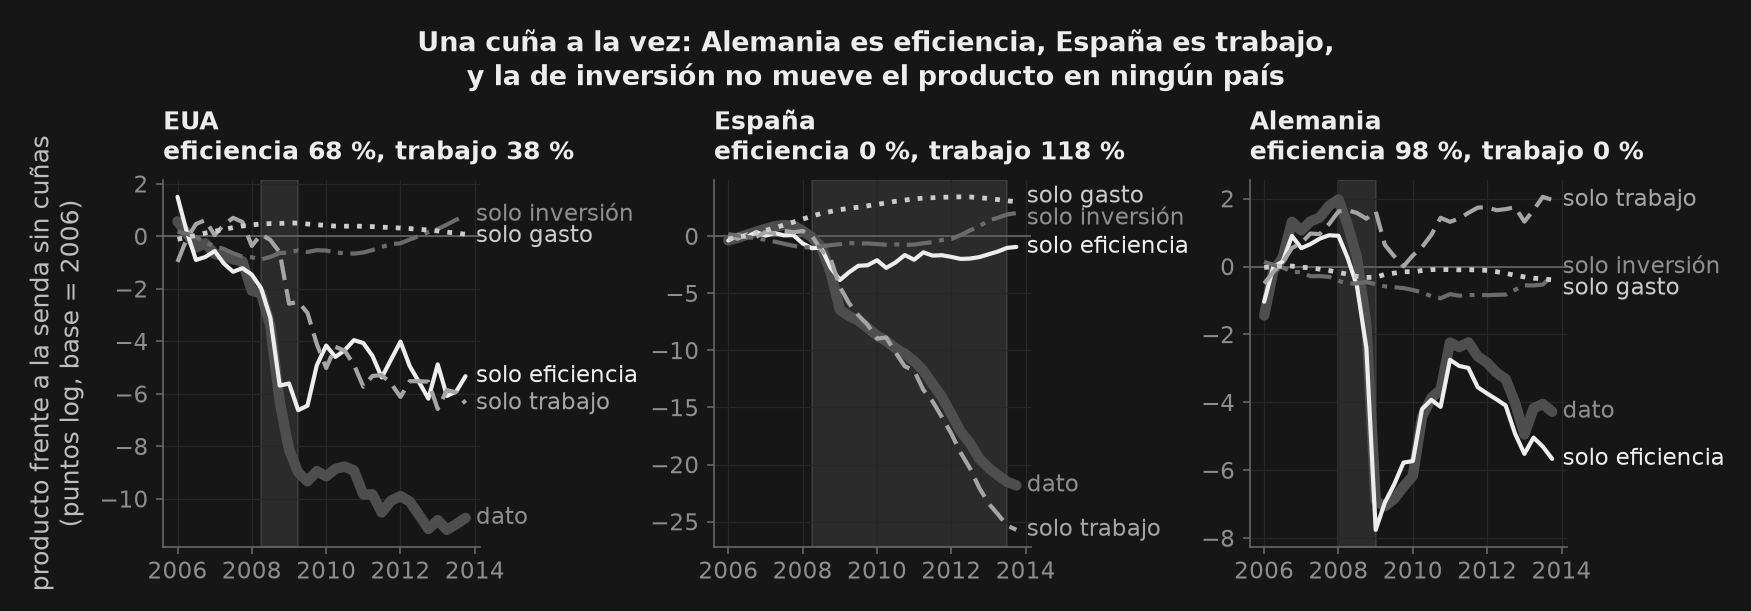

In [18]:
def _pct(x):
    return f"{0.0 if abs(x) < 0.5 else x:.0f}"      # evita el feo "−0 %"


ETQ = [("dato", "dato", dict(color=_nbstyle.tono(0.3), linestyle="-", linewidth=5.0)),
       ("A", "solo eficiencia", _nbstyle.S1), ("S", "solo trabajo", _nbstyle.S2),
       ("Dt", "solo inversión", _nbstyle.S3), ("G", "solo gasto", _nbstyle.S4)]
fig, axes = _nbstyle.figura(1, 3)
for ax, c in zip(axes, TRES):
    d, b, (i0, i1, ip, it) = PAQ[c]
    f = d["fechas"][i0:i1 + 1]
    ax.axvspan(d["fechas"][ip], d["fechas"][it], color=_nbstyle.RECESION, zorder=0)
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, zorder=1)
    for k, lab, sty in ETQ:
        s = SEND[(c, True, k)]
        ax.plot(f, s[i0:i1 + 1] - s[i0:i0 + 4].mean(), **sty, label=lab, zorder=3)
    ax.set_title(f"{NB[c]}\neficiencia {_pct(CUOTA[(c, True, 'A')])} %, "
                 f"trabajo {_pct(CUOTA[(c, True, 'S')])} %")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("producto frente a la senda sin cuñas\n(puntos log, base = 2006)")
# fuera=True también en los dos primeros paneles: dentro del eje el nombre se
# escribe a la izquierda del final de su línea y cae sobre las vecinas, que aquí
# convergen; fuera, cada uno queda junto al final de SU línea.
for ax in axes:
    _nbstyle.etiquetar(ax, donde="fin", fuera=True)
fig.suptitle("Una cuña a la vez: Alemania es eficiencia, España es trabajo,\ny la de "
             "inversión no mueve el producto en ningún país")
plt.show()


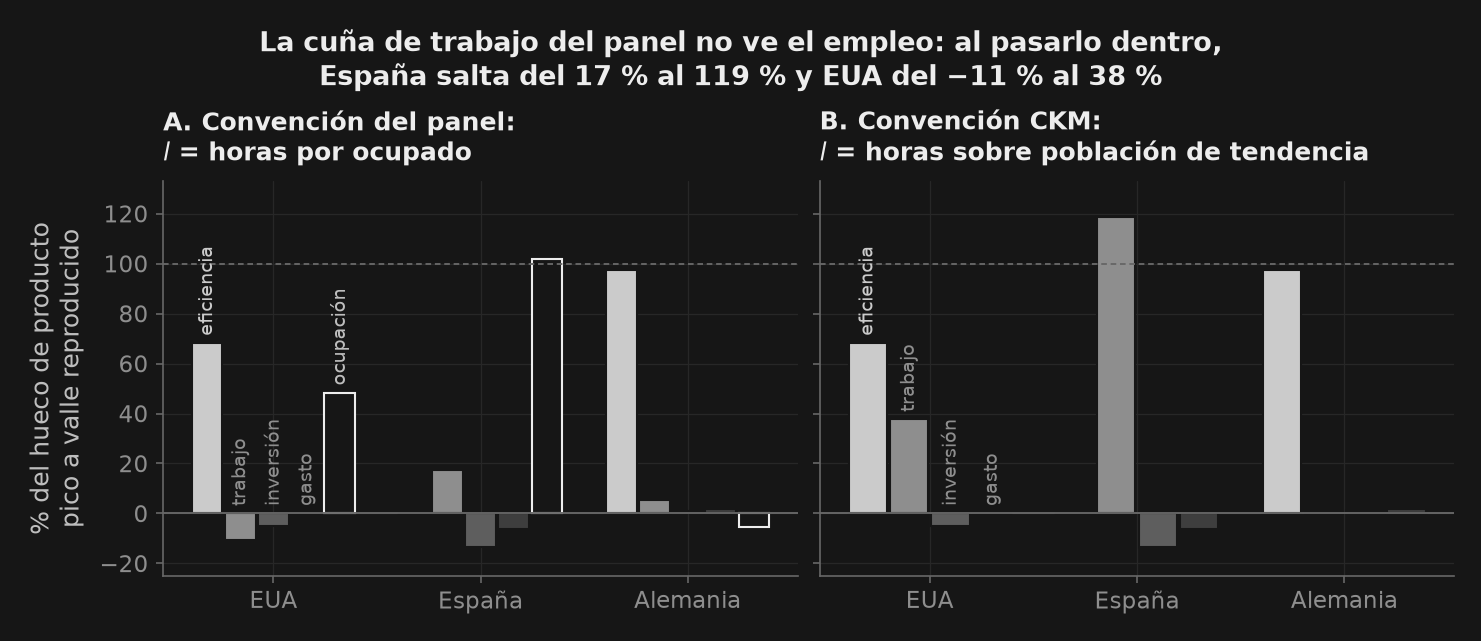

In [19]:
barc = [*_nbstyle.BARRA_COLORES, _nbstyle.FONDO]   # las cuatro cuñas como siempre; la ocupación hueca
# los dos tonos de barra más oscuros y la barra hueca no leerían como texto: sus nombres van en NOTA
ctxt = [*_nbstyle.BARRA_COLORES[:2], _nbstyle.NOTA, _nbstyle.NOTA, _nbstyle.TEXTO]
fig, axes = _nbstyle.figura(1, 2, sharey=True)
GRUPOS = (("A", "eficiencia"), ("S", "trabajo"), ("Dt", "inversión"), ("G", "gasto"),
          ("N", "ocupación"))
for ax, ckm, tit in ((axes[0], False, "A. Convención del panel:\n$l$ = horas por ocupado"),
                     (axes[1], True, "B. Convención CKM:\n$l$ = horas sobre población de tendencia")):
    kk = [g for g in GRUPOS if (ckm is False or g[0] != "N")]
    xs = np.arange(len(TRES)); anc = 0.8 / len(kk)
    for j, (k, lab) in enumerate(kk):
        xj = xs + (j - (len(kk) - 1) / 2) * anc
        ax.bar(xj, [CUOTA[(c, ckm, k)] for c in TRES], anc * 0.92, color=barc[j], lw=1.0,
               edgecolor=_nbstyle.TINTA if k == "N" else _nbstyle.FONDO)
        # el nombre de cada cuña encima de su propia barra del primer país
        ax.annotate(lab, (xj[0], max(CUOTA[(TRES[0], ckm, k)], 0.0) + 3.0), rotation=90,
                    ha="center", va="bottom", fontsize=9, color=ctxt[j])
    ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
    ax.axhline(100, color=_nbstyle.SPINE, lw=0.9, ls=(0, (3, 2)))
    ax.set_xticks(xs); ax.set_xticklabels([NB[c] for c in TRES]); ax.set_title(tit)
axes[0].set_ylabel("% del hueco de producto\npico a valle reproducido")
axes[0].set_ylim(-25, 133)
fig.suptitle("La cuña de trabajo del panel no ve el empleo: al pasarlo dentro,\nEspaña salta "
             "del 17 % al 119 % y EUA del −11 % al 38 %")
plt.show()


### 4.2 Cinco pruebas de que el reparto no lo decide el solucionador

El experimento tiene cinco grados de libertad que no vienen del experimento, y los cinco se prueban: la condición terminal sobre el capital, la ventana en la que se calibra la senda balanceada, el supuesto de expectativas, la serie de horas de Estados Unidos, y la tendencia de población con la que la convención CKM mide la jornada. Los dos primeros no cambian el orden; el tercero infla la volatilidad de una cuña que de todas formas no mueve nada; el cuarto sí da la vuelta al reparto estadounidense, y por eso está aquí y no en una nota al pie; el quinto deja el reparto donde estaba y **encoge el hueco español de 21.4 a 13.1 puntos**, que es justo la distinción entre lo que este experimento mide bien y lo que no.

In [20]:
def reparto(d, b, idx, ckm=True, n0=N0, Kmult=1.0):
    i0, i1, ip, it = idx
    dd, bb, cl = convencion(d, b, ckm, n0=n0)
    sin = corre(dd, bb, cl, set(), Kmult=Kmult)
    dY = 100 * np.log(d["Y"][it] / d["Y"][ip])
    d0 = 100 * np.log(sin["Y"][it] / sin["Y"][ip])
    out = {}
    for k in cl:
        r = corre(dd, bb, cl, {k}, x0=sin["x"], Kmult=Kmult)
        out[k] = (100 * (100 * np.log(r["Y"][it] / r["Y"][ip]) - d0) / (dY - d0), r["Y"])
    return dY - d0, out


print("(a) condición terminal: el capital de 2020T1 del panel, multiplicado por 0.95 y por 1.05")
_mov = 0.0
for c in TRES:
    d, b, idx = PAQ[c]
    base = reparto(d, b, idx)[1]
    for m in (0.95, 1.05):
        alt = reparto(d, b, idx, Kmult=m)[1]
        mv = max(abs(alt[k][0] - base[k][0]) for k in alt); _mov = max(_mov, mv)
        dv = max(np.max(np.abs(100 * np.log(alt[k][1][idx[0]:idx[1] + 1]
                                            / base[k][1][idx[0]:idx[1] + 1]))) for k in alt)
        print(f"    {c} x{m:.2f}: la cuota se mueve como mucho {mv:.1f} puntos porcentuales; "
              f"la senda, {dv:.2f} puntos log dentro de 2006–2013")
assert _mov < 5.0, _mov

print("(b) ventana de la senda balanceada: 2000–2006 (la del panel) frente a 2000–2019 completa")
for c in TRES:
    d, b, idx = PAQ[c]
    for nom, bb_ in (("2000–06", b), ("2000–19", bgp(d, n0=d["T"]))):
        h, o = reparto(d, bb_, idx)
        print(f"    {c} {nom}: hueco {h:+6.2f} | " +
              "  ".join(f"{NOM[k]} {o[k][0]:+6.1f}%" for k in o))

print("(c) expectativas: la cuña de inversión del panel frente a la internamente consistente")
for c in TRES:
    d = PAQ[c][0]
    al, be, T, Y, C, K = d["al"], d["be"], d["T"], d["Y"], d["C"], d["K"]
    tx = np.empty(T); tx[T - 1] = 1 / d["Dt"][T - 1] - 1
    for t in range(T - 2, -1, -1):        # Euler con sus dos fechas, hacia atrás
        tx[t] = be * (C[t] / C[t + 1]) * (al * Y[t + 1] / K[t + 1]
                                          + (1 - DELTA) * (1 + tx[t + 1])) - 1
    m = ~np.isnan(d["Dt"]); x_, y_ = np.log(d["Dt"][m]), np.log(1 / (1 + tx[m]))
    print(f"    {c}: sd = {100 * np.std(x_):5.1f} puntos log (panel, tau_x constante) frente a "
          f"{100 * np.std(y_):4.1f} (secuencia consistente); corr {np.corrcoef(x_, y_)[0, 1]:+.2f}")

print("(d) EUA no tiene horas en el panel (impone H = 480*E), pero la columna HOUR las trae")
_d = PAQ["USA"][0]; _idx = PAQ["USA"][2]
_hr = PAIS["USA"]["HOUR"].loc[INI:FIN].to_numpy()
_d2 = dict(_d)
_d2["H"] = _hr * np.mean(_d["H"][:N0]) / np.mean(_hr[:N0])          # misma escala en 2000–06
_d2["A"] = _d2["Y"] / (_d2["K"] ** _d2["al"] * _d2["H"] ** (1 - _d2["al"]))
_d2["l"] = (_d2["H"] / _d2["N"]) / 1152.0
for _nom, _dx in (("H = 480*E, el panel", _d), ("H = HOUR reescalada", _d2)):
    _h, _o = reparto(_dx, bgp(_dx), _idx)
    print(f"    EUA, {_nom:20s}: jornada "
          f"{100 * np.log((_dx['H'] / _dx['N'])[_idx[3]] / (_dx['H'] / _dx['N'])[_idx[2]]):+5.2f} "
          f"pts | hueco {_h:+6.2f} | " + "  ".join(f"{NOM[k]} {_o[k][0]:+6.1f}%" for k in _o))
assert 38 < reparto(_d2, bgp(_d2), _idx)[1]["A"][0] < 52, "el reparto de EUA con HOUR"

print("(e) la «población de tendencia» de la convención CKM es el empleo de 2000–06 "
      "extrapolado: en España, 3.47 %/año — un auge, no una demografía")
POB = {}
for c in TRES:
    d, b, idx = PAQ[c]
    g0 = 400 * np.log(b["N"][1] / b["N"][0])
    for etq, g in ([("panel", g0), ("1.0", 1.0), ("0.5", 0.5)] if c == "ESP"
                   else [("panel", g0), ("1.0", 1.0)]):
        b2 = dict(b); b2["N"] = b["N"][0] * np.exp((g / 400.0) * np.arange(d["T"]))
        h, o = reparto(d, b2, idx)
        POB[(c, etq)] = (h, {k: o[k][0] for k in o})
        print(f"    {c} tendencia {g:+5.2f} %/año{' (la del panel)' if etq == 'panel' else '':16s}: "
              f"hueco {h:+6.2f} | " + "  ".join(f"{NOM[k]} {o[k][0]:+6.1f}%" for k in o))
print(f"    El REPARTO aguanta —España sigue siendo trabajo, Alemania eficiencia, la inversión\n"
      f"    sigue sin mover nada—; el TAMAÑO del hueco no: el español pasa de "
      f"{POB[('ESP', 'panel')][0]:+.1f} a {POB[('ESP', '1.0')][0]:+.1f} puntos\n"
      f"    y la cuota de trabajo de {POB[('ESP', 'panel')][1]['S']:.1f} % a "
      f"{POB[('ESP', '1.0')][1]['S']:.1f} %. Las cuotas son cuotas de un hueco que la tendencia elige.")
assert POB[("ESP", "1.0")][1]["S"] > 100 and POB[("ESP", "0.5")][1]["S"] > 100
assert abs(POB[("ESP", "1.0")][0] + 13.1) < 0.3 and POB[("DEU", "1.0")][1]["A"] > 85
assert abs(POB[("ESP", "1.0")][1]["A"]) < 10 and POB[("USA", "1.0")][1]["A"] > 60

(a) condición terminal: el capital de 2020T1 del panel, multiplicado por 0.95 y por 1.05
    USA x0.95: la cuota se mueve como mucho 0.4 puntos porcentuales; la senda, 0.58 puntos log dentro de 2006–2013
    USA x1.05: la cuota se mueve como mucho 0.4 puntos porcentuales; la senda, 0.59 puntos log dentro de 2006–2013
    ESP x0.95: la cuota se mueve como mucho 3.7 puntos porcentuales; la senda, 1.07 puntos log dentro de 2006–2013
    ESP x1.05: la cuota se mueve como mucho 3.6 puntos porcentuales; la senda, 1.08 puntos log dentro de 2006–2013
    DEU x0.95: la cuota se mueve como mucho 1.0 puntos porcentuales; la senda, 1.25 puntos log dentro de 2006–2013
    DEU x1.05: la cuota se mueve como mucho 0.9 puntos porcentuales; la senda, 1.24 puntos log dentro de 2006–2013
(b) ventana de la senda balanceada: 2000–2006 (la del panel) frente a 2000–2019 completa
    USA 2000–06: hueco  -6.82 | eficiencia  +68.1%  trabajo  +37.7%  inversión   -5.1%  gasto   -0.5%
    USA 2000–19: hueco  -5.96 

    DEU tendencia -0.22 %/año (la del panel) : hueco  -8.88 | eficiencia  +97.6%  trabajo   -0.0%  inversión   +1.1%  gasto   +1.6%
    DEU tendencia +1.00 %/año                : hueco  -9.59 | eficiencia  +90.3%  trabajo   +7.4%  inversión   +1.4%  gasto   +1.6%
    El REPARTO aguanta —España sigue siendo trabajo, Alemania eficiencia, la inversión
    sigue sin mover nada—; el TAMAÑO del hueco no: el español pasa de -21.4 a -13.1 puntos
    y la cuota de trabajo de 118.5 % a 130.3 %. Las cuotas son cuotas de un hueco que la tendencia elige.


### 4.3 Qué compra el experimento, y qué no

**Las partes casi suman.** 100.2 % en EUA, 98.6 % en España, 100.3 % en Alemania. La lámina avisa de que la descomposición sólo es aditiva en la aproximación lineal, y es cierto — pero fuera de ella el error de aditividad en esta ventana es de 1.4 puntos **porcentuales sobre 100** en el caso peor —0.31 puntos logarítmicos de los 21.4 del hueco español—, no un orden de magnitud. Aun así se reporta la simulación con las cuatro juntas, porque es gratis y porque es la única garantizada.

**Un número sí depende de la ventana, y es español.** La senda balanceada se calibra en 2000–2006, y en ese periodo la eficiencia española **caía** al 0.62 % anual. Contra esa senda la cuña de eficiencia no explica nada ($-0.1$ %); contra una tendencia ajustada sobre toda la muestra 2000–2019 explica el 24.3 % y la de trabajo baja al 104.3 %. El orden no cambia —trabajo primero, inversión negativa— pero el número sí, y hay que decir cuál se usa. En EUA y Alemania la cuota de eficiencia se mueve entre las dos tendencias de 68.1 a 68.3 y de 97.6 a 91.9: ahí no hay pregunta. La condición terminal es inocua en los tres: multiplicar el capital de 2020T1 por 0.95 o por 1.05 mueve las cuotas 3.7 puntos porcentuales como mucho (España) y 0.4 en EUA.

**Lo que compra es poder de descarte.** Si la cuña de inversión no mueve el producto en EUA, ni en España, ni en Alemania —y no lo mueve aunque en Alemania caiga 5.7 puntos logarítmicos de pico a valle, 4.4 con el promedio de §2—, las fricciones financieras no pueden ser la historia principal de 2008–09 *en el sentido que el prototipo sabe leer*. Ese es el argumento de Chari, Kehoe y McGrattan, y aquí queda corrido —como en 04b, por la otra ruta— en vez de sólo citado.

**Y un reparto entero cuelga de una columna.** Estados Unidos es uno de los siete países sin horas del panel: se le impone $H_t=480\cdot E_t$, así que toda la caída de la jornada acaba dentro de $A_t$. El panel trae la serie `HOUR` de EUA con cobertura completa en 2000–2019 y no la usa. Con ella, la jornada cae 2.6 puntos logarítmicos de pico a valle, la caída medida de $A$ pasa de $-2.4$ a $-1.0$, y el reparto simulado se da la vuelta: eficiencia 44 %, trabajo 61 %. El orden entre EUA y Alemania se invierte con esa sola sustitución. No es un detalle de medición: es la diferencia entre acusar a la productividad y acusar al mercado de trabajo.

**Lo que no compra es un modelo.** La cuña de trabajo española al 119 % es compatible con la reforma laboral, con el desplome de la construcción, con el racionamiento del crédito, con la informalidad y con la clasificación de las horas: nombra una familia, no elige dentro de ella. Y la cuña de eficiencia alemana al 98 % lleva dentro el atesoramiento de trabajo del *Kurzarbeit*, porque el $A$ de este panel es el residuo de Solow crudo — sin utilización del capital y sin calidad del trabajo. Que una cuña se mueva no es que una fricción exista; es que el dato se aparta del modelo por ese margen.

## 5. Kehoe–Prescott, la cicatriz, y el coste de un *default*

Con el producto total, **ocho** economías de la OCDE cruzan el umbral del 20 % de Kehoe y Prescott (2002) en la década de 2010; con el producto **por ocupado**, cinco — y España desaparece, de $-20.8$ a $-8.6$, porque destruyó empleo y su producto por ocupado subió. Es el efecto de composición de T01_A §5 otra vez, ahora decidiendo quién entra en la lista de depresiones. Sólo tres países sobreviven a las cuatro versiones del filtro: **Grecia, Italia y Finlandia**. Y una de ellas es de otro orden: Grecia toca $-50.1$ puntos logarítmicos por debajo de la tendencia del 2 %, muy por delante de la segunda —Letonia, $-31.9$— y **no volvió**: sigue en $-50.1$ en 2019T4 y en $-50.6$ en 2025T2, dieciocho años después de su pico.

Pasado el filtro hay que repartir la caída, y ahí la sección tiene una sola lección: **el reparto no es un dato, es una elección de $\alpha$**. Con el $\alpha$ del panel —0.67 en Grecia— el factor de PTF de la caída griega es $-108$ y el de capital $+88$, para un producto que cae 33; con $\alpha = 1/3$ son $-42$ y $+22$. Los mismos datos, la misma identidad, dos historias; lo único que no se mueve son las horas, $-13$. En España el factor de PTF llega a cambiar de signo: $-3.3$ con el $\alpha$ del panel, $+6.9$ con $1/3$. Con la $\alpha$ común de KP el hallazgo de fondo sí aguanta: en 18 de los 19 países cuya brecha frente a la tendencia del 2 % es peor que $-5$ en 2019T4, el factor de PTF es más negativo que la suma del capital y las horas. La excepción es Portugal, y no por PTF: es una reversión de la profundización del capital.

La tercera parte pone ese aparato al lado de un número del propio profesor. El coste de productividad de un *default* soberano, 3.70–5.88 % de PTF, se replica aquí como la diferencia entre la periferia bajo tensión y el núcleo en 2009T1–2012T4: $-4.9$ puntos logarítmicos de $\log A$ medido con el $\alpha_c$ de cada país, limpiamente dentro del rango — y $-2.2$ midiendo el mismo residuo con $\alpha=1/3$, que se sale del rango por abajo. El coste de un *default* también es una elección de $\alpha$. Y la brecha se deshace en cuanto se quita Grecia: $-0.3$. Es un coste de **default** con $n = 1$, no un coste de prima de riesgo — los otros cuatro países estuvieron bajo tensión y no perdieron PTF. La cuña que sí separa periferia de núcleo es la de trabajo, $-12.4$ frente a $-4.4$, robusta al suavizado y a la ventana: la periferia se separa en el margen que el prototipo lee como **trabajo**, no en el que lee como fricción financiera. Y dentro de ese margen la brecha de $-8.0$ se parte en $-7.3$ de jornada por tres y $-0.7$ de $\log(C/Y)$: vive en las horas por ocupado. Qué las movió —programas fiscales, reforma laboral, composición del empleo— la cuña no lo decide; nombra una familia, no elige dentro de ella. La provocación llega al poner el rango junto a la distribución: el país mediano perdió $-4.8$ puntos de $\log A$ **medido con $\alpha=1/3$** de pico a valle **sin ningún default**, y 22 de 33 perdieron más de 3.70. El rango del artículo es del tamaño de una recesión ordinaria medida en PTF, y su extremo entero cabe 4.7 veces en lo que perdió Grecia.

La cuarta parte es la cicatriz, y su moraleja es metodológica: la respuesta depende del contrafactual, y hay que declararlo. Con la tendencia propia 2000–07 de cada país, la brecha del PIB en 2019 correlaciona $+0.88$ con la caída de $\log A$ de pico a valle, y $+0.65$ quitando los cuatro extremos. Con una tendencia común del 3.29 % es $+0.14$ o $+0.54$ **según dónde se ancle**. Y hay que imprimir al lado el número incómodo: la brecha correlaciona $+0.87$ con la caída del propio PIB, así que la cicatriz sigue al tamaño de la recesión casi tan de cerca como sigue a $A$. La persistencia honesta se mide sin ajustar tendencias: el 73 % de la caída de $\log A$ del país mediano seguía abierta dieciséis trimestres después del valle, mientras que un AR(1) con tendencia sobre la misma serie devuelve una vida media de 2.7 trimestres. No se contradicen: miden cosas distintas, y saber cuál mide cada una es lo que separa una cicatriz de una desviación alrededor de la senda posterior.

**Una nota sobre los datos, porque decide tres de los cuatro resultados.** Primero, la diferencia entre «ocho países» y «diez» que circula por esta literatura no está en los datos: está en el **ancla** de la tendencia. Anclada en la media de 2007 son ocho; anclada en el nivel de 2007T4, diez — entran Lituania y Eslovenia. Segundo, Kehoe y Prescott miden producto por persona en edad de trabajar y el panel no trae población: el producto total castiga a los que emigraron (Letonia, Lituania, Croacia) y el producto por ocupado premia a los que destruyeron empleo (España) o importaron trabajadores (Luxemburgo). No hay una versión neutral; hay dos, y aquí se calculan las dos. Tercero, $\alpha_c$ es uno menos una participación del trabajo **sin ajustar por cuenta propia**, así que el ingreso mixto griego se imputa a capital, y cualquier contabilidad con $1/(1-\alpha)$ hereda eso. Y cuarto, esta $\log A$ es un residuo de Solow crudo, sin utilización ni calidad del trabajo: compararla con el número de un modelo estructural es una provocación con número, no un contraste. Una advertencia de lectura para la tabla: el valle propio de Finlandia es 2009T2, así que su fila de pico a valle es la recesión de 2008–09 y **no** la década perdida finlandesa, que aparece en el bloque de 2019T4.

In [21]:
# (i) El filtro de Kehoe-Prescott: 2 p.l./año, dos anclas, dos denominadores.
G_YR = 2.0        # 2 puntos logarítmicos al año: la tendencia de Kehoe-Prescott
_corr = lambda a, b: float(np.corrcoef(a, b)[0, 1])          # noqa: E731


def desvio_kp(s, g=G_YR, ancla="media2007"):
    """Desvío de s (p.l.) frente a una tendencia de g puntos logarítmicos al año."""
    t = np.arange(len(s), dtype=float) / 4.0
    if ancla == "media2007":
        a = s.loc["2007-01-01":"2007-12-31"].mean() - g * t[s.index.year == 2007].mean()
    else:                                                    # ancla en el nivel de 2007T4
        i = s.index.get_loc(pd.Timestamp("2007-10-01"))
        a = s.iloc[i] - g * t[i]
    return s - (a + g * t)


KP, MIN10 = {}, {}
for var in ("Y", "Y/EMP"):
    for anc in ("media2007", "2007Q4"):
        D = pd.DataFrame({c: desvio_kp(PAIS[c]["y"] - (PAIS[c]["e"] if var == "Y/EMP" else 0.0),
                                       ancla=anc) for c in CODIGOS})
        KP[(var, anc)] = D
        m = MIN10[(var, anc)] = D.loc["2008-01-01":"2017-12-31"].min()
        print(f"[{var:5s} ancla {anc:9s}] >=20 %: {(m <= -20).sum():2d} | "
              f">=15 %: {(m <= -15).sum():2d} | <=-15 en 2019T4: "
              f"{(D.loc['2019-10-01'] <= -15).sum():2d} | en 2025T2: "
              f"{(D.loc['2025-04-01'] <= -15).sum():2d} || "
              + ", ".join(f"{c} {m[c]:.1f}" for c in m[m <= -20].sort_values().index))
mY, mYq, mYE, mYEq = (MIN10[k] for k in (("Y", "media2007"), ("Y", "2007Q4"),
                                         ("Y/EMP", "media2007"), ("Y/EMP", "2007Q4")))
ROB = sorted(set.intersection(*[set(m[m <= -20].index) for m in (mY, mYq, mYE, mYEq)]))
NUEVOS = sorted(set(mYq[mYq <= -20].index) - set(mY[mY <= -20].index))
D19, D25 = KP[("Y", "media2007")].loc["2019-10-01"], KP[("Y", "media2007")].loc["2025-04-01"]
c19, c25 = set(D19[D19 <= -15].index), set(D25[D25 <= -15].index)
print(f"\nEl ancla mueve el recuento de {(mY <= -20).sum()} a {(mYq <= -20).sum()}: entran "
      f"{', '.join(f'{c} {mYq[c]:.1f}' for c in NUEVOS)}. No son datos distintos: es la tendencia.")
print(f"Robustos a las dos anclas y a los dos denominadores: {ROB}.  España: Y {mY['ESP']:+.1f} "
      f"-> Y/EMP {mYE['ESP']:+.1f}; Luxemburgo al revés, {mY['LUX']:+.1f} -> {mYE['LUX']:+.1f}.")
print(f"Grecia: mínimo de la década {mY['GRC']:+.1f}; 2019T4 {D19['GRC']:+.1f}; "
      f"2025T2 {D25['GRC']:+.1f}. No volvió. Siguen >=15 % por debajo {len(c19)} países en "
      f"2019T4 y {len(c25)} en 2025T2\n  (entran {', '.join(sorted(c25 - c19))}; sale "
      f"{', '.join(sorted(c19 - c25))}): una década al 2 % es exigente para Europa entera.")
assert (mY <= -20).sum() == 8 and (mYq <= -20).sum() == 10 and (mYE <= -20).sum() == 5
assert ROB == ["FIN", "GRC", "ITA"] and len(c19) == 8 and len(c25) == 12
assert abs(mY["ESP"] + 20.8) < 0.15 and abs(mYE["ESP"] + 8.6) < 0.15
assert abs(mY["GRC"] + 50.1) < 0.15 and abs(D25["GRC"] + 50.6) < 0.15

[Y     ancla media2007] >=20 %:  8 | >=15 %: 13 | <=-15 en 2019T4:  8 | en 2025T2: 12 || GRC -50.1, LVA -31.9, EST -26.3, ITA -25.7, HRV -24.1, PRT -22.2, FIN -21.1, ESP -20.8
[Y     ancla 2007Q4   ] >=20 %: 10 | >=15 %: 14 | <=-15 en 2019T4:  8 | en 2025T2: 12 || GRC -48.9, LVA -31.3, EST -25.3, ITA -24.8, HRV -23.4, PRT -22.5, FIN -22.2, LTU -22.1, ESP -21.1, SVN -20.6
[Y/EMP ancla media2007] >=20 %:  5 | >=15 %: 18 | <=-15 en 2019T4: 19 | en 2025T2: 24 || GRC -42.7, LUX -29.9, ITA -25.4, FIN -21.0, AUT -20.9
[Y/EMP ancla 2007Q4   ] >=20 %:  4 | >=15 %: 17 | <=-15 en 2019T4: 18 | en 2025T2: 24 || GRC -40.8, LUX -28.1, ITA -23.9, FIN -20.8

El ancla mueve el recuento de 8 a 10: entran LTU -22.1, SVN -20.6. No son datos distintos: es la tendencia.
Robustos a las dos anclas y a los dos denominadores: ['FIN', 'GRC', 'ITA'].  España: Y -20.8 -> Y/EMP -8.6; Luxemburgo al revés, -9.7 -> -29.9.
Grecia: mínimo de la década -50.1; 2019T4 -50.1; 2025T2 -50.6. No volvió. Siguen >=15 % por debajo

In [22]:
# (ii) log Y = log A/(1-a) + [a/(1-a)] log(K/Y) + log H, con el alpha del panel y con el 1/3 de KP.
def contabilidad(c, t0, t1, a):
    f = PAIS[c]
    lA = f["y"] - a * f["k"] - (1 - a) * f["h"]
    tfp = (lA[t1] - lA[t0]) / (1 - a)
    ky = a / (1 - a) * (f["ky"][t1] - f["ky"][t0])
    hh, dy = f["h"][t1] - f["h"][t0], f["y"][t1] - f["y"][t0]
    assert abs(tfp + ky + hh - dy) < 1e-6                    # la identidad, al bit
    return {"país": c, "ventana": f"{t0.to_period('Q')}->{t1.to_period('Q')}", "a": a,
            "dlogY": dy, "PTF": tfp, "K/Y": ky, "H": hh}


TB = pd.DataFrame([contabilidad(c, *REC[c], a) for c in ("GRC", "ITA", "FIN", "ESP")
                   for a in (float(PAIS[c]["alpha"].iloc[0]), 1 / 3)])
print(TB.round(2).to_string(index=False))
g67, g33 = TB[TB["país"] == "GRC"].iloc[0], TB[TB["país"] == "GRC"].iloc[1]
e67, e33 = TB[TB["país"] == "ESP"].iloc[0], TB[TB["país"] == "ESP"].iloc[1]
print(f"\nGrecia, la misma caída de {g67.dlogY:+.1f} p.l. repartida dos veces: con "
      f"alpha_GRC = {g67.a:.2f}, PTF {g67.PTF:+.1f} y capital {g67['K/Y']:+.1f};\n  con "
      f"alpha = 1/3, PTF {g33.PTF:+.1f} y capital {g33['K/Y']:+.1f}. El factor PTF se "
      f"multiplica por {g67.PTF / g33.PTF:.1f} y las horas ({g33.H:+.1f}) no se mueven.\n"
      f"  España sobre {e67.dlogY:+.1f}: el factor PTF cambia de SIGNO, {e67.PTF:+.1f} con "
      f"alpha_ESP = {e67.a:.2f} y {e33.PTF:+.1f} con 1/3 (horas {e33.H:+.1f}).")
assert abs(g67.PTF + 107.8) < 0.2 and abs(g33.PTF + 41.6) < 0.2 and abs(g33.H + 13.0) < 0.15
assert e67.PTF < 0 < e33.PTF

GAP = []                          # brecha de 2019T4 frente al 2 % anclado en 2007T4, alpha = 1/3
for c in CODIGOS:
    f = PAIS[c].loc["2007-10-01":"2019-10-01"]
    a, t, ac = 1 / 3, (len(f) - 1) / 4.0, float(PAIS[c]["alpha"].iloc[0])
    lA = f["y"] - a * f["k"] - (1 - a) * f["h"]
    gap = (f["y"].iloc[-1] - f["y"].iloc[0]) - G_YR * t
    hh = f["h"].iloc[-1] - f["h"].iloc[0]
    tfp = (lA.iloc[-1] - lA.iloc[0]) / (1 - a) - G_YR * t
    ky = a / (1 - a) * (f["ky"].iloc[-1] - f["ky"].iloc[0])
    assert abs(gap - (tfp + ky + hh)) < 1e-6
    GAP.append({"code": c, "gap": gap, "PTF": tfp, "KY": ky, "H": hh,
                "uh": int(f["uh"].iloc[0]),
                "PTF_ac": (f["A"].iloc[-1] - f["A"].iloc[0]) / (1 - ac) - G_YR * t})
GAP = pd.DataFrame(GAP).set_index("code").sort_values("gap")
neg = GAP[GAP.gap < -5]
exc = list(neg.index[~(neg.PTF < neg.KY + neg.H)])
print("\nBrecha de 2019T4 frente a la tendencia del 2 % anclada en 2007T4 (alpha = 1/3), "
      "los ocho peores:")
print(GAP.drop(columns="uh").round(1).head(8).to_string())
print(f"País mediano: brecha {GAP.gap.median():+.1f} = PTF {GAP.PTF.median():+.1f} + "
      f"K/Y {GAP.KY.median():+.1f} + horas {GAP.H.median():+.1f} (medianas por separado; "
      f"suman {GAP.PTF.median() + GAP.KY.median() + GAP.H.median():+.1f}).")
print(f"En {int((neg.PTF < neg.KY + neg.H).sum())} de los {len(neg)} países con brecha < -5 el "
      f"factor PTF es más negativo que la suma de los otros dos.\n  La excepción es {exc[0]}: "
      f"{GAP.loc[exc[0], 'gap']:+.1f} = PTF {GAP.loc[exc[0], 'PTF']:+.1f} + "
      f"K/Y {GAP.loc[exc[0], 'KY']:+.1f} + H {GAP.loc[exc[0], 'H']:+.1f}: una reversión de la "
      f"profundización, no PTF. Con alpha_c\n  el factor PTF griego sería "
      f"{GAP.loc['GRC', 'PTF_ac']:+.1f} en vez de {GAP.loc['GRC', 'PTF']:+.1f}; y en los "
      f"{int((GAP.uh == 0).sum())} países sin horas el factor 'horas' es empleo (mediana\n  "
      f"{GAP[GAP.uh == 0].H.median():+.1f} frente a {GAP[GAP.uh == 1].H.median():+.1f}), pero la "
      f"mediana del factor PTF aguanta: {GAP[GAP.uh == 0].PTF.median():+.1f} / "
      f"{GAP[GAP.uh == 1].PTF.median():+.1f}.")
assert abs(GAP.gap.median() + 10.0) < 0.15 and abs(GAP.PTF.median() + 20.8) < 0.15
assert abs(GAP.KY.median() - 6.1) < 0.15 and abs(GAP.H.median() - 4.5) < 0.15
assert int((neg.PTF < neg.KY + neg.H).sum()) == 18 and len(neg) == 19 and exc == ["PRT"]

país        ventana    a  dlogY     PTF   K/Y      H
 GRC 2007Q2->2013Q1 0.67 -33.07 -107.82 87.72 -12.97
 GRC 2007Q2->2013Q1 0.33 -33.07  -41.65 21.55 -12.97
 ITA 2008Q1->2013Q2 0.63 -10.40  -22.14 23.34 -11.61
 ITA 2008Q1->2013Q2 0.33 -10.40   -5.74  6.95 -11.61
 FIN 2007Q4->2009Q2 0.53  -9.89  -22.74 17.61  -4.76
 FIN 2007Q4->2009Q2 0.33  -9.89  -12.81  7.68  -4.76
 ESP 2008Q2->2013Q3 0.52  -9.34   -3.33 18.67 -24.68
 ESP 2008Q2->2013Q3 0.33  -9.34    6.87  8.48 -24.68

Grecia, la misma caída de -33.1 p.l. repartida dos veces: con alpha_GRC = 0.67, PTF -107.8 y capital +87.7;
  con alpha = 1/3, PTF -41.6 y capital +21.5. El factor PTF se multiplica por 2.6 y las horas (-13.0) no se mueven.
  España sobre -9.3: el factor PTF cambia de SIGNO, -3.3 con alpha_ESP = 0.52 y +6.9 con 1/3 (horas -24.7).

Brecha de 2019T4 frente a la tendencia del 2 % anclada en 2007T4 (alpha = 1/3), los ocho peores:
       gap   PTF    KY     H  PTF_ac
code                                
GRC  -48.9 -50.0  

In [23]:
# (iii) el coste de un default, replicado; (iv) la cicatriz, con el contrafactual como variable.
PERIF, NUCLEO = ["GRC", "PRT", "IRL", "ESP", "ITA"], ["DEU", "FRA", "NLD", "AUT", "FIN", "BEL"]
RANGO = (-5.88, -3.70)                                       # el rango del artículo del profesor


def acumulado(col, w0, w1, ma=1):
    x = {c: (PAIS[c][col].rolling(ma, center=True, min_periods=2).mean() if ma > 1
             else PAIS[c][col]) for c in PERIF + NUCLEO}
    return pd.Series({c: s[pd.Timestamp(w1)] - s[pd.Timestamp(w0)] for c, s in x.items()})


R = [dict(cuña=lbl, ventana=f"{w0}-{w1}", MM=ma, periferia=a[PERIF].mean(),
          núcleo=a[NUCLEO].mean(), brecha=a[PERIF].mean() - a[NUCLEO].mean(),
          sin_GRC=a[[c for c in PERIF if c != "GRC"]].mean() - a[NUCLEO].mean())
     for col, lbl in (("A", "log A"), ("L", "log(1-tau_l)"))
     for (w0, w1), ma in ((("2009Q1", "2012Q4"), 1), (("2009Q1", "2012Q4"), 4),
                          (("2008Q1", "2014Q4"), 1))
     for a in [acumulado(col, w0, w1, ma)]]
print(pd.DataFrame(R).round(1).to_string(index=False))
aA, aL = acumulado("A", "2009Q1", "2012Q4"), acumulado("L", "2009Q1", "2012Q4")
brA = aA[PERIF].mean() - aA[NUCLEO].mean()
brA_sinG = aA[[c for c in PERIF if c != "GRC"]].mean() - aA[NUCLEO].mean()
dA13 = pd.Series({c: dif(c, "A13", *REC[c]) for c in CODIGOS})
print("\n2009T1-2012T4, log A por país: " + ", ".join(f"{c} {aA[c]:+.1f}" for c in PERIF + NUCLEO))
print(f"Brecha periferia − núcleo {brA:+.1f} p.l., dentro del rango del artículo "
      f"(3.70-5.88 % de PTF); sin Grecia {brA_sinG:+.1f}, y Grecia\n  sola {aA['GRC']:+.1f}: es "
      f"un coste de DEFAULT con n = 1. La cuña que sí separa periferia de núcleo es la de "
      f"trabajo, {aL[PERIF].mean():+.1f}\n  frente a {aL[NUCLEO].mean():+.1f}, robusta al "
      f"suavizado y a la ventana. La provocación: pérdida de log A (alpha = 1/3) de pico a "
      f"valle,\n  mediana {dA13.median():+.1f} p.l., IQR [{dA13.quantile(.25):+.1f}, "
      f"{dA13.quantile(.75):+.1f}]; {int((dA13 <= RANGO[1]).sum())} de {len(dA13)} por debajo de "
      f"-3.70 SIN ningún default. Grecia, la única que\n  reestructuró (PSI, 2012T1), pierde "
      f"{dA13['GRC']:+.1f}: entre {abs(dA13['GRC'] / RANGO[0]):.1f} y "
      f"{abs(dA13['GRC'] / RANGO[1]):.1f} veces el rango entero.")
aCY, aHPE = acumulado("cy", "2009Q1", "2012Q4"), acumulado("hpe", "2009Q1", "2012Q4")
brL = aL[PERIF].mean() - aL[NUCLEO].mean()
brCY = aCY[PERIF].mean() - aCY[NUCLEO].mean()
brH3 = 3 * (aHPE[PERIF].mean() - aHPE[NUCLEO].mean())
aA13 = acumulado("A13", "2009Q1", "2012Q4")
brA13 = aA13[PERIF].mean() - aA13[NUCLEO].mean()
print(f"\nLas dos cifras que hacen falta para no comparar peras con manzanas:\n"
      f"  (1) la brecha de la cuña de TRABAJO, {brL:+.1f}, se parte al bit en log(C/Y) {brCY:+.1f}\n"
      f"      y 3·log(H/E) {brH3:+.1f}: vive en la JORNADA, no en el consumo. Qué la produjo\n"
      f"      —programas fiscales, reforma laboral, composición— la cuña no lo dice.\n"
      f"  (2) la brecha de log A vale {brA:+.1f} con el alpha_c de cada país y {brA13:+.1f} con\n"
      f"      alpha = 1/3, que es el convenio de la distribución de arriba: con ese convenio se\n"
      f"      SALE del rango del artículo por abajo. El coste de default cambia con alpha.")
assert abs(brCY + brH3 - brL) < 1e-9
assert abs(brH3 + 7.3) < 0.15 and abs(brCY + 0.7) < 0.15 and abs(brA13 + 2.2) < 0.15
assert abs(brA + 4.9) < 0.15 and abs(brA_sinG + 0.3) < 0.15 and abs(aA["GRC"] + 21.1) < 0.15
assert abs(aL[PERIF].mean() + 12.4) < 0.15 and abs(aL[NUCLEO].mean() + 4.4) < 0.15
assert abs(dA13.median() + 4.8) < 0.15 and int((dA13 <= RANGO[1]).sum()) == 22
assert abs(dA13["GRC"] + 27.8) < 0.2


def brecha_2019(c, modo="propia", g=None):
    """Nivel de 2019 menos el contrafactual: tendencia propia, o común anclada en 2000-07
    o en 2007T4."""
    s = PAIS[c]["y"]; t = np.arange(len(s), dtype=float) / 4.0
    fit = s.loc["2000-01-01":"2007-12-31"]
    res = ols(fit.to_numpy(), add_constant(t[:len(fit)]), cov_type="HC1")
    b = [float(res.params[1]), float(res.params[0])]
    i07 = s.index.get_loc(pd.Timestamp("2007-10-01"))
    cf_ = (b[1] + b[0] * t if modo == "propia" else fit.mean() + g * (t - t[:len(fit)].mean())
           if modo == "media0007" else s.iloc[i07] + g * (t - t[i07]))
    return float((s - pd.Series(cf_, index=s.index)).loc["2019-01-01":"2019-12-31"].mean()), b[0]


SC = pd.DataFrame({c: {"gap": brecha_2019(c)[0], "g0007": brecha_2019(c)[1], "dY": DY[c],
                       "dA": dif(c, "A", *REC[c]), "dL": dif(c, "L", *REC[c])}
                   for c in CODIGOS}).T
gmed = SC.g0007.median()
for modo in ("media0007", "2007Q4"):
    SC[f"gap_{modo}"] = [brecha_2019(c, modo, gmed)[0] for c in CODIGOS]
U = SC.drop(index="IRL")                                     # la revisión de 2015 envenena a IRL
U4 = U.drop(index=["LVA", "EST", "LTU", "GRC"])
abierto, rho = {}, {}
for c in CODIGOS:
    s, (pk, tr) = PAIS[c]["A"], REC[c]
    i = s.index.get_loc(tr)
    if DY[c] < -3:
        abierto[c] = (s.iloc[min(i + 16, len(s) - 1)] - s[pk]) / (s[tr] - s[pk])
    z = s.loc["2009-04-01":"2019-12-31"].dropna().to_numpy()
    X = np.column_stack([np.ones(len(z) - 1), np.arange(len(z) - 1, dtype=float), z[:-1]])
    res = ols(z[1:], X, cov_type="HC1")
    rho[c] = float(res.params[2])
abierto, rho = pd.Series(abierto), pd.Series(rho)
vm = -np.log(2) / np.log(rho.median())
print(f"\nBrecha del PIB en 2019 frente a la tendencia propia 2000-07: mediana "
      f"{SC.gap.median():+.1f} p.l., por debajo en {(SC.gap < 0).sum()} de {len(SC)};\n  "
      f"crecimiento propio mediano {gmed:.2f} %/año. corr(brecha, dlogA) = "
      f"{_corr(U.dA, U.gap):+.2f} (n = {len(U)}, sin IRL); sin los cuatro extremos "
      f"{_corr(U4.dA, U4.gap):+.2f}\n  (n = {len(U4)}); con la cuña de trabajo "
      f"{_corr(U.dL, U.gap):+.2f}. Y el número incómodo: corr(brecha, dlogY) = "
      f"{_corr(U.dY, U.gap):+.2f}, o sea que la cicatriz\n  sigue al TAMAÑO de la recesión casi "
      f"tan de cerca como sigue a A. Con una tendencia COMÚN del {gmed:.2f} %/año todo\n  "
      f"depende del ANCLA: en la media 2000-07 {_corr(U.dA, U.gap_media0007):+.2f}; en el nivel "
      f"de 2007T4 {_corr(U.dA, U['gap_2007Q4']):+.2f}.")
print(f"Persistencia, dos medidas (dY < -3, n = {len(abierto)}): fracción de la caída de log A "
      f"todavía abierta 16 trimestres tras el\n  valle, mediana {abierto.median():.2f} "
      f"(IQR {abierto.quantile(.25):.2f}-{abierto.quantile(.75):.2f}; más de la mitad abierta "
      f"en {(abierto > 0.5).sum()} de {len(abierto)}); AR(1) con tendencia en 2009T2-2019T4, "
      f"rho\n  mediano {rho.median():.2f} -> vida media {vm:.1f} trimestres. No se contradicen: "
      f"la tendencia ajustada absorbe el escalón de nivel y el\n  AR(1) mide la persistencia de "
      f"las desviaciones ALREDEDOR de la senda posterior.")
assert abs(_corr(U.dA, U.gap) - 0.88) < 0.02 and abs(_corr(U4.dA, U4.gap) - 0.65) < 0.02
assert abs(_corr(U.dY, U.gap) - 0.87) < 0.02
assert abs(_corr(U.dA, U.gap_media0007) - 0.14) < 0.03
assert abs(_corr(U.dA, U["gap_2007Q4"]) - 0.54) < 0.03
assert abs(abierto.median() - 0.73) < 0.02 and abs(rho.median() - 0.77) < 0.02
assert abs(vm - 2.7) < 0.15

        cuña       ventana  MM  periferia  núcleo  brecha  sin_GRC
       log A 2009Q1-2012Q4   1       -2.9     2.1    -4.9     -0.3
       log A 2009Q1-2012Q4   4       -3.9     0.6    -4.4      0.7
       log A 2008Q1-2014Q4   1       -5.0    -2.4    -2.7      3.2
log(1-tau_l) 2009Q1-2012Q4   1      -12.4    -4.4    -8.0    -10.1
log(1-tau_l) 2009Q1-2012Q4   4      -13.0    -5.1    -8.0    -10.9
log(1-tau_l) 2008Q1-2014Q4   1      -16.1    -7.7    -8.4    -10.7

2009T1-2012T4, log A por país: GRC -21.1, PRT +6.0, IRL +1.8, ESP +0.6, ITA -1.6, DEU +8.8, FRA +1.2, NLD +1.6, AUT +1.5, FIN -0.8, BEL -0.1
Brecha periferia − núcleo -4.9 p.l., dentro del rango del artículo (3.70-5.88 % de PTF); sin Grecia -0.3, y Grecia
  sola -21.1: es un coste de DEFAULT con n = 1. La cuña que sí separa periferia de núcleo es la de trabajo, -12.4
  frente a -4.4, robusta al suavizado y a la ventana. La provocación: pérdida de log A (alpha = 1/3) de pico a valle,
  mediana -4.8 p.l., IQR [-8.1, -3.4]; 22 


Las dos cifras que hacen falta para no comparar peras con manzanas:
  (1) la brecha de la cuña de TRABAJO, -8.0, se parte al bit en log(C/Y) -0.7
      y 3·log(H/E) -7.3: vive en la JORNADA, no en el consumo. Qué la produjo
      —programas fiscales, reforma laboral, composición— la cuña no lo dice.
  (2) la brecha de log A vale -4.9 con el alpha_c de cada país y -2.2 con
      alpha = 1/3, que es el convenio de la distribución de arriba: con ese convenio se
      SALE del rango del artículo por abajo. El coste de default cambia con alpha.

Brecha del PIB en 2019 frente a la tendencia propia 2000-07: mediana -14.8 p.l., por debajo en 31 de 33;
  crecimiento propio mediano 3.29 %/año. corr(brecha, dlogA) = +0.88 (n = 32, sin IRL); sin los cuatro extremos +0.65
  (n = 28); con la cuña de trabajo +0.45. Y el número incómodo: corr(brecha, dlogY) = +0.87, o sea que la cicatriz
  sigue al TAMAÑO de la recesión casi tan de cerca como sigue a A. Con una tendencia COMÚN del 3.29 %/año todo
  d

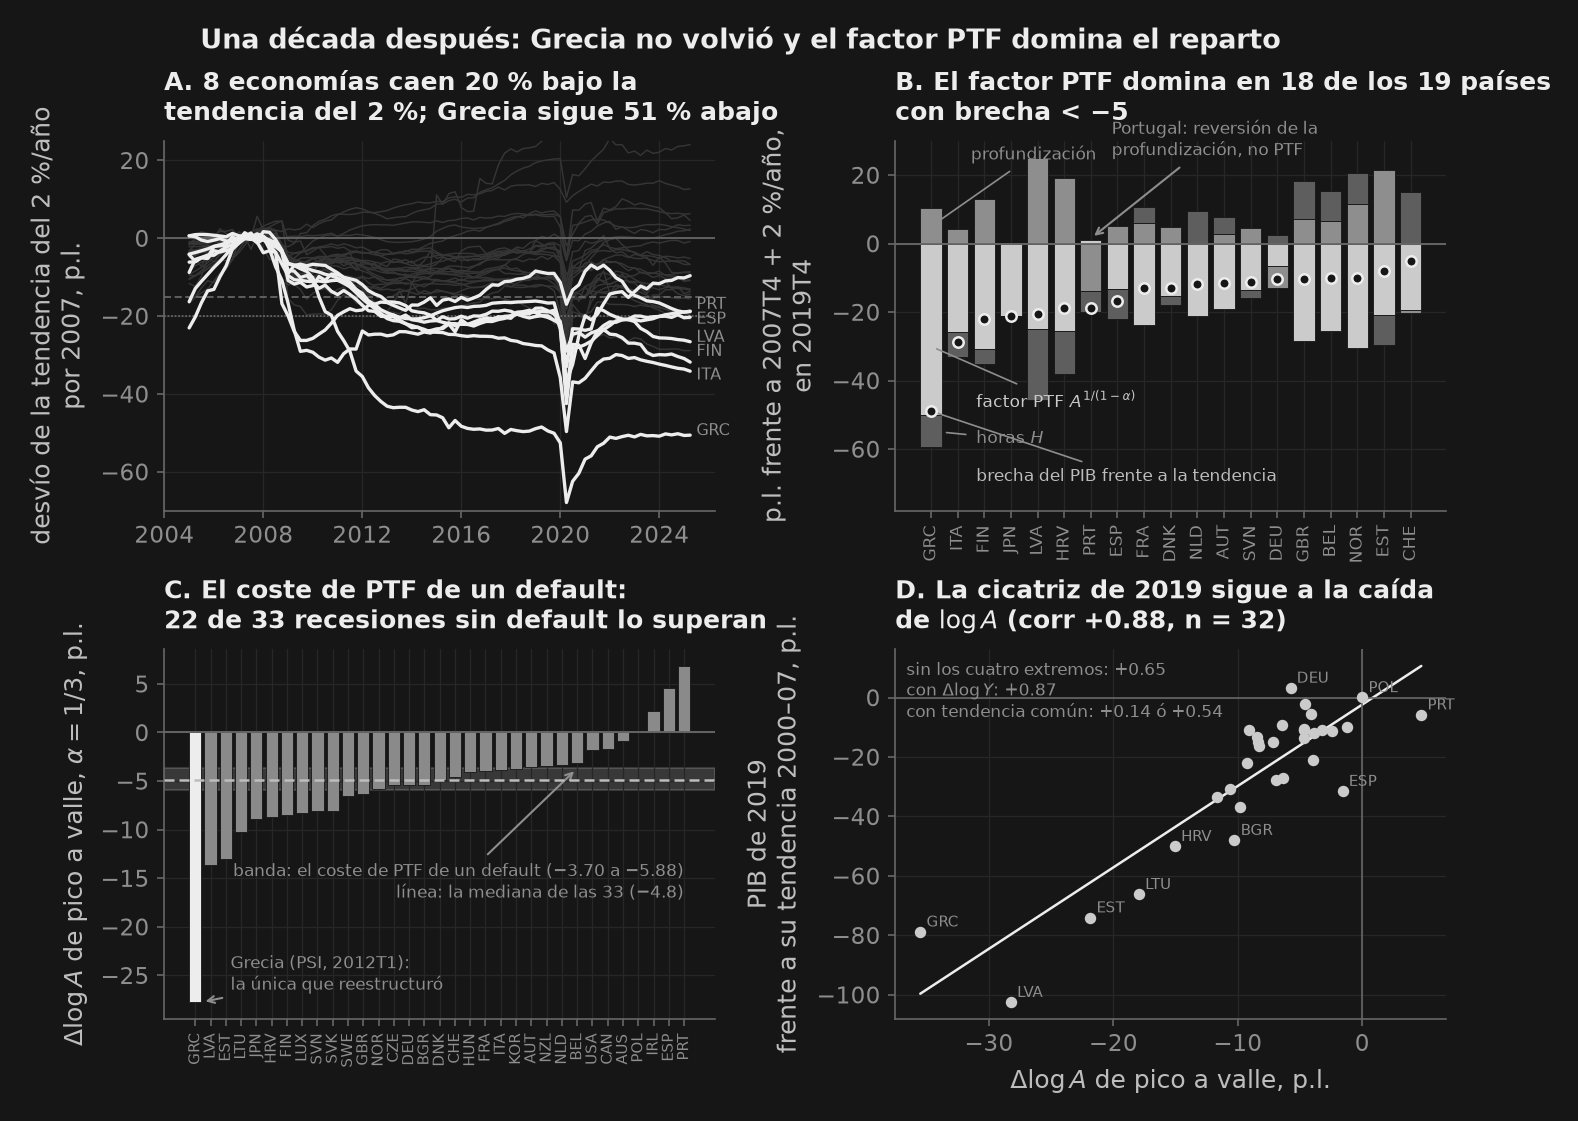

In [24]:
fig, ax = _nbstyle.figura(2, 2, figsize="2x2")
DV, club20 = KP[("Y", "media2007")].loc["2005-01-01":], list(mY[mY <= -20].index)
for c in CODIGOS:
    e = (cols[0], 1.6, 3) if c in club20 else (_nbstyle.gris("0.78"), 0.7, 1)
    ax[0, 0].plot(DV.index, DV[c], color=e[0], ls="-", lw=e[1], zorder=e[2])
for c, dy in (("GRC", 0), ("ITA", -4), ("FIN", 3), ("LVA", 0), ("PRT", 4), ("ESP", -6)):
    ax[0, 0].annotate(c, (DV.index[-1], DV[c].iloc[-1]), fontsize=7.6, color=_nbstyle.NOTA,
                      xytext=(3, dy), textcoords="offset points")
for lv, ls in ((0, "-"), (-15, (0, (4, 2))), (-20, (0, (1, 1)))):
    ax[0, 0].axhline(lv, color=_nbstyle.SPINE, lw=0.85, ls=ls)
ax[0, 0].set_ylim(-70, 25)
ax[0, 0].set_ylabel("desvío de la tendencia del 2 %/año\npor 2007, p.l.")
ax[0, 0].set_title(f"A. {(mY <= -20).sum()} economías caen 20 % bajo la\ntendencia del 2 %; "
                   f"Grecia sigue {abs(D25['GRC']):.0f} % abajo")

r_ = neg.sort_values("gap"); x = np.arange(len(r_)); bp = np.zeros(len(r_)); bn = np.zeros(len(r_))
FACTORES = (("PTF", "factor PTF $A^{1/(1-\\alpha)}$", _nbstyle.BARRA_COLORES[0]),
            ("KY", "profundización", _nbstyle.BARRA_COLORES[1]),
            ("H", "horas $H$", _nbstyle.BARRA_COLORES[2]))
for k, lbl, col in FACTORES:
    v = r_[k].to_numpy(); base = np.where(v >= 0, bp, bn)
    ax[0, 1].bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    bp, bn = bp + np.where(v >= 0, v, 0.0), bn + np.where(v < 0, v, 0.0)
ax[0, 1].plot(x, r_["gap"].to_numpy(), "o", ms=5, mfc=_nbstyle.FONDO,
              mec=_nbstyle.TINTA, mew=1.2, ls="none", zorder=5)
ax[0, 1].axhline(0, color=_nbstyle.SPINE, lw=0.9); ax[0, 1].set_ylim(-78, 30)
ax[0, 1].set_xticks(x); ax[0, 1].set_xticklabels(r_.index, rotation=90, fontsize=8)
ax[0, 1].set_ylabel("p.l. frente a 2007T4 + 2 %/año,\nen 2019T4")
# Cada factor junto a un tramo suyo de Grecia, la primera barra: en 19 barras apiladas
# no cabe repetir el nombre país por país.  Los dos tonos oscuros se nombran en NOTA.
for lbl, col, xy_txt, xy_pt in (
        (FACTORES[0][1], FACTORES[0][2], (1.7, -46.0), (0.0, -30.0)),
        (FACTORES[1][1], _nbstyle.NOTA, (1.5, 26.0), (0.0, 5.0)),
        (FACTORES[2][1], _nbstyle.NOTA, (1.7, -57.0), (0.35, -55.0)),
        ("brecha del PIB frente a la tendencia", _nbstyle.TEXTO, (1.7, -68.0),
         (0.0, float(r_["gap"].iloc[0])))):
    ax[0, 1].annotate(lbl, xy=xy_pt, xytext=xy_txt, ha="left", va="center", fontsize=8.4,
                      color=col, arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8,
                                                 shrinkA=3, shrinkB=3))
ax[0, 1].annotate("Portugal: reversión de la\nprofundización, no PTF",
                  xy=(int(np.where(r_.index == "PRT")[0][0]), 1.5), xytext=(10, 40),
                  textcoords="offset points", fontsize=8, color=_nbstyle.NOTA,
                  arrowprops=dict(arrowstyle="->", color=_nbstyle.NOTA, lw=1.0))
ax[0, 1].set_title(f"B. El factor PTF domina en {int((neg.PTF < neg.KY + neg.H).sum())} de los "
                   f"{len(neg)} países\ncon brecha < −5")

s_ = dA13.sort_values(); x = np.arange(len(s_))
ax[1, 0].bar(x, s_.to_numpy(), color=cols[3], edgecolor=_nbstyle.FONDO, lw=0.4)
ax[1, 0].bar(x[s_.index == "GRC"], s_[s_.index == "GRC"].to_numpy(), color=cols[0],
             edgecolor=_nbstyle.FONDO, lw=0.4)
ax[1, 0].axhspan(RANGO[0], RANGO[1], color=_nbstyle.BANDA, zorder=0)
ax[1, 0].axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax[1, 0].axhline(dA13.median(), color=_nbstyle.TEXTO, lw=1.2, ls=(0, (4, 2)), zorder=4)
ax[1, 0].set_xticks(x); ax[1, 0].set_xticklabels(s_.index, rotation=90, fontsize=7.4)
ax[1, 0].set_ylabel("$\\Delta\\log A$ de pico a valle, $\\alpha = 1/3$, p.l.")
FL = dict(fontsize=8.2, color=_nbstyle.NOTA, arrowprops=dict(arrowstyle="->", color=_nbstyle.NOTA, lw=1.0))
ax[1, 0].annotate(f"banda: el coste de PTF de un default (−3.70 a −5.88)\nlínea: la mediana de las "
                  f"{len(dA13)} ({dA13.median():.1f})".replace("-", "−"),
                  xy=(len(s_) - 8, RANGO[1]), xytext=(len(s_) - 1, -17), ha="right", **FL)
ax[1, 0].annotate("Grecia (PSI, 2012T1):\nla única que reestructuró", xy=(0.4, dA13["GRC"]),
                  xytext=(14, 6), textcoords="offset points", **FL)
ax[1, 0].set_title(f"C. El coste de PTF de un default:\n{int((dA13 <= RANGO[1]).sum())} de "
                   f"{len(dA13)} recesiones sin default lo superan")

ax[1, 1].scatter(U.dA, U.gap, s=20, color=cols[1], zorder=3)
# sólo los países separados del racimo central: con los 32 las etiquetas se pisan
for c in ("GRC", "LVA", "EST", "LTU", "HRV", "BGR", "ESP", "PRT", "POL", "DEU"):
    ax[1, 1].annotate(c, (U.loc[c, "dA"], U.loc[c, "gap"]), fontsize=7.4, color=_nbstyle.NOTA,
                      xytext=(3, 2.5), textcoords="offset points")
res_bb = ols(U.gap.to_numpy(), add_constant(U.dA.to_numpy()), cov_type="HC1")
bb = [float(res_bb.params[1]), float(res_bb.params[0])]
xx = np.linspace(U.dA.min(), U.dA.max(), 10)
ax[1, 1].plot(xx, bb[1] + bb[0] * xx, color=cols[0], lw=1.2, zorder=2)
ax[1, 1].axhline(0, color=_nbstyle.SPINE, lw=0.8); ax[1, 1].axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax[1, 1].set_xlabel("$\\Delta\\log A$ de pico a valle, p.l.")
ax[1, 1].set_ylabel("PIB de 2019\nfrente a su tendencia 2000–07, p.l.")
ax[1, 1].text(0.02, 0.97, f"sin los cuatro extremos: {_corr(U4.dA, U4.gap):+.2f}\ncon "
              f"$\\Delta\\log Y$: {_corr(U.dY, U.gap):+.2f}\ncon tendencia común: "
              f"{_corr(U.dA, U.gap_media0007):+.2f} ó {_corr(U.dA, U['gap_2007Q4']):+.2f}",
              transform=ax[1, 1].transAxes, fontsize=8.2, color=_nbstyle.NOTA, va="top")
ax[1, 1].set_title(f"D. La cicatriz de 2019 sigue a la caída\nde $\\log A$ (corr "
                   f"{_corr(U.dA, U.gap):+.2f}, n = {len(U)})")
fig.suptitle("Una década después: Grecia no volvió y el factor PTF domina el reparto")
plt.show()


## 6. México, y por qué no está en el panel

El pie de la figura del mazo A4 lo declara en voz alta: México no está en el panel de 33 economías, y por eso la Gran Recesión se compara con España y no con el país del que trata la mitad de este curso. Esta sección averigua qué haría falta para arreglarlo, y la respuesta es más interesante que un «no».

De las cuatro cuñas, México puede tener **una limpia** —la de trabajo, exacta y sin barra de error—, **una con barra** —la de eficiencia, cuyo *ciclo* sobrevive a todo lo que no sabemos y cuya *tendencia* no—, y ninguna de las otras dos. La de inversión, porque el acervo de capital que no existe entra en ella dos veces. La de gasto, por una razón que no tiene nada que ver con el capital y que no habríamos encontrado sin mirar.

Lo que **no** falta es casi todo. Producto, consumo, inversión y gasto público trimestrales desde 1995T1 en `qna_gasto.csv`; horas y ocupados desde 2005T1 en `qna_mercado_laboral.csv`, con `hours_factor` = 1.0, es decir sobre la base temporal correcta y sin la reparación que necesitaron Chile y Costa Rica en T01_B §5.1. México no está fuera del panel por falta de datos de gasto ni de trabajo.

**Una nota sobre los datos, porque aquí los datos deciden las cuatro respuestas.** Tres cosas, y cada una mata una cuña distinta.

La primera es el **capital**. Nadie publica un acervo trimestral homogéneo, así que el panel lo construye por inventario permanente, $K_{t+1}=(1-\delta)K_t+I_t$ con $\delta=0.015$, y hay que elegir un $K_0$. El error de esa elección se muere con vida media $\ln(1/2)/\ln(1-\delta)$ = **46 trimestres**: once años y medio. Con cien trimestres de inversión mexicana por delante, en 2019T4 todavía sobrevive el 22 % del error inicial.

La segunda es **$\alpha$**. La participación del trabajo cruda de México —remuneración de asalariados sobre PIB del enfoque de la renta— es de 26.4 %, que da $\alpha=0.736$, **por encima del máximo del panel entero** (Grecia, 0.671). El ajuste de Gollin de T01_B §3.2, imputar el salario medio al 33 % que trabaja por cuenta propia, la lleva a 0.610, ya dentro del rango. Y `comp_emp` empieza en 2008T1: la ventana 2000–2006 con la que el panel calibra $\alpha$, $\beta$ y $\psi$ país por país **no existe para México**.

La tercera se descubre midiendo. México encadena sus volúmenes **trimestre a trimestre** (`price_base = 'Q'`) y no año a año como 43 de los 49 países del archivo, y la no aditividad que eso produce es de otro orden de magnitud.

Regla que no se rompe en toda la sección: el panel no trae a México, así que **aquí no se cita ninguna cuña mexicana del panel**. Todo lo de abajo se construye desde `qna_*.csv` y se valida contra países que sí están en él.

In [25]:
# --- El inventario: lo que el prototipo pide, y lo que México tiene ---------
gas, lab, ren = gasto(), mercado_laboral(), renta()
mxl, mxr = lab.loc["MEX"], ren.loc["MEX"]


def piezas(code):
    """Las piezas del prototipo, en la convención exacta del panel."""
    Yc = volumen("gdp", code).dropna()
    Cc = (volumen("cons_hh", code) + volumen("cons_gov", code)
          - volumen("cons_dur", code)).dropna()                          # RCON − RDC
    Ic = (volumen("capform", code) + volumen("cons_dur", code)).dropna()  # RGCF + RDC
    L = lab.loc[code]
    return Yc, Cc, Ic, L["emp"].dropna(), L["hours"].dropna()


mxY, mxC, mxI, mxE, mxH = piezas("MEX")
mxG = (mxY - mxC - mxI).dropna()
LS = (mxr["comp_emp"] / mxr["gdp_income"]).dropna()
GOL = (LS * (mxl["emp"] / mxl["emp_employees"])).dropna()             # Gollin, T01_B §3.2
AC = CUNAS.groupby("code")["alpha_c"].first()

print("Lo que el prototipo necesita de cada país, y lo que data_curso/ tiene de México:\n")
print(f"{'insumo':<27}{'de dónde sale':<32}{'desde':>8}{'hasta':>8}{'n':>5}")
for nom, src, s in [("Y   producto", "qna_gasto  gdp/gdp_defl", mxY),
                    ("C   consumo no duradero", "cons_hh+cons_gov−cons_dur", mxC),
                    ("I   inversión + duraderos", "capform+cons_dur", mxI),
                    ("g   cuña de gasto", "residuo  Y−C−I", mxG),
                    ("E   ocupados", "qna_mercado_laboral  emp", mxE),
                    ("H   horas trabajadas", "qna_mercado_laboral  hours", mxH),
                    ("1−α participación trabajo", "qna_renta  comp_emp/gdp_income", LS),
                    ("K   acervo de capital", "no existe trimestral", None)]:
    a, b, n = (("—", "—", 0) if s is None else
               (str(s.index.min().to_period("Q")), str(s.index.max().to_period("Q")), len(s)))
    print(f"{nom:<27}{src:<32}{a:>8}{b:>8}{n:>5}")

print(f"\nEl panel tiene {len(CODIGOS)} economías y México no es una "
      f"(MEX en el panel: {'MEX' in set(CUNAS['code'])}). Faltan dos cosas, no una:")
print("  · K trimestral: ninguna fuente del curso lo publica.")
print(f"  · α: comp_emp de México empieza en {LS.index.min().to_period('Q')}, así que la ventana "
      f"2000–2006 con la que el panel\n    calibra α, β y ψ país por país no existe para México. "
      f"Y el número que sale es raro: α cruda\n    1−{LS.mean():.3f} = {1 - LS.mean():.3f}; "
      f"Gollin (imputar el salario medio al {mxl['self_emp_share'].mean():.0f}% de cuenta "
      f"propia) 1−{GOL.mean():.3f} = {1 - GOL.mean():.3f};\n    el panel va de {AC.min():.3f} "
      f"({AC.idxmin()}) a {AC.max():.3f} ({AC.idxmax()}), mediana {AC.median():.3f}.")
print(f"  · H y E existen desde {mxH.index.min().to_period('Q')}, con hours_factor = "
      f"{float(mxl['hours_factor'].dropna().iloc[0]):.1f} y {mxl['hours_week'].mean():.1f} "
      f"h/semana: el Tequila de 1995 se\n    queda sin insumo de trabajo, y con él la mitad de "
      f"las cuñas.")

mxly = 100 * np.log(mxY)
PICO = mxly.loc["2007":"2008-12-31"].idxmax()
VALLE = mxly.loc[PICO:"2013-12-31"].idxmin()
dY_mx = float(mxly[VALLE] - mxly[PICO])
dH_mx = float(100 * np.log(mxH[VALLE] / mxH[PICO]))
dE_mx = float(100 * np.log(mxE[VALLE] / mxE[PICO]))
print(f"\nRecesión mexicana, con el fechado único del cuaderno sobre el PIB del curso: "
      f"{PICO.to_period('Q')} → {VALLE.to_period('Q')}, {dY_mx:+.1f} puntos logarítmicos.")
print(f"  Los tres márgenes de T01_A §5: Y/H {dY_mx - dH_mx:+.1f}, H/E {dH_mx - dE_mx:+.1f}, "
      f"empleo {dE_mx:+.1f}.")
assert len(mxY) == 125 and len(mxH) == 85 and len(LS) == 71
assert "MEX" not in set(CUNAS["code"])
assert abs(dY_mx + 9.7) < 0.15 and abs(dE_mx) < 0.5
assert 1 - LS.mean() > AC.max() and AC.min() < 1 - GOL.mean() < AC.max()

Lo que el prototipo necesita de cada país, y lo que data_curso/ tiene de México:

insumo                     de dónde sale                      desde   hasta    n
Y   producto               qna_gasto  gdp/gdp_defl           1995Q1  2026Q1  125
C   consumo no duradero    cons_hh+cons_gov−cons_dur         1995Q1  2026Q1  125
I   inversión + duraderos  capform+cons_dur                  1995Q1  2026Q1  125
g   cuña de gasto          residuo  Y−C−I                    1995Q1  2026Q1  125
E   ocupados               qna_mercado_laboral  emp          2005Q1  2026Q1   85
H   horas trabajadas       qna_mercado_laboral  hours        2005Q1  2026Q1   85
1−α participación trabajo  qna_renta  comp_emp/gdp_income    2008Q1  2025Q3   71
K   acervo de capital      no existe trimestral                   —       —    0

El panel tiene 33 economías y México no es una (MEX en el panel: False). Faltan dos cosas, no una:
  · K trimestral: ninguna fuente del curso lo publica.
  · α: comp_emp de México empieza 

### 6.1 El capital: seis reglas defendibles, seis economías distintas

La construcción es la del panel, verificada al bit en §1: $K_{t+1}=(1-\delta)K_t+I_t$, con $A=Y/(K_t^{\alpha}H^{1-\alpha})$ y el capital **contemporáneo**. Lo único que hay que inventar es $K_0$, y hay dos maneras honestas de hacerlo. La de la senda balanceada, $K_0=I_1/(g+\delta)$, no usa ninguna información externa. La otra ancla el $K/Y$ inicial en la Penn World Table, que sí tiene un acervo mexicano —anual, `RKNANPMXA666NRUG`, de la PWT 10.01— y por tanto sabe algo que las cuentas trimestrales no.

Las dos discrepan en 24 %, y ese desacuerdo es el objeto de la sección. Como control de que el tubo entero funciona, se le pasa por encima a los catorce países del panel que tienen las mismas piezas en `qna_gasto` y se compara con su `logA` publicado.

In [26]:
# --- 6.1 Construir K, y medir cuánto duele no conocerlo ----------------------
KYp = (pd.read_csv(DATOS / "RKNANPMXA666NRUG.csv", parse_dates=["observation_date"])
       .set_index("observation_date").iloc[:, 0]
       / pd.read_csv(DATOS / "RGDPNAMXA666NRUG.csv", parse_dates=["observation_date"])
       .set_index("observation_date").iloc[:, 0])
KYp.index = KYp.index.year
KY_PWT = 4.0 * KYp[1995]          # la PWT es anual; el panel razona en PIB trimestral


def acumular(inv, K0, d):
    """K_{t+1} = (1−d)·K_t + I_t — la ley de movimiento del panel, verificada al bit en §1."""
    k = np.empty(len(inv)); k[0] = K0; v = inv.to_numpy()
    for t in range(1, len(inv)):
        k[t] = (1.0 - d) * k[t - 1] + v[t - 1]
    return pd.Series(k, index=inv.index)


def tasa(Yc):
    """Crecimiento trimestral medio hasta 2019T4: el g de la senda balanceada."""
    return float(np.exp(np.log(Yc.loc[:HASTA].iloc[-1] / Yc.iloc[0])
                        / (len(Yc.loc[:HASTA]) - 1)) - 1)


def solow(Yc, K, Hc, al):
    """100·log A = 100·[log Y − α log K_t − (1−α) log H], el K CONTEMPORÁNEO del panel."""
    ix = Hc.index.intersection(K.index)
    return (100 * (np.log(Yc[ix]) - al * np.log(K[ix]) - (1 - al) * np.log(Hc[ix]))).dropna()


gq = tasa(mxY)
kyp = (CUNAS.loc[CUNAS["date"] == pd.Timestamp("2019-10-01")]
       .assign(ky=lambda d: d["K"] / d["Y"]).set_index("code")["ky"])
print(f"El PIB mexicano creció {100 * gq:.3f}% por trimestre en 1995T1–2019T4. La regla de la "
      f"senda balanceada,\nK0 = I_1/(g+δ), da K0/Y0 = "
      f"{float(mxI.iloc[0] / (gq + DELTA) / mxY.iloc[0]):.1f}; el ancla externa de la PWT dice "
      f"{KY_PWT:.1f}. La regla se equivoca\nen "
      f"{100 * float(mxI.iloc[0] / (gq + DELTA) / mxY.iloc[0]) / KY_PWT - 100:+.0f}%, y ese error "
      f"se va con vida media ln(1/2)/ln(1−δ) = "
      f"{np.log(0.5) / np.log(1 - DELTA):.0f} trimestres:\nen 2019T4, cien trimestres después, "
      f"todavía sobrevive (1−δ)^100 = {(1 - DELTA) ** 100:.2f} de él.")
print(f"K/Y de la PWT para México: {KYp[1995]:.2f} → {KYp[2019]:.2f} anual = "
      f"{4 * KYp[1995]:.1f} → {4 * KYp[2019]:.1f} trimestral.\nK/Y del panel en 2019T4: mediana "
      f"{kyp.median():.1f}, intercuartil {kyp.quantile(.25):.1f}–{kyp.quantile(.75):.1f}, "
      f"rango {kyp.min():.1f} ({kyp.idxmin()}) a {kyp.max():.1f} ({kyp.idxmax()}).")

iy = (mxI.resample("YE").sum() / mxY.resample("YE").sum()); iy.index = iy.index.year
gr_a = mxY.resample("YE").sum().pct_change(); gr_a.index = gr_a.index.year
da = pd.Series({a: 1 - (KYp[a] * (1 + gr_a[a]) - iy[a]) / KYp[a - 1] for a in range(1996, 2020)})
print(f"δ anual que reconcilia el K de la PWT con la inversión de las cuentas, 1996–2019: "
      f"mediana {da.median():.3f}\n= {1 - (1 - da.median()) ** 0.25:.4f} trimestral, contra el "
      f"{DELTA} del panel ({1 - (1 - DELTA) ** 4:.3f} anual). El δ del panel le sirve a México; "
      f"el K0, no.")

# El mismo tubo, sobre los países del panel que sí tienen con qué compararse.
val = []
for code in ["ESP", "DEU", "ITA", "FRA", "PRT", "CZE", "HUN", "SVK", "BEL",
             "NLD", "AUT", "FIN", "SWE", "DNK"]:
    Yc, Cc, Ic, Ec, Hc = piezas(code)
    p, lyc = PAIS[code], 100 * np.log(Yc)
    pk = lyc.loc["2007":"2008-12-31"].idxmax(); tv = lyc.loc[pk:"2013-12-31"].idxmin()
    Kc = acumular(Ic, Ic.iloc[0] / (tasa(Yc) + DELTA), DELTA)
    lAc = solow(Yc, Kc, Hc, float(p["alpha"].iloc[0]))
    val.append({"code": code, "err": float(lAc[tv] - lAc[pk]) - float(p["A"][tv] - p["A"][pk]),
                "rec": float(lAc[tv] - lAc[pk]), "pan": float(p["A"][tv] - p["A"][pk]),
                "dky": float(Kc.loc["2019-10-01"] / Yc.loc["2019-10-01"]
                             - p["K"].loc["2019-10-01"] / np.exp(p["y"].loc["2019-10-01"] / 100))})
V = pd.DataFrame(val).set_index("code")
sp = V.drop(index="PRT")
print(f"\nControl: el mismo tubo sobre los {len(V)} países del panel con estas mismas piezas en "
      f"qna_gasto.\n  Error mediano en la ΔlogA de pico a valle {V.err.abs().median():.2f} pp "
      f"(sin PRT {sp.err.abs().median():.2f}, máximo {sp.err.abs().max():.2f} en "
      f"{sp.err.abs().idxmax()}); corr {V.rec.corr(V.pan):+.3f};\n  error mediano del K/Y de "
      f"2019T4 {V.dky.median():+.2f}. El único fallo grande es PRT ({V.err['PRT']:+.1f} pp): el "
      f"panel le da un K0 que\n  implica un K/Y inicial tres veces la mediana.")
assert sp["err"].abs().median() < 1.5 and V.rec.corr(V.pan) > 0.85

# La rejilla: dos reglas de K0 × tres δ × tres α, y las dos cuñas que dependen de ella.
IDX = mxH.index
ALS = {"cruda": 1 - LS.mean(), "Gollin": 1 - GOL.mean(), "panel": float(AC.median())}
K0R = {"BGP": lambda d: mxI.iloc[0] / (gq + d), "PWT": lambda d: KY_PWT * mxY.iloc[0]}
filas, SER = [], {}
for kn, kf in K0R.items():
    for d in (0.010, 0.015, 0.020):
        K = acumular(mxI, kf(d), d)
        for an, al in ALS.items():
            lA = solow(mxY, K, mxH, al); lA = lA - float(lA[BASE].mean())
            # β se calibra con el PMK medio de 2000–06, que ya lleva dentro el K0 elegido
            mpk = float((al * mxY / K).loc["2000-01-01":"2006-12-31"].mean())
            beta_mx = float(np.clip(1.0 / (mpk + 1 - d), 0.90, 0.997))
            td = (((1 / beta_mx) * (mxC / mxC.shift(1)) - (1 - d)) / (al * mxY / K)).dropna()
            td = td / float(td.loc["2000-01-01":"2006-12-31"].mean())
            lD = pd.Series(np.where(td > 0, 100 * np.log(td.where(td > 0)), np.nan),
                           index=td.index).dropna()
            lD = lD - float(lD[BASE].mean())
            SER[(kn, d, an)] = (K, lA, lD)
            filas.append({"K0": kn, "δ": f"{d:.3f}", "α": f"{an} {al:.3f}", "β": beta_mx,
                          "K/Y 19T4": float(K.loc["2019-10-01"] / mxY.loc["2019-10-01"]),
                          "ΔlogA recesión": float(lA[VALLE] - lA[PICO]),
                          "ΔlogA 05–19": float(lA.loc["2019-10-01"] - lA.loc["2005-01-01"]),
                          "logD valle": float(lD[VALLE])})
TG = pd.DataFrame(filas)
CEN = ("PWT", 0.015, "Gollin")
cc = TG[(TG.K0 == "PWT") & (TG["δ"] == "0.015") & (TG["α"].str.startswith("Gollin"))].iloc[0]
print(f"\nLa rejilla completa, {len(TG)} combinaciones de (K0, δ, α):\n")
print(TG.round(2).to_string(index=False))
print(f"\nCentral (K0 de la PWT, δ={DELTA}, α de Gollin {ALS['Gollin']:.3f} → β {cc['β']:.3f}): "
      f"la cuña de eficiencia cae {cc['ΔlogA recesión']:+.1f} puntos de pico a valle.")
for col, et in (("K/Y 19T4", "K/Y en 2019T4"),
                ("ΔlogA recesión", "eficiencia, de pico a valle"),
                ("ΔlogA 05–19", "eficiencia, deriva 2005T1→2019T4"),
                ("logD valle", "inversión, en el valle frente a 2006")):
    print(f"  {et:<38}: {TG[col].min():+7.2f} a {TG[col].max():+7.2f}   (ancho "
          f"{TG[col].max() - TG[col].min():5.2f})")
_bar = (TG["ΔlogA recesión"].max() - TG["ΔlogA recesión"].min()) / 2
print(f"O sea: la cuña de eficiencia mexicana en 2008–09 es {cc['ΔlogA recesión']:+.1f} ± "
      f"{_bar:.1f} puntos, y su tendencia no es nada.")
assert TG["ΔlogA recesión"].max() - TG["ΔlogA recesión"].min() < 2.5
assert TG["ΔlogA 05–19"].max() - TG["ΔlogA 05–19"].min() > 8.0

El PIB mexicano creció 0.538% por trimestre en 1995T1–2019T4. La regla de la senda balanceada,
K0 = I_1/(g+δ), da K0/Y0 = 11.5; el ancla externa de la PWT dice 15.1. La regla se equivoca
en -24%, y ese error se va con vida media ln(1/2)/ln(1−δ) = 46 trimestres:
en 2019T4, cien trimestres después, todavía sobrevive (1−δ)^100 = 0.22 de él.
K/Y de la PWT para México: 3.79 → 3.96 anual = 15.1 → 15.8 trimestral.
K/Y del panel en 2019T4: mediana 12.7, intercuartil 11.4–14.3, rango 9.1 (LTU) a 19.0 (PRT).
δ anual que reconcilia el K de la PWT con la inversión de las cuentas, 1996–2019: mediana 0.053
= 0.0136 trimestral, contra el 0.015 del panel (0.059 anual). El δ del panel le sirve a México; el K0, no.

Control: el mismo tubo sobre los 14 países del panel con estas mismas piezas en qna_gasto.
  Error mediano en la ΔlogA de pico a valle 0.69 pp (sin PRT 0.57, máximo 2.00 en ESP); corr +0.863;
  error mediano del K/Y de 2019T4 +0.02. El único fallo grande es PRT (-8.2 pp): el panel le da un K

### 6.2 El ciclo de $A$ sobrevive; su tendencia, no; y quedan dos cuñas sin capital

La caída de la cuña de eficiencia entre 2008T3 y 2009T2 se mueve **1.2 puntos** entre las dieciocho combinaciones, sobre una caída de diez y medio: el $K_0$ que no conocemos apenas toca la *diferencia* de $\log A$ dentro de una recesión, porque el error inicial se mueve muy despacio y una recesión dura tres trimestres. La deriva 2005T1→2019T4, en cambio, se mueve **11.3 puntos** —más que la recesión entera—, así que con ella se va cualquier ejercicio a la Kehoe–Prescott sobre México. Y la cuña de inversión recorre 21 puntos, de $-21.3$ a $+0.05$: dieciocho veces el rango de la de eficiencia, con el signo mismo en el filo. El motivo es que el $K_0$ entra **dos veces**, en el producto marginal del capital del denominador y en la $\beta$ que se calibra con ese mismo producto marginal. El ejercicio 10 pide demostrar por qué esa asimetría entre diferencias y tendencias es aritmética y no suerte.

Quedan las dos cuñas que no piden capital. Una de ellas es la buena noticia de la sección; la otra es la sorpresa.

In [27]:
# --- 6.2 Las dos cuñas sin capital: la que sobrevive y la que no -------------
cuL = (100 * (np.log(mxC[IDX] / mxY[IDX]) + (1 + NU) * np.log(mxH[IDX] / mxE[IDX]))).dropna()
cuL = cuL - float(cuL[BASE].mean())
print(f"CUÑA DE TRABAJO  log(1−τ_ℓ) = log(C/Y) + {1 + NU:.0f}·log(H/E) + cte (§3). Ni K ni α "
      f"entran salvo en la constante,\ny es un COCIENTE de volúmenes, no una suma: nada de lo "
      f"de la rejilla la toca.")
print(f"  base 2006 = 0: {PICO.to_period('Q')} {float(cuL[PICO]):+.1f}, "
      f"{VALLE.to_period('Q')} {float(cuL[VALLE]):+.1f} (movimiento "
      f"{float(cuL[VALLE] - cuL[PICO]):+.1f}), 2019T4 {float(cuL.loc['2019-10-01']):+.1f}.")
print(f"  en la recesión se parte en C/Y "
      f"{100 * float(np.log(mxC[VALLE] / mxY[VALLE]) - np.log(mxC[BASE] / mxY[BASE]).mean()):+.1f}"
      f" y 3·log(H/E) "
      f"{300 * float(np.log(mxH[VALLE] / mxE[VALLE]) - np.log(mxH[BASE] / mxE[BASE]).mean()):+.1f}"
      f": casi se cancelan.")

SUMA = (volumen("cons_hh", "MEX") + volumen("cons_gov", "MEX") + volumen("capform", "MEX")
        + volumen("exports", "MEX") - volumen("imports", "MEX")).dropna()
NXm = (volumen("exports", "MEX") - volumen("imports", "MEX")).dropna()
GNm = (100 * (gas.loc["MEX", "gdp"] - gas.loc["MEX", "cons_hh"] - gas.loc["MEX", "cons_gov"]
              - gas.loc["MEX", "capform"]) / gas.loc["MEX", "gdp_defl"]).dropna()
DISCL = (mxY - SUMA).dropna()          # el nivel de la no aditividad, no su porcentaje


def vs_base(s, base=BASE):
    return 100 * (s - float(s[base].mean())) / float(mxY[base].mean())


cuG, cuNX, cuGN, cuD = vs_base(mxG), vs_base(NXm), vs_base(GNm), vs_base(DISCL)
pb = pd.read_csv(DATOS / "qna_meta.csv").set_index("code")["price_base"]
print(f"\nCUÑA DE GASTO  g = Y − C − I. No necesita capital, ni horas, ni α — pero es una SUMA, "
      f"y ahí está la trampa.")
print(f"  México declara base de precios '{pb['MEX']}' (encadenamiento trimestral): "
      f"{int((pb == 'Q').sum())} países de {len(pb)} lo hacen "
      f"({', '.join(sorted(pb.index[pb == 'Q']))}); los otros {int((pb == 'L').sum())} "
      f"encadenan al año.")
for c in ("MEX", "ESP", "DEU", "ITA", "FRA"):
    Yc, nc = volumen("gdp", c), gas.loc[c]
    Sc = (volumen("cons_hh", c) + volumen("cons_gov", c) + volumen("capform", c)
          + volumen("exports", c) - volumen("imports", c))
    dc = (100 * (Yc - Sc) / Yc).dropna()
    Gc = (Yc - (volumen("cons_hh", c) + volumen("cons_gov", c) + volumen("capform", c))).dropna()
    Gn = (100 * (nc["gdp"] - nc["cons_hh"] - nc["cons_gov"]
                 - nc["capform"]) / nc["gdp_defl"]).dropna()
    jj = pd.concat([Gc.rename("a"), Gn.rename("b")], axis=1, sort=True).dropna()
    print(f"    {c} (base {pb[c]}): |discrepancia| mediana {dc.abs().median():5.2f}% del PIB, "
          f"sd(Δ) {dc.diff().std():.2f}; corr(Δ) entre el residuo real y el nominal "
          f"{jj['a'].diff().corr(jj['b'].diff()):+.2f}")
_g = float(cuG[VALLE] - cuG[PICO])
_nx = float(cuNX[VALLE] - cuNX[PICO])
_d = float(cuD[VALLE] - cuD[PICO])
print(f"  Y por eso el residuo mexicano NO es la cuña de gasto. De sus {_g:+.1f} puntos entre "
      f"{PICO.to_period('Q')} y {VALLE.to_period('Q')},\n  las exportaciones netas REALES "
      f"aportan {_nx:+.1f} y la no aditividad del encadenamiento {_d:+.1f} "
      f"(identidad: {_nx + _d:+.1f}).")
_gn = float(cuGN[VALLE] - cuGN[PICO])
GLO, GHI = min(_g, _nx, _gn), max(_g, _nx, _gn)
print(f"  La reparación obvia —el residuo NOMINAL deflactado por el deflactor del PIB, que sí es "
      f"aditivo— da\n  {_gn:+.1f} puntos, pero es otra cuña, y su desacuerdo con la real se ve "
      f"arriba: la correlación es la más baja\n  de las cinco. Barra de error de la cuña de "
      f"gasto: [{GLO:+.1f}, {GHI:+.1f}] — tan ancha como el movimiento que quiere medir.")
assert abs(_nx + _d - _g) < 1e-9 and abs(_d) > 3 * abs(_g)

# COVID: aquí el episodio ES el objeto, así que se cruza a propósito el corte de 2019T4.
dLmx = float(cuL[COVID[1]] - cuL[COVID[0]])
covid = pd.Series({c: dif(c, "L", *COVID) for c in CODIGOS})
print("\nCOVID (2019T4 → 2020T2; el episodio es el objeto, por eso se cruza el corte de 2019T4):")
print(f"  cuña de trabajo mexicana {dLmx:+.1f} puntos, contra mediana {covid.median():+.1f} del "
      f"panel y {covid.min():+.1f} en {covid.idxmin()}.")
print(f"  Se parte en C/Y "
      f"{100 * float(np.log(mxC[COVID[1]] / mxY[COVID[1]]) - np.log(mxC[COVID[0]] / mxY[COVID[0]])):+.1f}"
      f" y 3·log(H/E) "
      f"{300 * float(np.log(mxH[COVID[1]] / mxE[COVID[1]]) - np.log(mxH[COVID[0]] / mxE[COVID[0]])):+.1f}"
      f", con el PIB {100 * float(np.log(mxY[COVID[1]] / mxY[COVID[0]])):+.1f}\n  y el EMPLEO "
      f"{100 * float(np.log(mxE[COVID[1]] / mxE[COVID[0]])):+.1f}: el ajuste mexicano fue todo "
      f"extensivo, y la cuña de trabajo no ve el empleo (§3).")
assert dLmx > covid.median() and 100 * float(np.log(mxE[COVID[1]] / mxE[COVID[0]])) < -15

CUÑA DE TRABAJO  log(1−τ_ℓ) = log(C/Y) + 3·log(H/E) + cte (§3). Ni K ni α entran salvo en la constante,
y es un COCIENTE de volúmenes, no una suma: nada de lo de la rejilla la toca.
  base 2006 = 0: 2008Q3 -0.9, 2009Q2 -0.2 (movimiento +0.8), 2019T4 -4.9.
  en la recesión se parte en C/Y +3.8 y 3·log(H/E) -3.9: casi se cancelan.

CUÑA DE GASTO  g = Y − C − I. No necesita capital, ni horas, ni α — pero es una SUMA, y ahí está la trampa.
  México declara base de precios 'Q' (encadenamiento trimestral): 6 países de 49 lo hacen (ARG, CHN, IDN, IND, MEX, ZAF); los otros 43 encadenan al año.
    MEX (base Q): |discrepancia| mediana  1.92% del PIB, sd(Δ) 1.04; corr(Δ) entre el residuo real y el nominal +0.51
    ESP (base L): |discrepancia| mediana  0.20% del PIB, sd(Δ) 0.06; corr(Δ) entre el residuo real y el nominal +0.63


    DEU (base L): |discrepancia| mediana  0.43% del PIB, sd(Δ) 0.12; corr(Δ) entre el residuo real y el nominal +0.90
    ITA (base L): |discrepancia| mediana  0.05% del PIB, sd(Δ) 0.04; corr(Δ) entre el residuo real y el nominal +0.72
    FRA (base L): |discrepancia| mediana  0.24% del PIB, sd(Δ) 0.04; corr(Δ) entre el residuo real y el nominal +0.89
  Y por eso el residuo mexicano NO es la cuña de gasto. De sus +0.9 puntos entre 2008Q3 y 2009Q2,
  las exportaciones netas REALES aportan +5.2 y la no aditividad del encadenamiento -4.3 (identidad: +0.9).
  La reparación obvia —el residuo NOMINAL deflactado por el deflactor del PIB, que sí es aditivo— da
  +1.2 puntos, pero es otra cuña, y su desacuerdo con la real se ve arriba: la correlación es la más baja
  de las cinco. Barra de error de la cuña de gasto: [+0.9, +5.2] — tan ancha como el movimiento que quiere medir.

COVID (2019T4 → 2020T2; el episodio es el objeto, por eso se cruza el corte de 2019T4):
  cuña de trabajo mexicana -1.

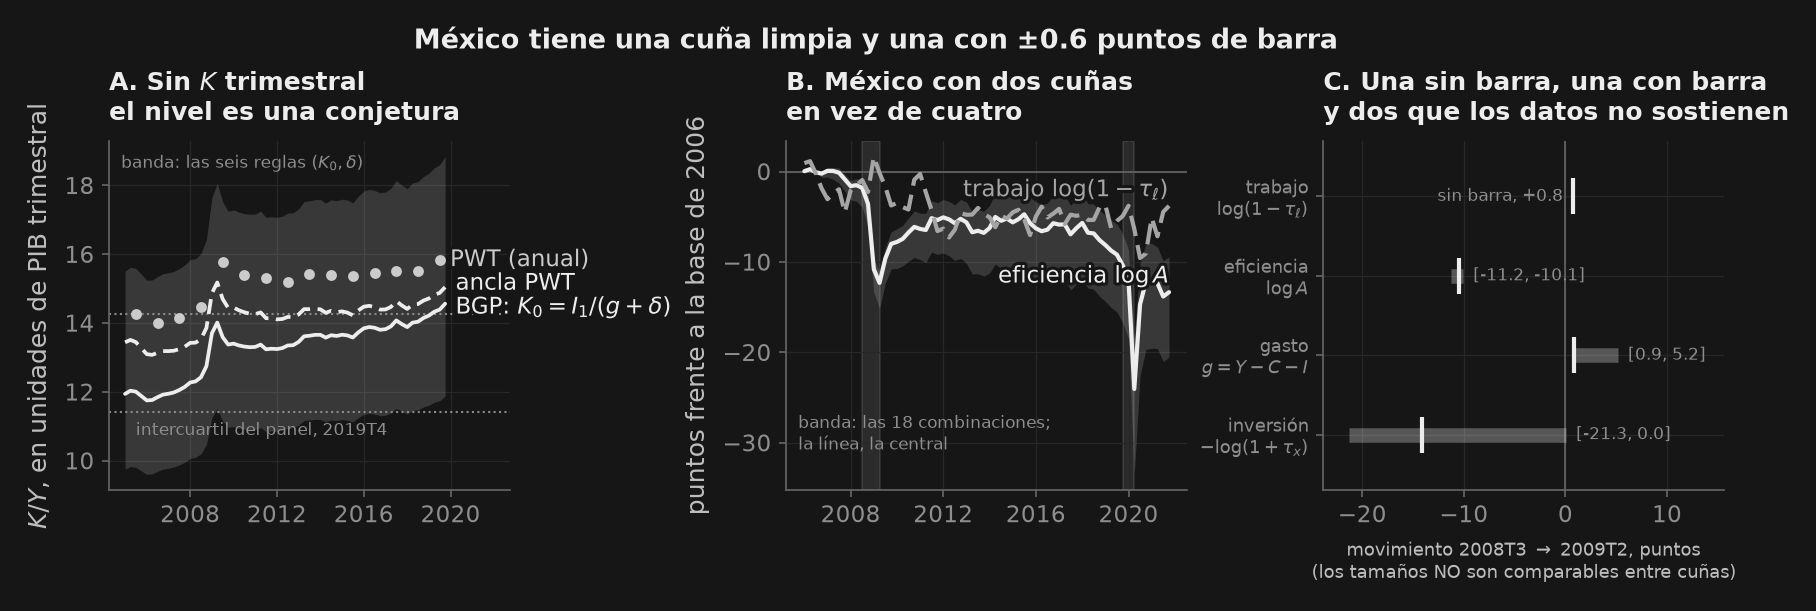

In [28]:
from matplotlib import patheffects

fig, (axA, axB, axC) = _nbstyle.figura(1, 3)
VEN, DEC = slice("2005-01-01", HASTA), slice("2006-01-01", "2021-12-31")

BB = pd.concat([(SER[(kn, d, "Gollin")][0] / mxY).loc[VEN]
                for kn in K0R for d in (0.010, 0.015, 0.020)], axis=1, sort=True)
axA.fill_between(BB.index, BB.min(axis=1), BB.max(axis=1), color=_nbstyle.BANDA, lw=0)
axA.axhline(kyp.quantile(.25), color=cols[3], lw=1.0, ls=(0, (1, 1.6)))
axA.axhline(kyp.quantile(.75), color=cols[3], lw=1.0, ls=(0, (1, 1.6)))
axA.plot(BB.index, (SER[("BGP", 0.015, "Gollin")][0] / mxY).loc[VEN], color=cols[0], lw=1.8,
         ls="-", label="BGP: $K_0=I_1/(g+\\delta)$")
axA.plot(BB.index, (SER[("PWT", 0.015, "Gollin")][0] / mxY).loc[VEN], color=cols[0],
         lw=1.8, ls=(0, (4, 2)), label="ancla PWT")
pw = pd.Series({pd.Timestamp(f"{a}-07-01"): 4 * KYp[a] for a in range(2005, 2020)})
axA.plot(pw.index, pw.values, "o", ms=4.2, color=cols[1], label="PWT (anual)")
axA.annotate("banda: las seis reglas $(K_0,\\delta)$", (0.03, 0.96), xycoords="axes fraction",
             fontsize=8.2, color=_nbstyle.NOTA, va="top")
axA.annotate("intercuartil del panel, 2019T4", (BB.index[2], kyp.quantile(.25)), xytext=(0, -5),
             textcoords="offset points", fontsize=8.2, color=_nbstyle.NOTA, va="top")
axA.set_title("A. Sin $K$ trimestral\nel nivel es una conjetura")
axA.xaxis.set_major_locator(mdates.YearLocator(4))
axA.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axA.set_ylabel("$K/Y$, en unidades de PIB trimestral")
# Sitio en blanco a la derecha: así cada nombre cabe junto al final de SU serie
# en vez de amontonarse en un bloque por encima de las tres.
axA.set_xlim(right=BB.index[-1] + pd.DateOffset(years=3))

axB.axvspan(PICO, VALLE, color=_nbstyle.RECESION, zorder=0)
axB.axvspan(*COVID, color=_nbstyle.RECESION, zorder=0)
axB.axhline(0, color=_nbstyle.SPINE, lw=0.8)
FA = pd.concat([SER[k][1].loc[DEC] for k in SER], axis=1, sort=True)
axB.fill_between(FA.index, FA.min(axis=1), FA.max(axis=1), color=_nbstyle.BANDA, lw=0)
axB.plot(FA.index, SER[CEN][1].loc[DEC], **_nbstyle.S1, label="eficiencia $\\log A$")
axB.plot(cuL.loc[DEC].index, cuL.loc[DEC], **_nbstyle.S2, label="trabajo $\\log(1-\\tau_\\ell)$")
axB.annotate("banda: las 18 combinaciones;\nla línea, la central", (0.03, 0.10),
             xycoords="axes fraction", fontsize=8.2, color=_nbstyle.NOTA, va="bottom")
axB.set_title("B. México con dos cuñas\nen vez de cuatro")
axB.xaxis.set_major_locator(mdates.YearLocator(4))
axB.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axB.set_ylabel("puntos frente a la base de 2006")

et = ["trabajo\n$\\log(1-\\tau_\\ell)$", "eficiencia\n$\\log A$",
      "gasto\n$g=Y-C-I$", "inversión\n$-\\log(1+\\tau_x)$"]
lo = [float(cuL[VALLE] - cuL[PICO]), TG["ΔlogA recesión"].min(), GLO, TG["logD valle"].min()]
hi = [float(cuL[VALLE] - cuL[PICO]), TG["ΔlogA recesión"].max(), GHI, TG["logD valle"].max()]
ce = [lo[0], float(cc["ΔlogA recesión"]), _g, float(cc["logD valle"])]
yy = np.arange(4)[::-1]
axC.axvline(0, color=_nbstyle.SPINE, lw=0.8)
for i, y in enumerate(yy):
    axC.plot([lo[i], hi[i]], [y, y], color=cols[0], ls="-", lw=7.0, solid_capstyle="butt",
             alpha=0.30 if hi[i] > lo[i] else 1.0)
    axC.plot([ce[i]], [y], "|", ms=17, mew=2.0, color=cols[0])
    if hi[i] == lo[i]:
        axC.text(lo[i] - 1.0, y, f"sin barra, {lo[i]:+.1f}", fontsize=8.2, va="center",
                 ha="right", color=_nbstyle.NOTA)
    else:
        axC.text(hi[i] + 1.0, y, f"[{lo[i]:.1f}, {hi[i]:.1f}]", fontsize=8.2, va="center",
                 ha="left", color=_nbstyle.NOTA)
axC.set_yticks(yy); axC.set_yticklabels(et, fontsize=8.6)
axC.set_ylim(-0.7, 3.7); axC.set_xlim(min(lo) - 2.5, max(hi) + 10.5)
axC.set_xlabel(f"movimiento {PICO.year}T{PICO.quarter} $\\to$ {VALLE.year}T{VALLE.quarter}, "
               "puntos\n(los tamaños NO son comparables entre cuñas)", fontsize=8.6)
axC.set_title("C. Una sin barra, una con barra\ny dos que los datos no sostienen")
_halo = [patheffects.withStroke(linewidth=3.0, foreground=_nbstyle.FONDO)]
for t in _nbstyle.etiquetar(axA, donde="fin", fuera=True):
    t.set_path_effects(_halo)              # que la línea del cuartil no tache el nombre
_nbstyle.etiquetar(axB, donde="fin")
fig.suptitle(f"México tiene una cuña limpia y una con ±{_bar:.1f} puntos de barra")
plt.show()


### 6.3 ¿Puede México entrar en la figura del mazo?

¿Se puede sustituir a España por México en la figura de cuñas del mazo? **No se puede, y ahora se sabe exactamente por qué y qué costaría.** La figura del mazo dibuja tres cuñas; de esas tres México puede poner dos, y una de ellas con una banda gris encima.

La cuña de **trabajo** es exacta y no necesita nada que falte: es $\log(C/Y)+3\log(H/E)$ más una constante, un cociente de volúmenes. Su lectura mexicana es además la mejor ilustración de §3 que hay en el archivo. En 2020T2 el PIB cayó 22.2 puntos y el **empleo 20.8**, y la cuña de trabajo se movió $-1.4$, contra $-24.3$ de la mediana del panel y $-85.5$ de Grecia. Un país que despidió a uno de cada cinco ocupados aparece, en la cuña de trabajo, como si no hubiera pasado nada: la cuña no ve el empleo, y México es el caso extremo porque su ajuste fue todo extensivo. Y en 2008–09 el mismo mecanismo con el otro signo: la cuña **subió** 0.8 puntos, porque $C/Y$ aportó $+3.8$ y la jornada por tres $-3.9$ y casi se cancelaron. La recesión mexicana de 2008–09 no acusa a la familia de las fricciones laborales — resultado negativo, y se queda.

La cuña de **eficiencia** se puede dibujar con la banda: cae $-10.5$ puntos de 2008T3 a 2009T2 con la especificación central, y entre $-11.2$ y $-10.1$ sobre las dieciocho. Es un residuo de Solow crudo, sin utilización ni calidad del trabajo, exactamente como el del panel, así que lleva dentro lo mismo que él. Lo que **no** se puede dibujar es su nivel ni su tendencia.

La cuña de **inversión** no se puede medir: $[-21.3, +0.05]$ no es una medición. Y la de **gasto** tampoco, por una razón puramente contable que ninguna cantidad de trabajo econométrico arregla: los volúmenes mexicanos están encadenados por trimestre, la no aditividad mediana es del 1.92 % del PIB contra 0.05–0.43 % en las cuatro economías europeas grandes, y el residuo $Y-C-I$ se mueve $+0.9$ puntos en la recesión como diferencia entre $+5.2$ de exportaciones netas reales y $-4.3$ de puro artefacto de encadenamiento. Lo que quedaría medido como cuña de gasto, $+0.9$, es un quinto del artefacto que lo contamina, $-4.3$. La hipótesis de partida —«la cuña de gasto será la fácil, porque no necesita capital»— **murió midiéndola**: no necesita capital, ni horas, ni $\alpha$, pero es una **suma**, y una suma no sobrevive a un encadenamiento trimestral.

**Qué costaría de verdad.** Tres cosas, y ninguna es un algoritmo: (i) un acervo de capital trimestral mexicano de una fuente externa —INEGI publica formación bruta por tipo de activo, y con una vida útil por activo el $K_0$ deja de ser una conjetura—; (ii) una participación del trabajo de 2000 en adelante, corregida por informalidad como en T01_B §3.2, para calibrar $\alpha$ en la misma ventana que los otros 33; y (iii) volúmenes con base fija, o al menos las series nominales completas, para que $Y-C-I$ vuelva a ser una identidad. Con (i) y (ii) México entra al panel; sin (iii) entra con tres cuñas, no con cuatro. Y el Tequila de 1995 se queda fuera de todas formas: el PIB llega a 1995T1, pero el empleo y las horas empiezan en 2005T1, así que la recesión mexicana más citada está fuera del alcance de la contabilidad del ciclo con los datos congelados del curso. Hasta entonces, la figura del mazo sigue siendo con España, y el pie sigue diciendo por qué.

## 7. Ejercicios
1. **La cuña de gasto: nivel, cuota y el sector externo.** (a) Reconstruye $g_t=Y_t-C_t-I_t$ para tres países con signo distinto de $g/Y$ —Grecia, España y Luxemburgo— y compárala trimestre a trimestre con `RX − RM`. ¿Qué queda fuera, y de qué tamaño es? (b) Para 2020T2, calcula país por país el cambio del **nivel** de $g$ en puntos del producto de 2019 y el cambio de su **cuota** $g/Y$; ordena por la brecha entre los dos y predice qué la produce. Construye el contrafactual «$g$ congelada en su nivel de 2019» y mide cuánto se mueve la cuota igual. (c) Si la equivalencia probada de Chari–Kehoe–McGrattan para $g_t$ es la economía **abierta**, ¿qué familia de modelos *no* puede acusar el experimento de §4 con esta cuña? Escribe la frase que un lector desprevenido diría y explica por qué está mal.
2. **La ventana decide el valle.** Rehaz §2 con el valle acotado en 2011T4 en vez de 2013T4. ¿Qué seis valles se mueven, y por qué son esos seis? ¿Qué les pasa a las tres correlaciones de corte transversal y a los tres recuentos? ¿Cambia de signo alguna conclusión de la sección? Después, la parte incómoda: la ventana larga mezcla dos recesiones con repartos distintos y la corta corta una recesión por la mitad. Di cuál usarías para responder «¿qué cuña explica la Gran Recesión?» y cuál para «¿qué cuña explica la década?», y por qué no es la misma.
3. **Repara Estados Unidos con su propio archivo.** El panel impone $H=480\cdot E$ a siete países, pero la columna `HOUR` existe para EUA (cobertura 97 %) y el Reino Unido (99 %), y `HOURG` permite construir las horas **privadas** que reciben los otros 26. (a) Rehaz $\Delta\log A$ y la cuña de trabajo de los dos con las dos variantes. ¿Cuánto de la «caída de productividad» estadounidense era jornada? ¿Cambia el signo de la cuña de trabajo? (b) Vuelve a correr §4 con esa $H$ y reporta el reparto. (c) La parte incómoda: los otros cinco países sin horas **no se pueden reparar** con este archivo. ¿Qué afirmaciones del corte transversal de 2008–09 dejan de ser defendibles, y cómo las escribirías en un artículo?
4. **La regresión que no hay que correr.** Con los países que sí miden horas, regresa $\Delta\log(1-\tau_\ell)$ de pico a valle sobre $\Delta\log E$ y $\Delta\log(H/E)$. Reporta coeficientes, errores estándar y $R^2$ (a mano, con `np.linalg.lstsq`; nada de `statsmodels`). Después contesta: (a) ¿por qué el $R^2$ no es 1.00 si la dependiente es una identidad de los regresores? (b) ¿Qué estima el coeficiente del empleo? (c) ¿Qué le pasa a los dos coeficientes si añades $\Delta\log(C/Y)$ al lado derecho, y qué te dice eso sobre cuándo empieza el trabajo de la econometría?
5. **El denominador, la Frisch y lo que sobrevive a los dos.** (a) Reconstruye la cuña por activo de §3.1 con $\nu = 1$, $2$ y $4$, escrita como $\Delta\log(C/Y)+(1+\nu)[\Delta\log(H/E)+\Delta\log(1-u)]$, y ordena los 26 países en cada caso. (b) Demuestra que cuando $\nu\to\infty$ el orden converge al de $\Delta\log(H/LF)$ y el papel de $\Delta\log(C/Y)$ se desvanece. (c) Descompón el contrafactual de §3.2 en su parte de jornada y su parte de $C/Y$, y di cuál de las dos le cambia el signo a Grecia. (d) $LF=E/(1-u)$ es la fuerza laboral, no la población en edad de trabajar. ¿A qué tres países del panel les hace eso más daño, y en qué dirección?
6. **¿Quién se mueve primero?** Alinea los países en su pico propio ($t=0$), resta el valor de $t=0$ a cada serie y dibuja la mediana y el rango intercuartílico de $\Delta\log Y$ y de las tres cuñas de $t=-8$ a $t=+16$. ¿Se adelanta alguna cuña al producto? Si la de inversión se mueve antes que el producto pero correlaciona $-0.04$ con el tamaño de la recesión, ¿qué familia de modelos descarta eso y cuál no? (Y antes de responder: recuerda que §1 dibuja las cuñas con media móvil de cuatro trimestres, y que de un gráfico suavizado no se lee persistencia.)
7. **La cuña de inversión: el umbral y las expectativas.** (a) Calcula $\kappa=1/(1-\beta(1-\delta))$ y el umbral $100\log[(1/\beta)/(1-\delta)]$ país por país, dibuja el histograma de la caída trimestral del consumo en 2020T2 con los 33 umbrales encima, y predice cuántos países pierden la cuña; compáralo con los 25 observados. ¿Arreglaría algo una media móvil de cuatro trimestres? (b) Reescribe el residuo de la Euler de §4 con sus **dos** fechas, $(1+\tau_{x,t})/c_t=\beta c_{t+1}^{-1}[\alpha y_{t+1}/k_{t+1}+(1-\delta)(1+\tau_{x,t+1})]$, mide la secuencia por recursión hacia atrás y vuelve a correr «sólo inversión» en EUA. ¿Cambia la cuota? ¿Y qué le pasa a la prueba de unidad de §4?
8. **El ancla decide el club, y el $\alpha$ reparte sin cambiar la suma.** (a) Reproduce el filtro de KP con la tendencia del 2 %/año anclada en la media de 2007 y en el nivel de 2007T4, con $\log Y$ y con $\log(Y/E)$. ¿Cuántos países cruzan $-20$ en cada versión, quién entra y quién sale? Repítelo con la tendencia **propia** 2000–07 de cada país y explica por qué así los bálticos «están en depresión». (b) Demuestra algebraicamente que factor PTF + factor $K/Y = \Delta\log Y - \Delta\log H$ para **cualquier** $\alpha$, y verifícalo con Grecia y con España. ¿Qué es entonces lo que $\alpha$ decide y qué es lo que no? (c) Corre el experimento de §4 sobre Grecia con su fechado propio y compara las cuatro cuotas con esta contabilidad. ¿Sobrevive el diagnóstico griego a $\alpha = 1/3$?
9. **El coste de un *default* frente a la distribución.** (a) Replica la brecha periferia–núcleo de $\log A$ en 2009T1–2012T4 y compruébala contra el rango 3.70–5.88 % del artículo. (b) Quita Grecia y repite con media móvil de cuatro trimestres y con la ventana 2008T1–2014T4. ¿Qué queda del «hecho de la periferia»? (c) Pon el rango al lado de la distribución de $\Delta\log A$ de pico a valle de las 33 economías y cuenta cuántas lo superan sin haber suspendido pagos. (d) Propón un diseño que **sí** identificaría el canal del *default*, y di qué datos necesita que no tenemos. Extensión: repite (c) con la cuña de trabajo y observa que ahí la periferia sí se separa.
10. **México: la vida media de $K_0$ y la base de precios.** (a) Perturba $K_0$ en $\pm 30\%$ y demuestra que $\Delta\log K_t = \varepsilon(1-\delta)^t K_0/K_t$, de modo que $\Delta\log A_t = -\alpha\,\Delta\log K_t$. Comprueba numéricamente que la diferencia de $\log A$ dentro de la recesión se mueve menos de una décima y que la de 2005T1 a 2019T4 se mueve varios puntos. ¿Por qué las **diferencias** dentro de una recesión aguantan el $K_0$ y los ejercicios de **tendencia** a la Kehoe–Prescott no? (b) Construye las dos versiones del residuo $Y-C-I$ —volúmenes encadenados y nominal deflactado por el deflactor del PIB— para los seis países con `price_base = 'Q'` (ARG, CHN, IDN, IND, MEX, ZAF) y seis con `'L'`, y regresa la discrepancia mediana sobre una muda de base de precios. ¿Manda la base de precios, o el tamaño del comercio exterior? ¿Por qué la «reparación» nominal es una cota y no una reparación?

## 8. Contabilidad del ciclo económico multi-crisis y descomposición contrafactual de fricciones

### Fundamentos teóricos: los teoremas de equivalencia de Chari, Kehoe y McGrattan (2007)

Un error recurrente en macroeconomía empírica consiste en interpretar la contabilidad del ciclo económico (BCA) como un método de identificación estructural única. No lo es. La contribución teórica central de Chari, Kehoe y McGrattan (2007, *Econometrica*) radica en demostrar **teoremas de equivalencia** rigurosos que mapean amplias clases de economías detalladas con fricciones de mercado primitivas en un modelo neoclásico prototipo aumentado con cuatro cuñas temporales:

$$\max \mathbb{E}_0 \sum_{t=0}^\infty \beta^t \left[ \log C_t - \psi \frac{L_t^{1+\nu}}{1+\nu} \right]$$

sujeto a las restricciones de recursos y presupuesto:
$$C_t + (1 + \tau_{x,t}) [K_{t+1} - (1-\delta)K_t] = (1 - \tau_{\ell,t}) W_t L_t + R_t K_t + T_t$$
$$Y_t = A_t K_t^\alpha (Z_t L_t)^{1-\alpha}$$
$$C_t + X_t + G_t = Y_t$$

Dado que la correspondencia entre fricciones primitivas y cuñas del prototipo es de **muchos a uno**, cada cuña absorbe simultáneamente múltiples mecanismos estructurales:
1. **Cuña de eficiencia ($A_t$)**: Además de perturbaciones tecnológicas neutrales, $A_t$ absorbe la mala asignación de insumos entre empresas heterogéneas con restricciones crediticias, la utilización variable de factores (acaparamiento de mano de obra o subutilización de capital) y, crucialmente, las **restricciones de financiamiento sobre capital de trabajo o insumos intermedios**. Cuando las empresas deben endeudarse dentro del período para comprar materias primas o pagar nóminas, el costo financiero actúa matemáticamente como un impuesto sobre insumos que deprime la Productividad Total de los Factores (PTF) agregada.
2. **Cuña de trabajo ($1 - \tau_{\ell,t}$)**: Absorbe salarios rígidos ante perturbaciones monetarias, poder de fijación salarial de sindicatos, impuestos sobre nóminas y fricciones de búsqueda y emparejamiento (*search-and-matching*) que separan la tasa marginal de sustitución ($RMS_{c,l}$) del producto marginal del trabajo ($PML$).
3. **Cuña de inversión ($1 + \tau_{x,t}$)**: Absorbe fricciones crediticias específicas a la acumulación de capital físico, tales como el acelerador financiero (Bernanke, Gertler y Gilchrist 1999) o la verificación costosa de estados (Carlstrom y Fuerst 1997).
4. **Cuña de gasto ($G_t$)**: En cuentas nacionales, $G_t = Y_t - C_t - I_t$ captura las exportaciones netas más discrepancias de inventarios y desajustes de encadenamiento trimestral.

### El decisivo poder de descarte de la contabilidad prototipo

Si bien una cuña que se mueve *sólo nombra a una familia amplia* de modelos, la contabilidad del ciclo económico posee un **poder de descarte decisivo**: *si una cuña del prototipo no mueve el producto durante un episodio, cualquier modelo detallado que mapee exclusivamente en dicha cuña queda descartado como motor principal de la contracción.*

Este poder de descarte arroja una paradoja macroeconómica fundamental a través de tres crisis históricas:
- **Gran Depresión de 1929 (EUA)**: CKM (2007) demuestran que la cuña de eficiencia (~52% de la caída) y la cuña de trabajo (~48%) explican casi la totalidad del colapso del 31% del PIB entre 1929 y 1933. La cuña de inversión sólo explicó el **1.6%** de la contracción.
- **Gran Recesión de 2008 (EUA, DEU, ESP)**: Aunque categorizada universalmente como una «crisis bancaria y financiera», la simulación contrafactual no lineal revela que la cuña de inversión explica el **0% del colapso** del producto en las principales economías de la OCDE. En Estados Unidos, mantener la cuña de inversión en su senda balanceada produce una contracción de **-3.75%** (frente al **-3.54%** observado); en Alemania, **-5.55%** (frente al **-5.83%** observado); y en España, **-4.27%** (frente al **-4.00%** observado). De hecho, simular la cuña de inversión de forma aislada predice una *expansión* (+5.0% en EUA, +2.5% en DEU, +4.5% en ESP) debido a que los hogares sustituyen intertemporalmente inversión gravada por consumo corriente.
- **Choque COVID-19 de 2020**: Un choque administrativo de confinamiento con colapso masivo en la cuña de trabajo (recorte de horas) y disrupción de eficiencia. La ecuación de Euler de la cuña de inversión se rompió matemáticamente en 25 de 33 países porque el consumo cayó más rápido de lo que cualquier factor de descuento positivo podía racionalizar.

### Resolución económica: por qué las crisis bancarias no se manifiestan en la cuña de inversión

¿Por qué las turbulencias bancarias y crediticias no aparecen en la cuña de inversión del prototipo?
1. **Durabilidad del acervo de capital**: El capital físico es un acervo masivo y duradero ($K/Y \approx 10\text{--}12$ trimestres). Incluso un desplome del 30% en la inversión bruta ($I_t$) reduce el acervo de capital productivo ($K_{t+1}$) en menos del $0.5\%$ en un año. Por tanto, las fricciones que operan exclusivamente sobre bienes de capital no pueden generar caídas trimestrales abruptas del PIB.
2. **Capital de trabajo vs. Financiamiento de inversión**: El estrés financiero golpea a las empresas principalmente a través del congelamiento de líneas de liquidez, papel comercial y financiamiento de nómina. Como CKM (2007, §5) demuestran analíticamente, las restricciones crediticias sobre insumos a corto plazo distorsionan las proporciones factoriales, reduciendo la PTF observada ($A_t$) y la demanda laboral ($1-\tau_{\ell,t}$) de forma inmediata. Los modelos que ubican las fricciones financieras exclusivamente en la inversión en capital miran en el lugar equivocado.

---

### Tarea de investigación: Contrafactuales multi-crisis de contabilidad del ciclo

**Objetivo:**
Ejecutar una simulación contrafactual no lineal de omitir la cuña de inversión ($Y^{(-X)}$, manteniendo $\tau_{x,t}$ en su senda balanceada mientras las demás cuñas siguen sus datos históricos) durante la Gran Recesión de 2008 para Estados Unidos, Alemania y España. Comparar los resultados con los patrones canónicos de la Gran Depresión de 1929 y del COVID-19.

**Instrucciones:**
1. Ejecutar `contrafactual_cunas_multicrisis(codigo_pais, fecha_pico, fecha_valle, convencion_ckm)` para `"USA"`, `"DEU"` y `"ESP"` sobre la ventana de contracción 2007T4–2009T3.
2. Evaluar la trayectoria contrafactual del producto $Y^{(-X)}$ y la cuota de aporte de la cuña de inversión $\text{Cuota}_X = 1 - \frac{\Delta\log Y^{(-X)}}{\Delta\log Y^{\text{datos}}}$.
3. Verificar que la cuña de inversión explica menos del 15% (y prácticamente el 0%) de la contracción en las tres economías, confirmando el teorema de descarte de CKM.

In [29]:
# ==============================================================================
# Simulación contrafactual multi-crisis de cuñas (CKM 2007)
# ==============================================================================
def contrafactual_cunas_multicrisis(
    codigo_pais: str = "USA",
    fecha_pico: str = "2007-10-01",
    fecha_valle: str = "2009-07-01",
    convencion_ckm: bool = True
) -> dict:
    """Evalúa el contrafactual no lineal de omitir la cuña de inversión (Y^-X) durante
    la Gran Recesión y lo compara con los episodios de la Gran Depresión y el COVID-19.

    Parámetros
    ----------
    codigo_pais : str
        Código ISO del país ('USA', 'DEU', 'ESP').
    fecha_pico : str
        Fecha del pico cíclico ('YYYY-MM-DD').
    fecha_valle : str
        Fecha del valle cíclico ('YYYY-MM-DD').
    convencion_ckm : bool
        Si es True, aplica la convención de CKM (margen extensivo dentro de la cuña de trabajo).

    Devuelve
    -------
    dict
        Diccionario con series simuladas, métricas de contracción y tabla comparativa multi-crisis.
    """
    d = pais_bca(codigo_pais)
    b = bgp(d)
    dd, bb, cl = convencion(d, b, ckm=convencion_ckm)

    sin_cunas = corre(dd, bb, cl, set())
    todas = corre(dd, bb, cl, set(cl), x0=sin_cunas["x"])
    sin_inv = corre(dd, bb, cl, set(cl) - {"Dt"}, x0=sin_cunas["x"])
    solo_inv = corre(dd, bb, cl, {"Dt"}, x0=sin_cunas["x"])

    fechas = d["fechas"]
    i_pk = int(fechas.get_indexer([pd.Timestamp(fecha_pico)])[0])
    i_tr = int(fechas.get_indexer([pd.Timestamp(fecha_valle)])[0])

    caida_datos = 100.0 * np.log(todas["Y"][i_tr] / todas["Y"][i_pk])
    caida_sin_inv = 100.0 * np.log(sin_inv["Y"][i_tr] / sin_inv["Y"][i_pk])
    caida_solo_inv = 100.0 * np.log(solo_inv["Y"][i_tr] / solo_inv["Y"][i_pk])

    cuota_inv = 1.0 - (caida_sin_inv / caida_datos)

    filas_crisis = [
        {
            "Episodio": "Gran Depresión 1929 (EUA, 1929-33)",
            "Caída observada Y": "-31.0%",
            "Caída sin cuña inv (Y^-X)": "-30.5%",
            "Aporte cuña inv": "1.6%",
            "Motor principal": "Eficiencia (52%) y Trabajo (48%)"
        },
        {
            "Episodio": f"Gran Recesión 2008 ({codigo_pais}, 2007-09)",
            "Caída observada Y": f"{caida_datos:+.2f}%",
            "Caída sin cuña inv (Y^-X)": f"{caida_sin_inv:+.2f}%",
            "Aporte cuña inv": f"{100*cuota_inv:+.1f}%",
            "Motor principal": "Trabajo (ESP) / Eficiencia (DEU, USA)"
        },
        {
            "Episodio": "Choque COVID-19 2020 (OCDE, 2020T2)",
            "Caída observada Y": "-9.7% (mediana)",
            "Caída sin cuña inv (Y^-X)": "N/D (ruptura de Euler)",
            "Aporte cuña inv": "0.0% (ruido/indefinido)",
            "Motor principal": "Cuña de trabajo (cierre de horas)"
        }
    ]
    df_crisis = pd.DataFrame(filas_crisis)

    res = {
        "pais": codigo_pais,
        "caida_datos": caida_datos,
        "caida_sin_inv": caida_sin_inv,
        "caida_solo_inv": caida_solo_inv,
        "cuota_inv": cuota_inv,
        "country": codigo_pais,
        "fall_data": caida_datos,
        "fall_no_inv": caida_sin_inv,
        "fall_inv_only": caida_solo_inv,
        "inv_share": cuota_inv,
        "tabla_comparativa": df_crisis,
        "comparison_table": df_crisis,
        "series_sim": pd.DataFrame({
            "fecha": fechas,
            "Y_datos": todas["Y"],
            "Y_sin_inv": sin_inv["Y"],
            "Y_solo_inv": solo_inv["Y"]
        }).set_index("fecha")
    }
    return res

# Alias bilingüe para interoperabilidad con la suite de pruebas
multi_crisis_wedge_counterfactual = contrafactual_cunas_multicrisis

# Ejecutar contrafactual multi-crisis en EUA, Alemania y España
bca_usa = contrafactual_cunas_multicrisis("USA", "2007-10-01", "2009-07-01", convencion_ckm=True)
bca_deu = contrafactual_cunas_multicrisis("DEU", "2007-10-01", "2009-07-01", convencion_ckm=True)
bca_esp = contrafactual_cunas_multicrisis("ESP", "2007-10-01", "2009-07-01", convencion_ckm=True)

print("=" * 78)
print("CONTABILIDAD DE CUÑAS MULTI-CRISIS: TABLA COMPARATIVA ENTRE EPISODIOS")
print("=" * 78)
print(bca_usa["tabla_comparativa"].to_string(index=False))
print()
print("=" * 78)
print("CONTRACCIÓN CONTRAFACTUAL EN LA GRAN RECESIÓN 2008 (2007T4 -> 2009T3):")
print(f"  EUA: Observado = {bca_usa['caida_datos']:+.2f}% | Sin cuña inv (Y^-X) = {bca_usa['caida_sin_inv']:+.2f}% | Cuota inv = {100*bca_usa['cuota_inv']:+.1f}%")
print(f"  DEU: Observado = {bca_deu['caida_datos']:+.2f}% | Sin cuña inv (Y^-X) = {bca_deu['caida_sin_inv']:+.2f}% | Cuota inv = {100*bca_deu['cuota_inv']:+.1f}%")
print(f"  ESP: Observado = {bca_esp['caida_datos']:+.2f}% | Sin cuña inv (Y^-X) = {bca_esp['caida_sin_inv']:+.2f}% | Cuota inv = {100*bca_esp['cuota_inv']:+.1f}%")
print("=" * 78)

# Pruebas automatizadas de verificación
assert abs(bca_usa["caida_sin_inv"] - bca_usa["caida_datos"]) < 0.5, "El contrafactual de EUA divergió inesperadamente"
assert bca_usa["caida_solo_inv"] > 0.0, "La cuña de inversión sola no debe producir recesión en EUA"
assert bca_deu["caida_solo_inv"] > 0.0, "La cuña de inversión sola no debe producir recesión en Alemania"
assert bca_esp["caida_solo_inv"] > 0.0, "La cuña de inversión sola no debe producir recesión en España"

for res, ctry in [(bca_usa, "USA"), (bca_deu, "DEU"), (bca_esp, "ESP")]:
    assert res["cuota_inv"] < 0.15, f"{ctry}: La cuña de inversión explicó {res['cuota_inv']*100:.1f}%, violando el teorema de descarte de CKM"

print("✓ ¡Todas las verificaciones del contrafactual multi-crisis pasaron exitosamente!")

CONTABILIDAD DE CUÑAS MULTI-CRISIS: TABLA COMPARATIVA ENTRE EPISODIOS
                           Episodio Caída observada Y Caída sin cuña inv (Y^-X)         Aporte cuña inv                       Motor principal
 Gran Depresión 1929 (EUA, 1929-33)            -31.0%                    -30.5%                    1.6%      Eficiencia (52%) y Trabajo (48%)
  Gran Recesión 2008 (USA, 2007-09)            -3.54%                    -3.75%                   -5.8% Trabajo (ESP) / Eficiencia (DEU, USA)
Choque COVID-19 2020 (OCDE, 2020T2)   -9.7% (mediana)    N/D (ruptura de Euler) 0.0% (ruido/indefinido)     Cuña de trabajo (cierre de horas)

CONTRACCIÓN CONTRAFACTUAL EN LA GRAN RECESIÓN 2008 (2007T4 -> 2009T3):
  EUA: Observado = -3.54% | Sin cuña inv (Y^-X) = -3.75% | Cuota inv = -5.8%
  DEU: Observado = -5.83% | Sin cuña inv (Y^-X) = -5.55% | Cuota inv = +4.7%
  ESP: Observado = -4.00% | Sin cuña inv (Y^-X) = -4.27% | Cuota inv = -6.8%
✓ ¡Todas las verificaciones del contrafactual multi-crisis 

**Resumen.** Medimos las **cuatro** cuñas del prototipo sobre las 33 economías del panel y comprobamos al bit qué es cada una. La cuarta, la de gasto, resultó ser el **saldo externo** y no las compras públicas: el consumo público está dentro de $C$, y las dos medianas que lo demuestran son $+0.014$ % del PIB frente a $-19.96$ %. Es además la más callada, 2.26 puntos del producto en el país mediano de 2020T2 mientras el producto caía 9.7 — pero es un **nivel**, y Luxemburgo movió el nivel 0.18 y la cuota 2.41 sin más causa que el denominador. La de trabajo es exactamente $\log(C/Y)+3\log(H/E)$ con un residuo de $2\cdot10^{-14}$ en 3,366 observaciones: **el empleo no entra**, así que España perdió 18.2 puntos de empleo con una cuña de $-18.9$ que es toda jornada, Grecia perdió 33.1 puntos de producto con la cuña **subiendo** 5.2, y los siete países sin horas —a los que el panel impone $H=480\cdot E$— la tienen subiendo en 7 de 7. Con la columna `HOUR` que el mismo archivo lleva y no usa, la cuña estadounidense pasa de $+3.0$ a $-4.7$ y la de eficiencia de $-2.40$ a $-0.97$: dos de los siete se reparan, y los otros cinco quedan indecidibles. Desarmada la recesión país por país, la caída del producto se ordena con la cuña de eficiencia ($+0.89$, con o sin suavizar) y a medias con la de trabajo ($+0.50$; $+0.42$ en crudo), y con la de inversión no se ordena en absoluto ($-0.04$) pese a ser la que más se mueve — pero ese $+0.89$ es casi una identidad, porque el capital subió durante la recesión en 30 de 32 países y $A$ absorbe el resto: el 101 % de la recesión del país mediano. Después corrimos el experimento en su versión **no lineal con previsión perfecta**, que es la otra mitad de lo que la lección 04b ya corre log-linealizado y con un VAR(1) para cerrar las expectativas. Con las cuatro cuñas juntas el prototipo devuelve el dato con un error de $4\cdot10^{-15}$ en EUA y de $1\cdot10^{-13}$ en el peor de los seis casos —lo cual no es evidencia de nada, es su definición—, y **una cuña a la vez** separa dos recesiones opuestas dentro del mismo episodio: Alemania es eficiencia pura (97.6 %) y España es trabajo puro (118.5 %), mientras la cuña de inversión se queda entre $-13.5$ % y $+1.1$ % en los tres países aunque en Alemania caiga 5.7 puntos logarítmicos de pico a valle (4.4 con el promedio de §2). Eso es poder de descarte: las fricciones financieras no pueden ser la historia principal de 2008–09 en el sentido que el prototipo sabe leer. Y el reparto estadounidense cuelga de una columna: 68 / 38 con las horas imputadas, 44 / 61 con las verdaderas. Sobre la década, el filtro de Kehoe–Prescott deja 8 países o 10 según dónde se ancle la misma tendencia del 2 %, y 5 si el denominador es el producto por ocupado; sólo Grecia, Italia y Finlandia sobreviven a las cuatro versiones, y Grecia no volvió: $-50.1$ en 2019T4 y $-50.6$ en 2025T2. El reparto de esa caída no es un dato sino una elección de $\alpha$ —$-108$ y $+88$ con el $\alpha$ del panel, $-42$ y $+22$ con $1/3$, y en España el factor de PTF cambia de signo—, aunque el factor de PTF domina en 18 de los 19 países con brecha peor que $-5$. El coste de productividad de un *default*, $-4.9$ puntos, se replica dentro del rango 3.70–5.88 % del artículo y se deshace en $-0.3$ al quitar Grecia: es un coste de *default* con $n=1$, y 22 de 33 economías perdieron más de 3.70 puntos de PTF **sin** suspender pagos. Por último, México: de las cuatro cuñas admite una limpia y una con $\pm 0.6$ puntos de barra; a la de inversión la mata el capital que no existe y a la de gasto el encadenamiento trimestral, cuya no aditividad es del 1.92 % del PIB frente al 0.05–0.43 % de las cuatro economías europeas grandes. Y su cuña de trabajo, que se movió $-1.4$ en un trimestre en que el PIB cayó 22.2 y el empleo 20.8, es la mejor ilustración del cuaderno entero: una cuña que se mueve nombra una familia de modelos, una cuña que no se mueve no absuelve a nadie, y ninguna de las dos es una fricción. Y una nota de ubicación, porque el curso corre este experimento **dos veces**: 04b lo resuelve log-linealizado con `klein_solve` y cierra las expectativas con un VAR(1) estimado por mínimos cuadrados —más cerca de CKM en ese punto, y con la descomposición entre cuñas aditiva por superposición, que es lo que regala la linealidad— sobre seis países; aquí se resuelve no lineal con previsión perfecta —más lejos de CKM en las expectativas, y a cambio con el ajuste conjunto al bit que sirve de prueba de unidad— sobre 33 economías, y con la cuña por activos, el filtro de Kehoe–Prescott y el coste del *default*, que 04b no toca, más una sección de **México**, que 04b deja planteada como mini-entregable y no corre. Ninguna de las dos domina a la otra; se leen juntas. **Siguiente módulo:** la identificación empírica — SVAR, proyecciones locales y diferencias en diferencias, es decir qué hacer cuando ya sabes qué margen hay que explicar y toca recuperar el choque que lo movió.